In [32]:
# =============================================================================
# KIDNEY TRANSPLANT PROSTATE CANCER STUDY
# Statistical Analysis Plan Implementation
# =============================================================================

In [33]:
import gc

gc.collect()

30

In [34]:
import os

R_HOME = r"C:\Program Files\R\R-4.6.1"

os.environ["R_HOME"] = R_HOME
os.environ["PATH"] = (
    rf"{R_HOME}\bin\x64;"
    rf"{R_HOME}\bin;"
    + os.environ["PATH"]
)

import rpy2.robjects as ro

In [35]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [36]:
# =============================================================================
# PLOS ONE FIGURE STYLE AND EXPORT SETTINGS
# =============================================================================
# PLOS ONE figure requirements: TIFF or EPS, 300–600 dpi, width 2.63–7.5 inches,
# height <= 8.75 inches at 300 dpi, and 8–12 pt text using Arial/Times/Symbol.

from pathlib import Path
import matplotlib as mpl
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm

PLOS_FIG_DIR = Path("plos_one_figures")
PLOS_FIG_DIR.mkdir(exist_ok=True)

_available_fonts = {f.name for f in fm.fontManager.ttflist}
if "Arial" not in _available_fonts:
    print("Note: Arial was not detected on this system. Matplotlib will fall back to an available sans-serif font. "
          "On the submission machine, install/use Arial before final export if possible.")

mpl.rcParams.update({
    "font.family": "sans-serif",
    "font.sans-serif": ["Arial", "Helvetica", "Liberation Sans", "DejaVu Sans"],
    "font.size": 9,
    "axes.labelsize": 10,
    "axes.titlesize": 10,
    "xtick.labelsize": 9,
    "ytick.labelsize": 9,
    "legend.fontsize": 8,
    "axes.linewidth": 0.8,
    "xtick.major.width": 0.8,
    "ytick.major.width": 0.8,
    "lines.linewidth": 1.8,
    "figure.dpi": 300,
    "savefig.dpi": 600,
    "savefig.format": "tiff",
    "pdf.fonttype": 42,
    "ps.fonttype": 42,
})


def save_plos_figure(fig, filename, dpi=600):
    """Save a figure as a PLOS-ready TIFF file in the figure output directory."""
    outpath = PLOS_FIG_DIR / filename
    fig.savefig(outpath, dpi=dpi, bbox_inches="tight", format="tiff")
    print(f"Saved PLOS-ready figure: {outpath}")
    return outpath


In [37]:
# -----------------------------
# 1. LOAD DATA
# -----------------------------
dtafile = r"C:/Users/kunle/OneDrive/Desktop/KidneyData/Data_prostrate_analysis/NK_UNOS_Prostate/prostate.dta"
master_immuno = pd.read_stata(dtafile)

print("Dataset shape:", master_immuno.shape)


Dataset shape: (660, 734)


In [38]:
# =============================================================================
# 2. KEEP REQUIRED COLUMNS 
# ============================================================================

# Define required columns
col_names = [
    'c_ci_mmf', 'c_mtor_mmf', 'c_ci_mmf_steroids', 'c_mtor_mmf_steroids',
    'i_none', 'i_thy', 'i_ale', 'i_bas_dac', 'i_thy_bas_dac',
    'AGE', 'male_pt', 'white_pt', 'black_pt', 'hisp_pt', 'asian_pt',
    'BMI_CALC', 'diab_pt', 'END_CPRA', 'retx', 'DAYSWAIT_CHRON',
    'ON_DIALYSIS', 'CREAT_TRR',
    'AGE_DON', 'male_don', 'white_don', 'black_don', 'hisp_don', 'asian_don',
    'CREAT_DON', 'diab_don', 'hyper_don', 'BMI_DON_CALC', 'KDPI', 'dcd',
    'ECD_DONOR', 'COLD_ISCH_KI', 'local', 'regional', 'national', 'txyr', 'DON_TY',
    'PERIP_VASC', 'FUNC_STAT_TRR', 'TOT_SERUM_ALBUM', 'PRE_TUMOR_TY',
    'MALIG_PRETX_TUMOR', 'PREV_MALIG_TY', 'acutrej', 'TRTREJ6M_KI', 'TRTREJ1Y_KI',
    'HLAMIS', 'TX_DATE',
    'prostate_denovo', 'prostate_denovoDX_date',
    'prostate_recurr', 'prostate_recurr_date'
]

# Keep existing columns
existing_cols = [c for c in col_names if c in master_immuno.columns]
df = master_immuno[existing_cols].copy()

print(f"Columns retained: {len(existing_cols)}")

Columns retained: 56


In [39]:
# -----------------------------
# 3. BASIC CLEANING
# -----------------------------

# Replace blanks/whitespace with NaN
df = df.replace(r'^\s*$', np.nan, regex=True)

# Convert Y/N to 1/0; U and anything else become missing
yn_vars = ['ON_DIALYSIS', 'PERIP_VASC', 'MALIG_PRETX_TUMOR', 'TRTREJ6M_KI', 'TRTREJ1Y_KI']
for col in yn_vars:
    if col in df.columns:
        df[col] = df[col].map({'Y': 1, 'N': 0}).astype('Int64')

# Recode donor type
if 'DON_TY' in df.columns:
    df['donor_type'] = df['DON_TY'].map({'L': 'Living', 'C': 'Deceased'})


# Convert binary-like columns safely
binary_cols = [
    'c_ci_mmf', 'c_mtor_mmf', 'c_ci_mmf_steroids', 'c_mtor_mmf_steroids',
    'i_none', 'i_thy', 'i_ale', 'i_bas_dac', 'i_thy_bas_dac',
    'male_pt', 'white_pt', 'black_pt', 'hisp_pt', 'asian_pt', 'diab_pt',
    'retx', 'diab_don', 'hyper_don', 'dcd', 'ECD_DONOR',
    'local', 'regional', 'national', 'acutrej',
    'prostate_denovo', 'prostate_recurr'
]

for col in binary_cols:
    if col in df.columns:
        df[col] = pd.to_numeric(df[col], errors='coerce').round().astype('Int64')

# Numeric variables
numeric_cols = [
    'AGE', 'BMI_CALC', 'END_CPRA', 'DAYSWAIT_CHRON', 'CREAT_TRR',
    'AGE_DON', 'CREAT_DON', 'BMI_DON_CALC', 'KDPI', 'COLD_ISCH_KI',
    'TOT_SERUM_ALBUM', 'PRE_TUMOR_TY', 'PREV_MALIG_TY', 'txyr'
]

for col in numeric_cols:
    if col in df.columns:
        df[col] = pd.to_numeric(df[col], errors='coerce')


In [40]:
# -----------------------------
# HLAMIS: total HLA mismatch
# -----------------------------
if 'HLAMIS' in df.columns:
    df['HLAMIS'] = pd.to_numeric(df['HLAMIS'], errors='coerce')

    # Keep only valid total mismatch counts 0-6
    df['HLAMIS'] = df['HLAMIS'].where(df['HLAMIS'].between(0, 6), np.nan)

    # Store as nullable integer
    df['HLAMIS'] = df['HLAMIS'].astype('Int64')

    # Optional grouped version for descriptive tables / sensitivity analyses
    df['HLAMIS_cat'] = pd.cut(
        df['HLAMIS'].astype('float'),
        bins=[-0.1, 2, 4, 6],
        labels=['0-2', '3-4', '5-6']
    )

# -----------------------------
# FUNC_STAT_TRR: OPTN/SRTR functional status (KPS-coded)
# Raw values in your extract appear like 2020, 2030, ..., 2100, and 998=unknown
# -----------------------------
if 'FUNC_STAT_TRR' in df.columns:
    df['FUNC_STAT_TRR'] = pd.to_numeric(df['FUNC_STAT_TRR'], errors='coerce').astype('Int64')

    # Preserve original raw code
    df['FUNC_STAT_TRR_raw'] = df['FUNC_STAT_TRR']

    # Recode to standard Karnofsky score
    func_map = {
        2100: 100,
        2090: 90,
        2080: 80,
        2070: 70,
        2060: 60,
        2050: 50,
        2040: 40,
        2030: 30,
        2020: 20,
        2010: 10,
        998: pd.NA
    }

    df['func_stat_kps'] = df['FUNC_STAT_TRR'].map(func_map).astype('Int64')

    # Detailed KPS categories for descriptive reporting (Table 1 only)
    # For modeling, use func_stat_model (collapsed version defined below)
    def collapse_kps(x):
        if pd.isna(x):
            return 'Unknown'
        elif x >= 80:
            return '80-100: Independent/near-independent'
        elif x == 70:
            return '70: Self-care, unable to work normally'
        elif x in [50, 60]:
            return '50-60: Requires assistance'
        elif x in [10, 20, 30, 40]:
            return '10-40: Disabled/severely impaired'
        else:
            return 'Unknown'

    df['func_stat_cat'] = df['func_stat_kps'].apply(collapse_kps)
    df['func_stat_cat'] = pd.Categorical(
        df['func_stat_cat'],
        categories=[
            '80-100: Independent/near-independent',
            '70: Self-care, unable to work normally',
            '50-60: Requires assistance',
            '10-40: Disabled/severely impaired',
            'Unknown'
        ],
        ordered=True
    )

print("\nCleaned dtypes:")
df.info()



Cleaned dtypes:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 660 entries, 0 to 659
Data columns (total 61 columns):
 #   Column                  Non-Null Count  Dtype         
---  ------                  --------------  -----         
 0   c_ci_mmf                660 non-null    Int64         
 1   c_mtor_mmf              660 non-null    Int64         
 2   c_ci_mmf_steroids       660 non-null    Int64         
 3   c_mtor_mmf_steroids     660 non-null    Int64         
 4   i_none                  660 non-null    Int64         
 5   i_thy                   660 non-null    Int64         
 6   i_ale                   660 non-null    Int64         
 7   i_bas_dac               660 non-null    Int64         
 8   i_thy_bas_dac           660 non-null    Int64         
 9   AGE                     660 non-null    int8          
 10  male_pt                 660 non-null    Int64         
 11  white_pt                660 non-null    Int64         
 12  black_pt                660 non-n

In [41]:
# Optional quick checks
if 'HLAMIS' in df.columns:
    print("\nHLAMIS value counts:")
    print(df['HLAMIS'].value_counts(dropna=False).sort_index())

if 'func_stat_kps' in df.columns:
    print("\nfunc_stat_kps value counts:")
    print(df['func_stat_kps'].value_counts(dropna=False).sort_index())

if 'func_stat_cat' in df.columns:
    print("\nfunc_stat_cat value counts:")
    print(df['func_stat_cat'].value_counts(dropna=False))



HLAMIS value counts:
HLAMIS
0     20
1     11
2     41
3     94
4    189
5    199
6    106
Name: count, dtype: Int64

func_stat_kps value counts:
func_stat_kps
20        1
30        2
40        9
50       36
60       68
70      168
80      204
90      115
100      35
<NA>     22
Name: count, dtype: Int64

func_stat_cat value counts:
func_stat_cat
80-100: Independent/near-independent      354
70: Self-care, unable to work normally    168
50-60: Requires assistance                104
Unknown                                    22
10-40: Disabled/severely impaired          12
Name: count, dtype: int64


In [42]:
# Step 3: basic cleaning and recoding
# ... your revised Step 3 code ...

# Additional collapsed functional status for modeling
def collapse_kps_model(x):
    if pd.isna(x):
        return 'Unknown'
    elif x >= 70:
        return '70-100'
    elif x >= 50:
        return '50-60'
    else:
        return '10-40'

df['func_stat_model'] = df['func_stat_kps'].apply(collapse_kps_model)
df['func_stat_model'] = pd.Categorical(
    df['func_stat_model'],
    categories=['70-100', '50-60', '10-40', 'Unknown'],
    ordered=True
)

# Optional: drop raw/redundant variables after confirming recode
drop_cols = [col for col in ['FUNC_STAT_TRR', 'FUNC_STAT_TRR_raw'] if col in df.columns]
df = df.drop(columns=drop_cols)

In [43]:
df['func_stat_model'].value_counts()


func_stat_model
70-100     522
50-60      104
Unknown     22
10-40       12
Name: count, dtype: int64

In [44]:
# -----------------------------
# 4. MISSINGNESS TABLE
# -----------------------------

# Count the number of missingness
missing_df = (
    df.isna()
      .sum()
      .reset_index()
      .rename(columns={'index': 'variable', 0: 'missing_count'})
)
missing_df['missing_pct'] = 100 * missing_df['missing_count'] / len(df)
missing_df = missing_df.sort_values('missing_pct', ascending=False)

print("\nMissingness summary")
print(missing_df.to_string(index=False))


Missingness summary
              variable  missing_count  missing_pct
          PRE_TUMOR_TY            622    94.242424
  prostate_recurr_date            622    94.242424
         PREV_MALIG_TY            523    79.242424
                  KDPI            192    29.090909
             ECD_DONOR            192    29.090909
             CREAT_DON            192    29.090909
           TRTREJ1Y_KI             87    13.181818
           TRTREJ6M_KI             86    13.030303
     MALIG_PRETX_TUMOR             31     4.696970
prostate_denovoDX_date             30     4.545455
         func_stat_kps             22     3.333333
       TOT_SERUM_ALBUM             16     2.424242
              END_CPRA             12     1.818182
             CREAT_TRR              5     0.757576
          COLD_ISCH_KI              5     0.757576
             hyper_don              5     0.757576
          BMI_DON_CALC              3     0.454545
              diab_don              3     0.454545
          

In [45]:
# -----------------------------
# 6. CHECK WHETHER DONOR-TYPE EXPLAINS MISSINGNESS
# -----------------------------
vars_to_check = ['CREAT_DON', 'KDPI', 'ECD_DONOR', 'dcd', 'COLD_ISCH_KI']

rows = []
for var in vars_to_check:
    if var in df.columns:
        tmp = df.groupby('donor_type')[var].apply(lambda x: x.isna().mean() * 100)
        for donor_group, pct_missing in tmp.items():
            rows.append({
                'variable': var,
                'donor_type': donor_group,
                'missing_pct': round(pct_missing, 2)
            })

missing_by_donor = pd.DataFrame(rows)
print("\nMissingness by donor type")
print(missing_by_donor.to_string(index=False))


Missingness by donor type
    variable donor_type  missing_pct
   CREAT_DON   Deceased         0.00
   CREAT_DON     Living       100.00
        KDPI   Deceased         0.00
        KDPI     Living       100.00
   ECD_DONOR   Deceased         0.00
   ECD_DONOR     Living       100.00
         dcd   Deceased         0.00
         dcd     Living         0.00
COLD_ISCH_KI   Deceased         0.21
COLD_ISCH_KI     Living         2.08


In [46]:
date_vars = ['prostate_denovoDX_date', 'prostate_recurr_date', 'TX_DATE']

for col in date_vars:
    non_missing = df[col].dropna()
    print(f"\n{col}")
    print("Non-missing count:", non_missing.shape[0])
    if len(non_missing) > 0:
        print("Min date:", non_missing.min())
        print("Max date:", non_missing.max())


prostate_denovoDX_date
Non-missing count: 630
Min date: 2015-02-24 00:00:00
Max date: 2024-09-09 00:00:00

prostate_recurr_date
Non-missing count: 38
Min date: 2017-02-23 00:00:00
Max date: 2024-03-18 00:00:00

TX_DATE
Non-missing count: 660
Min date: 2015-01-07 00:00:00
Max date: 2024-04-22 00:00:00


What the date output tells us

The usable diagnosis-date window in this extracted cohort is:

- De novo diagnosis dates: February 24, 2015 to September 9, 2024
- Recurrent diagnosis dates: February 23, 2017 to March 18, 2024

That means the observed post-transplant prostate cancer events in this analytic file span roughly 2015 to 2024.

It also confirms something important:

prostate_denovoDX_date is mainly a de novo-case date variable
prostate_recurr_date is mainly a recurrent-case date variable

The small cross-over values:

- 1 de novo case with prostate_recurr_date
- 7 recurrent cases with prostate_denovoDX_date

suggest a few inconsistent records, overlapping abstraction rules, or legacy coding artifacts. That is another reason these date variables should stay out of the predictor set for the primary phenotype model.

In [47]:
# =========================================================
# STEP 7: HANDLE MISSINGNESS (FINAL ANALYSIS-READY DATASET)
# =========================================================

# -----------------------------------------
# 7A. DROP VARIABLES WITH EXTREME MISSINGNESS
# -----------------------------------------
# These variables have >70–90% missingness and are not usable
# They will not provide reliable inference and may destabilize models

drop_vars = [
    'PRE_TUMOR_TY',    # ~94% missing
    'PREV_MALIG_TY'    # ~79% missing
]

df = df.drop(columns=drop_vars)

print("\nDropped high-missingness variables:")
print(drop_vars)



Dropped high-missingness variables:
['PRE_TUMOR_TY', 'PREV_MALIG_TY']


In [48]:
# -----------------------------------------
# 7B. IDENTIFY STRUCTURAL MISSINGNESS VARIABLES
# -----------------------------------------
# These are NOT truly missing — they are unavailable for living donors by design
# We will KEEP them, but DO NOT IMPUTE them
# They will only be used in the secondary (deceased donor) analysis

structural_vars = ['CREAT_DON', 'KDPI', 'ECD_DONOR']

print("\nStructural missingness variables (DO NOT IMPUTE):")
print(structural_vars)


Structural missingness variables (DO NOT IMPUTE):
['CREAT_DON', 'KDPI', 'ECD_DONOR']


In [49]:
# -----------------------------------------
# 7C. HANDLE MODERATE MISSINGNESS VARIABLES
# -----------------------------------------
# These (~13%) are post-transplant variables (rejection)
# Including them may introduce bias (post-treatment variables)
# We will EXCLUDE them from primary models, but can use later in sensitivity analysis

moderate_vars = ['TRTREJ6M_KI', 'TRTREJ1Y_KI']

print("\nModerate missingness variables (exclude from primary models):")
print(moderate_vars)



Moderate missingness variables (exclude from primary models):
['TRTREJ6M_KI', 'TRTREJ1Y_KI']


In [50]:
# -----------------------------------------
# 7D. IMPUTE LOW MISSINGNESS VARIABLES (<5%)
# -----------------------------------------
# Safe to impute with:
# - Median for continuous variables
# - Mode for binary/categorical variables

impute_vars = [
    'END_CPRA',
    'TOT_SERUM_ALBUM',
    'CREAT_TRR',
    'COLD_ISCH_KI',
    'MALIG_PRETX_TUMOR',
    'diab_don',
    'hyper_don',
    'BMI_DON_CALC',
    'PERIP_VASC'
]

# Create a copy to preserve original if needed
df_imputed = df.copy()

imputation_log = []

for col in impute_vars:
    if col in df_imputed.columns:
        missing_before = df_imputed[col].isna().sum()

        # Skip if nothing is missing
        if missing_before == 0:
            continue

        non_missing = df_imputed[col].dropna()

        # Binary 0/1 variables -> mode
        if non_missing.isin([0, 1]).all():
            value = non_missing.mode()[0]
            method = 'mode'

        # Other numeric variables -> median
        elif pd.api.types.is_numeric_dtype(df_imputed[col]):
            value = non_missing.median()
            method = 'median'

        # Non-numeric variables -> mode
        else:
            value = non_missing.mode()[0]
            method = 'mode'

        df_imputed[col] = df_imputed[col].fillna(value)

        imputation_log.append({
            'variable': col,
            'method': method,
            'value_used': value,
            'missing_before': missing_before,
            'missing_after': df_imputed[col].isna().sum()
        })

imputation_log = pd.DataFrame(imputation_log)

print("\nImputation completed for low-missing variables.")
print(imputation_log)


Imputation completed for low-missing variables.
            variable  method  value_used  missing_before  missing_after
0           END_CPRA  median    0.000000              12              0
1    TOT_SERUM_ALBUM  median    4.000000              16              0
2          CREAT_TRR  median    7.900000               5              0
3       COLD_ISCH_KI  median   14.330000               5              0
4  MALIG_PRETX_TUMOR    mode    0.000000              31              0
5           diab_don    mode    0.000000               3              0
6          hyper_don    mode    0.000000               5              0
7       BMI_DON_CALC  median   27.014921               3              0
8         PERIP_VASC    mode    0.000000               2              0


In [51]:
# =========================================================
# STEP 8: DEFINE OUTCOME VARIABLE
# =========================================================

# Outcome:
# 1 = recurrent prostate cancer
# 0 = de novo prostate cancer

df_imputed['y'] = df_imputed['prostate_recurr']

# Ensure outcome is integer (not nullable)
df_imputed['y'] = df_imputed['y'].astype(int)

# Explicitly drop from analysis dataset (but keep original df if needed)
df_imputed = df_imputed.drop(columns=[col for col in moderate_vars if col in df_imputed.columns])

print("\nOutcome distribution (counts):")
print(df_imputed['y'].value_counts())

print("\nOutcome distribution (proportions):")
print(df_imputed['y'].value_counts(normalize=True))


Outcome distribution (counts):
y
0    623
1     37
Name: count, dtype: int64

Outcome distribution (proportions):
y
0    0.943939
1    0.056061
Name: proportion, dtype: float64


#### Final Dataset Construction

Now create TWO datasets

#### Dataset 1: Full cohort primary phenotype model

PRIMARY DATASET (ALL PATIENTS)

Use all 660, but exclude structurally missing deceased-donor-only variables and outcome-date variables.

Candidate predictors for the primary model:

- recipient demographics: AGE, race indicators, BMI_CALC, DIAB
- transplant history: retx, DAYSWAIT_CHRON, ON_DIALYSIS
- donor demographics: AGE_DON, donor race indicators, male_don
- general donor/transplant variables usable across cohort: DON_TY, COLD_ISCH_KI, maybe diab_don, hyper_don, BMI_DON_CALC
- immunosuppression variables: maintenance and induction
- HLA mismatch variables: HLAMIS, DRMIS
- maybe FUNC_STAT_TRR, END_CPRA, TOT_SERUM_ALBUM

Exclude:

- CREAT_DON, KDPI, ECD_DONOR
- prostate_denovoDX_date, prostate_recurr_date
- PRE_TUMOR_TY, PREV_MALIG_TY
- probably TRTREJ1Y_KI, TRTREJ6M_KI, acutrej for primary baseline model

#### Dataset 2: Deceased-donor restricted secondary model

Then include:

- CREAT_DON
- KDPI
- ECD_DONOR
- dcd

This will likely be more transplant-specific model.

In [52]:
# =========================================================
# STEP 9: CREATE ANALYSIS DATASETS
# =========================================================

# -----------------------------------------
# PRIMARY DATASET (ALL PATIENTS)
# -----------------------------------------
# This will be used for:
# - Table 1
# - Primary models

primary_df = df_imputed.copy()

print("\nPrimary dataset shape:", primary_df.shape)


# -----------------------------------------
# SECONDARY DATASET (DECEASED DONORS ONLY)
# -----------------------------------------
# This allows inclusion of KDPI, CREAT_DON, ECD_DONOR

secondary_df = df_imputed[df_imputed['donor_type'] == 'Deceased'].copy()

print("Secondary dataset (deceased donors) shape:", secondary_df.shape)


Primary dataset shape: (660, 57)
Secondary dataset (deceased donors) shape: (468, 57)


In [53]:
# =========================================================
# STEP 10: CREATE MODEL-SPECIFIC DATASETS (COLUMN FILTERING)
# =========================================================

# -----------------------------------------
# 10A. TABLE 1 DATASET (KEEP EVERYTHING)
# -----------------------------------------
# This is your descriptive dataset — no exclusions

table1_df = df_imputed.copy()

print("\nTable 1 dataset shape:", table1_df.shape)


# -----------------------------------------
# 10B. PRIMARY MODEL DATASET
# -----------------------------------------
# Exclude:
# - structural variables (not defined for living donors)
# - moderate variables (post-transplant bias risk)

primary_model_df = df_imputed.drop(
    columns=[col for col in structural_vars + moderate_vars if col in df_imputed.columns]
)

print("\nPrimary MODEL dataset shape:", primary_model_df.shape)


# -----------------------------------------
# 10C. SECONDARY MODEL DATASET (DECEASED ONLY)
# -----------------------------------------
# Keep structural variables (now valid)
# Still exclude moderate variables

secondary_model_df = (
    df_imputed[df_imputed['donor_type'] == 'Deceased']
    .drop(columns=[col for col in moderate_vars if col in df_imputed.columns])
    .copy()
)

print("\nSecondary MODEL dataset shape:", secondary_model_df.shape)


# -----------------------------------------
# 10D. SENSITIVITY DATASET
# -----------------------------------------
# Include moderate variables (e.g., rejection)

sensitivity_df = df_imputed.copy()

print("\nSensitivity dataset shape:", sensitivity_df.shape)


Table 1 dataset shape: (660, 57)

Primary MODEL dataset shape: (660, 54)

Secondary MODEL dataset shape: (468, 57)

Sensitivity dataset shape: (660, 57)


In [54]:
# =========================================================
# STEP X: QUALITY CONTROL CHECKS (NOT FOR FINAL OUTPUT)
# =========================================================

# -----------------------------------------
# XA. CHECK REGIMEN CONSISTENCY
# -----------------------------------------
# Each patient should have a valid regimen pattern

print("\nInduction variable totals:")
print(primary_df[['i_none','i_thy','i_ale','i_bas_dac','i_thy_bas_dac']].sum())

print("\nMaintenance variable totals:")
print(primary_df[['c_ci_mmf','c_ci_mmf_steroids',
                  'c_mtor_mmf','c_mtor_mmf_steroids']].sum())


# -----------------------------------------
# XB. CHECK NO REMAINING MISSINGNESS IN IMPUTED VARIABLES
# -----------------------------------------
print("\nRemaining missing values (after imputation):")
print(primary_df[impute_vars].isna().sum())



Induction variable totals:
i_none            37
i_thy            371
i_ale             81
i_bas_dac        161
i_thy_bas_dac     10
dtype: Int64

Maintenance variable totals:
c_ci_mmf               184
c_ci_mmf_steroids      476
c_mtor_mmf               0
c_mtor_mmf_steroids      0
dtype: Int64

Remaining missing values (after imputation):
END_CPRA             0
TOT_SERUM_ALBUM      0
CREAT_TRR            0
COLD_ISCH_KI         0
MALIG_PRETX_TUMOR    0
diab_don             0
hyper_don            0
BMI_DON_CALC         0
PERIP_VASC           0
dtype: int64


##### Implication of these regimens

- c_mtor_mmf = 0 for ALL patients  
- c_mtor_mmf_steroids = 0 for ALL patients

This means: These regimens do not exist in this analytic cohort. dataset. Since the dataset is Patients who already developed prostate cancer, so if a regimen is all zeros:

- It means none of these patients were on that regimen
- The regimen is not represented in the sample
- It does NOT mean the regimen is protective

**mention this in the paper:**

“No patients in the analytic cohort received mTOR-based maintenance regimens, precluding evaluation of their association with prostate cancer phenotype.”

#### BUILD TABLE 1 (BASELINE CHARACTERISTICS)

Aim 1:
- Compare baseline recipient, donor, transplant, immunologic, and immunosuppression characteristics between recipients with de novo versus recurrent prostate cancer.

**Implementation**

Use table1_df as the source data, but explicitly define the variables to display in Table 1. Then generate a clean table with:
- continuous variables shown as median (IQR) or mean ± SD,
- categorical variables shown as n (%),
- p-values,
- SMD,
- domain section headers.

Because the recurrent group is small,
- continuous variables: report median (IQR) by default unless the variable is clearly symmetric,
- categorical variables: report n (%),
- p-values:
    - Wilcoxon rank-sum for continuous,
    - chi-square or Fisher’s exact for categorical when needed,
- SMD:
    - absolute SMD for continuous and binary/categorical rows.


In [55]:
# =========================================================
# STEP 11: BUILD PUBLICATION-STYLE TABLE 1
# =========================================================
# Table 1 is for: Baseline characteristics at or before transplant

from scipy import stats

# ---------------------------------------------------------
# 11A. CREATE A TABLE-1-SPECIFIC DATASET
# ---------------------------------------------------------
# Use the descriptive dataset, but keep only variables appropriate
# for baseline comparison. We exclude dates and phenotype-definition
# variables from the displayed table.

table1_vars = [
    # -------------------------
    # Immunosuppression
    # -------------------------
    'c_ci_mmf', 'c_mtor_mmf', 'c_ci_mmf_steroids', 'c_mtor_mmf_steroids',
    'i_none', 'i_thy', 'i_ale', 'i_bas_dac', 'i_thy_bas_dac',

    # -------------------------
    # Recipient factors
    # -------------------------
    'AGE', 'male_pt', 'white_pt', 'black_pt', 'hisp_pt', 'asian_pt',
    'BMI_CALC', 'diab_pt', 'PERIP_VASC', 'func_stat_cat', 'TOT_SERUM_ALBUM',
    'END_CPRA', 'retx', 'ON_DIALYSIS', 'DAYSWAIT_CHRON', 'CREAT_TRR',

    # -------------------------
    # Donor and transplant factors
    # -------------------------
    'AGE_DON', 'male_don', 'white_don', 'black_don', 'hisp_don', 'asian_don',
    'diab_don', 'hyper_don', 'BMI_DON_CALC',
    'CREAT_DON', 'KDPI', 'dcd', 'ECD_DONOR', 'COLD_ISCH_KI',
    'donor_type', 'local', 'regional', 'national', 'txyr',

    # -------------------------
    # Immunologic variables
    # -------------------------
    'HLAMIS',

    # -------------------------
    # Prior malignancy
    # -------------------------
    'MALIG_PRETX_TUMOR',

    # -------------------------
    # Outcome grouping variable
    # -------------------------
    'y'
]

table1_data = table1_df[[col for col in table1_vars if col in table1_df.columns]].copy()

# ---------------------------------------------------------
# FIX: TRANSPLANT YEAR -> ERA GROUPS
# ---------------------------------------------------------
def categorize_era(year):
    if pd.isna(year):
        return np.nan
    elif year <= 2009:
        return '2000–2009'
    elif year <= 2014:
        return '2010–2014'
    elif year <= 2019:
        return '2015–2019'
    else:
        return '2020–2024'

table1_data['tx_era'] = table1_data['txyr'].apply(categorize_era)
table1_data['tx_era'] = pd.Categorical(
    table1_data['tx_era'],
    categories=['2000–2009', '2010–2014', '2015–2019', '2020–2024'],
    ordered=True
)

print("Table 1 analysis dataset shape:", table1_data.shape)

Table 1 analysis dataset shape: (660, 48)


**Acute rejection variables**

These are not baseline characteristics for a baseline table if they occur after transplant.
- TRTREJ6M_KI → rejection within 6 months after transplant
- TRTREJ1Y_KI → rejection within 1 year after transplant
- acutrej → also post-transplant

These are post-exposure variables. They belong in:

- sensitivity analyses
- supplementary tables
- not the main baseline Table 1

In [56]:
# ---------------------------------------------------------
# 11B. CREATE DISPLAY LABELS FOR MANUSCRIPT TABLE
# ---------------------------------------------------------

label_map = {
    # Immunosuppression
    'c_ci_mmf': 'Maintenance: CNI + MMF',
    'c_mtor_mmf': 'Maintenance: mTOR + MMF',
    'c_ci_mmf_steroids': 'Maintenance: CNI + MMF + steroids',
    'c_mtor_mmf_steroids': 'Maintenance: mTOR + MMF + steroids',
    'i_none': 'Induction: none',
    'i_thy': 'Induction: thymoglobulin',
    'i_ale': 'Induction: alemtuzumab',
    'i_bas_dac': 'Induction: IL-2R antagonist',
    'i_thy_bas_dac': 'Induction:  ATG + IL-2R antagonist',

    # Recipient factors
    'AGE': 'Recipient age, years',
    'male_pt': 'Male recipient',
    'white_pt': 'Recipient race: White',
    'black_pt': 'Recipient race: Black',
    'hisp_pt': 'Recipient ethnicity: Hispanic',
    'asian_pt': 'Recipient race: Asian',
    'BMI_CALC': 'Recipient BMI',
    'diab_pt': 'Recipient diabetes',
    'PERIP_VASC': 'Peripheral vascular disease',
    'func_stat_cat': 'Functional status',
    'TOT_SERUM_ALBUM': 'Serum albumin',
    'END_CPRA': 'cPRA',
    'retx': 'Retransplantation',
    'ON_DIALYSIS': 'On dialysis at transplant',
    'DAYSWAIT_CHRON': 'Wait time, days',
    'CREAT_TRR': 'Recipient creatinine',

    # Donor / transplant
    'AGE_DON': 'Donor age, years',
    'male_don': 'Male donor',
    'white_don': 'Donor race: White',
    'black_don': 'Donor race: Black',
    'hisp_don': 'Donor ethnicity: Hispanic',
    'asian_don': 'Donor race: Asian',
    'diab_don': 'Donor diabetes',
    'hyper_don': 'Donor hypertension',
    'BMI_DON_CALC': 'Donor BMI',
    'CREAT_DON': 'Donor creatinine',
    'KDPI': 'KDPI',
    'dcd': 'Donation after circulatory death',
    'ECD_DONOR': 'Expanded criteria donor',
    'COLD_ISCH_KI': 'Cold ischemia time, hours',
    'donor_type': 'Donor type',
    'local': 'Allocation: local',
    'regional': 'Allocation: regional',
    'national': 'Allocation: national',
    'tx_era': 'Transplant era',

    # Immunologic / injury
    'HLAMIS': 'HLA mismatch',
    
    # Prior malignancy
    'MALIG_PRETX_TUMOR': 'Pretransplant malignancy'
}

In [57]:
# ---------------------------------------------------------
# 11C. DEFINE TABLE 1 DOMAINS
# ---------------------------------------------------------

table1_groups = {
    'Immunosuppression': [
        'c_ci_mmf', 'c_mtor_mmf', 'c_ci_mmf_steroids', 'c_mtor_mmf_steroids',
        'i_none', 'i_thy', 'i_ale', 'i_bas_dac', 'i_thy_bas_dac'
    ],
    'Recipient factors': [
        'AGE', 'male_pt', 'white_pt', 'black_pt', 'hisp_pt', 'asian_pt',
        'BMI_CALC', 'diab_pt', 'PERIP_VASC', 'func_stat_cat', 'TOT_SERUM_ALBUM',
        'END_CPRA', 'retx', 'ON_DIALYSIS', 'DAYSWAIT_CHRON', 'CREAT_TRR'
    ],
    'Donor and transplant factors': [
        'AGE_DON', 'male_don', 'white_don', 'black_don', 'hisp_don', 'asian_don',
        'diab_don', 'hyper_don', 'BMI_DON_CALC', 'CREAT_DON', 'KDPI', 'dcd',
        'ECD_DONOR', 'COLD_ISCH_KI', 'donor_type', 'local', 'regional',
        'national', 'tx_era'
    ],
    'Immunologic and injury variables': [
        'HLAMIS', 
    ],
    'Prior malignancy': [
        'MALIG_PRETX_TUMOR'
    ]
}

In [58]:
# ---------------------------------------------------------
# 11D. HELPER FUNCTIONS
# ---------------------------------------------------------

def format_n_pct(n, d):
    if pd.isna(n) or d == 0:
        return "NA"
    return f"{int(n)} ({100*n/d:.1f}%)"

def format_median_iqr(x):
    x = pd.Series(x).dropna()
    if len(x) == 0:
        return "NA"
    med = x.median()
    q1 = x.quantile(0.25)
    q3 = x.quantile(0.75)
    return f"{med:.1f} ({q1:.1f}, {q3:.1f})"

def format_mean_sd(x):
    x = pd.Series(x).dropna()
    if len(x) == 0:
        return "NA"
    return f"{x.mean():.1f} ± {x.std():.1f}"

def smd_continuous(x0, x1):
    x0 = pd.Series(x0).dropna()
    x1 = pd.Series(x1).dropna()
    if len(x0) < 2 or len(x1) < 2:
        return np.nan
    s0 = x0.std()
    s1 = x1.std()
    pooled_sd = np.sqrt((s0**2 + s1**2) / 2)
    if pooled_sd == 0:
        return 0.0
    return abs((x1.mean() - x0.mean()) / pooled_sd)

def smd_binary(x0, x1):
    x0 = pd.Series(x0).dropna()
    x1 = pd.Series(x1).dropna()
    if len(x0) == 0 or len(x1) == 0:
        return np.nan
    p0 = x0.mean()
    p1 = x1.mean()
    p = (p0 + p1) / 2
    denom = np.sqrt(p * (1 - p))
    if denom == 0:
        return 0.0
    return abs((p1 - p0) / denom)

def pvalue_continuous(x0, x1):
    x0 = pd.Series(x0).dropna()
    x1 = pd.Series(x1).dropna()
    if len(x0) == 0 or len(x1) == 0:
        return np.nan
    try:
        return stats.mannwhitneyu(x0, x1, alternative='two-sided').pvalue
    except Exception:
        return np.nan

def pvalue_categorical(var, group):
    tab = pd.crosstab(var, group)
    if tab.shape[0] < 2 or tab.shape[1] < 2:
        return np.nan

    # use Fisher only for 2x2 with small counts
    if tab.shape == (2, 2):
        if (tab.values < 5).any():
            try:
                return stats.fisher_exact(tab.values)[1]
            except Exception:
                return np.nan
        else:
            try:
                return stats.chi2_contingency(tab.values)[1]
            except Exception:
                return np.nan
    else:
        try:
            return stats.chi2_contingency(tab.values)[1]
        except Exception:
            return np.nan

def fmt_p(p):
    if pd.isna(p):
        return ""
    if p < 0.001:
        return "<0.001"
    return f"{p:.3f}"

def fmt_smd(x):
    if pd.isna(x):
        return ""
    return f"{x:.3f}"

In [59]:
# ---------------------------------------------------------
# 11E. SPECIFY VARIABLE TYPES FOR TABLE 1
# ---------------------------------------------------------

continuous_vars = [
    'AGE', 'BMI_CALC', 'TOT_SERUM_ALBUM', 'END_CPRA',
    'DAYSWAIT_CHRON', 'CREAT_TRR', 'AGE_DON', 'BMI_DON_CALC',
    'CREAT_DON', 'KDPI', 'COLD_ISCH_KI', 'HLAMIS'
]


binary_vars = [
    'c_ci_mmf', 'c_mtor_mmf', 'c_ci_mmf_steroids', 'c_mtor_mmf_steroids',
    'i_none', 'i_thy', 'i_ale', 'i_bas_dac', 'i_thy_bas_dac',
    'male_pt', 'white_pt', 'black_pt', 'hisp_pt', 'asian_pt',
    'diab_pt', 'ON_DIALYSIS', 'PERIP_VASC', 'retx', 'MALIG_PRETX_TUMOR',
    'male_don', 'white_don', 'black_don', 'hisp_don', 'asian_don',
    'diab_don', 'hyper_don', 'dcd', 'ECD_DONOR',
    'local', 'regional', 'national'
]

categorical_vars = ['donor_type', 'func_stat_cat', 'tx_era']

In [60]:
# ---------------------------------------------------------
# 11F. BUILD TABLE 1 ROW BY ROW
# ---------------------------------------------------------

rows = []

overall_n = len(table1_data)
de_novo = table1_data[table1_data['y'] == 0]
recurrent = table1_data[table1_data['y'] == 1]

for group_name, vars_in_group in table1_groups.items():
    # section header row
    rows.append({
        'Characteristic': group_name,
        'Overall': '',
        'De novo': '',
        'Recurrent': '',
        'P value': '',
        'SMD': ''
    })

    for var in vars_in_group:
        label = label_map.get(var, var)

        if var in continuous_vars:
            x_all = table1_data[var]
            x0 = de_novo[var]
            x1 = recurrent[var]

            rows.append({
                'Characteristic': label,
                'Overall': format_median_iqr(x_all),
                'De novo': format_median_iqr(x0),
                'Recurrent': format_median_iqr(x1),
                'P value': fmt_p(pvalue_continuous(x0, x1)),
                'SMD': fmt_smd(smd_continuous(x0, x1))
            })

        elif var in binary_vars:
            x_all = table1_data[var]
            x0 = de_novo[var]
            x1 = recurrent[var]

            rows.append({
                'Characteristic': label,
                'Overall': format_n_pct(x_all.sum(skipna=True), x_all.notna().sum()),
                'De novo': format_n_pct(x0.sum(skipna=True), x0.notna().sum()),
                'Recurrent': format_n_pct(x1.sum(skipna=True), x1.notna().sum()),
                'P value': fmt_p(pvalue_categorical(table1_data[var], table1_data['y'])),
                'SMD': fmt_smd(smd_binary(x0.astype(float), x1.astype(float)))
            })

        elif var in categorical_vars:
            # create a row per category
            p = fmt_p(pvalue_categorical(table1_data[var], table1_data['y']))
            categories = table1_data[var].astype(str).replace('nan', 'Missing').unique().tolist()
            categories = sorted(categories)

            first = True
            for cat in categories:
                x_all = (table1_data[var].astype(str) == cat)
                x0 = (de_novo[var].astype(str) == cat)
                x1 = (recurrent[var].astype(str) == cat)

                rows.append({
                    'Characteristic': f"{label}: {cat}",
                    'Overall': format_n_pct(x_all.sum(), len(table1_data[var].dropna())),
                    'De novo': format_n_pct(x0.sum(), len(de_novo[var].dropna())),
                    'Recurrent': format_n_pct(x1.sum(), len(recurrent[var].dropna())),
                    'P value': p if first else '',
                    'SMD': fmt_smd(smd_binary(x0.astype(float), x1.astype(float)))
                })
                first = False

table1_final = pd.DataFrame(rows)
print(table1_final.to_string(index=False))

                                           Characteristic               Overall               De novo             Recurrent P value   SMD
                                        Immunosuppression                                                                                
                                   Maintenance: CNI + MMF           184 (27.9%)           176 (28.3%)             8 (21.6%)   0.493 0.153
                                  Maintenance: mTOR + MMF              0 (0.0%)              0 (0.0%)              0 (0.0%)         0.000
                        Maintenance: CNI + MMF + steroids           476 (72.1%)           447 (71.7%)            29 (78.4%)   0.493 0.153
                       Maintenance: mTOR + MMF + steroids              0 (0.0%)              0 (0.0%)              0 (0.0%)         0.000
                                          Induction: none             37 (5.6%)             37 (5.9%)              0 (0.0%)   0.257 0.350
                                 I

In [61]:
# ---------------------------------------------------------
# 11G. SAVE TABLE 1
# ---------------------------------------------------------

table1_final.to_csv("table1_baseline_characteristics.csv", index=False)
print("\nSaved: table1_baseline_characteristics.csv")


Saved: table1_baseline_characteristics.csv


My recommended changes from this Table 1 output

Remove from manuscript Table 1
- MALIG_PRETX_TUMOR
- male_pt
- c_mtor_mmf
- c_mtor_mmf_steroids

Saved PLOS-ready figure: plos_one_figures\Fig1.tif


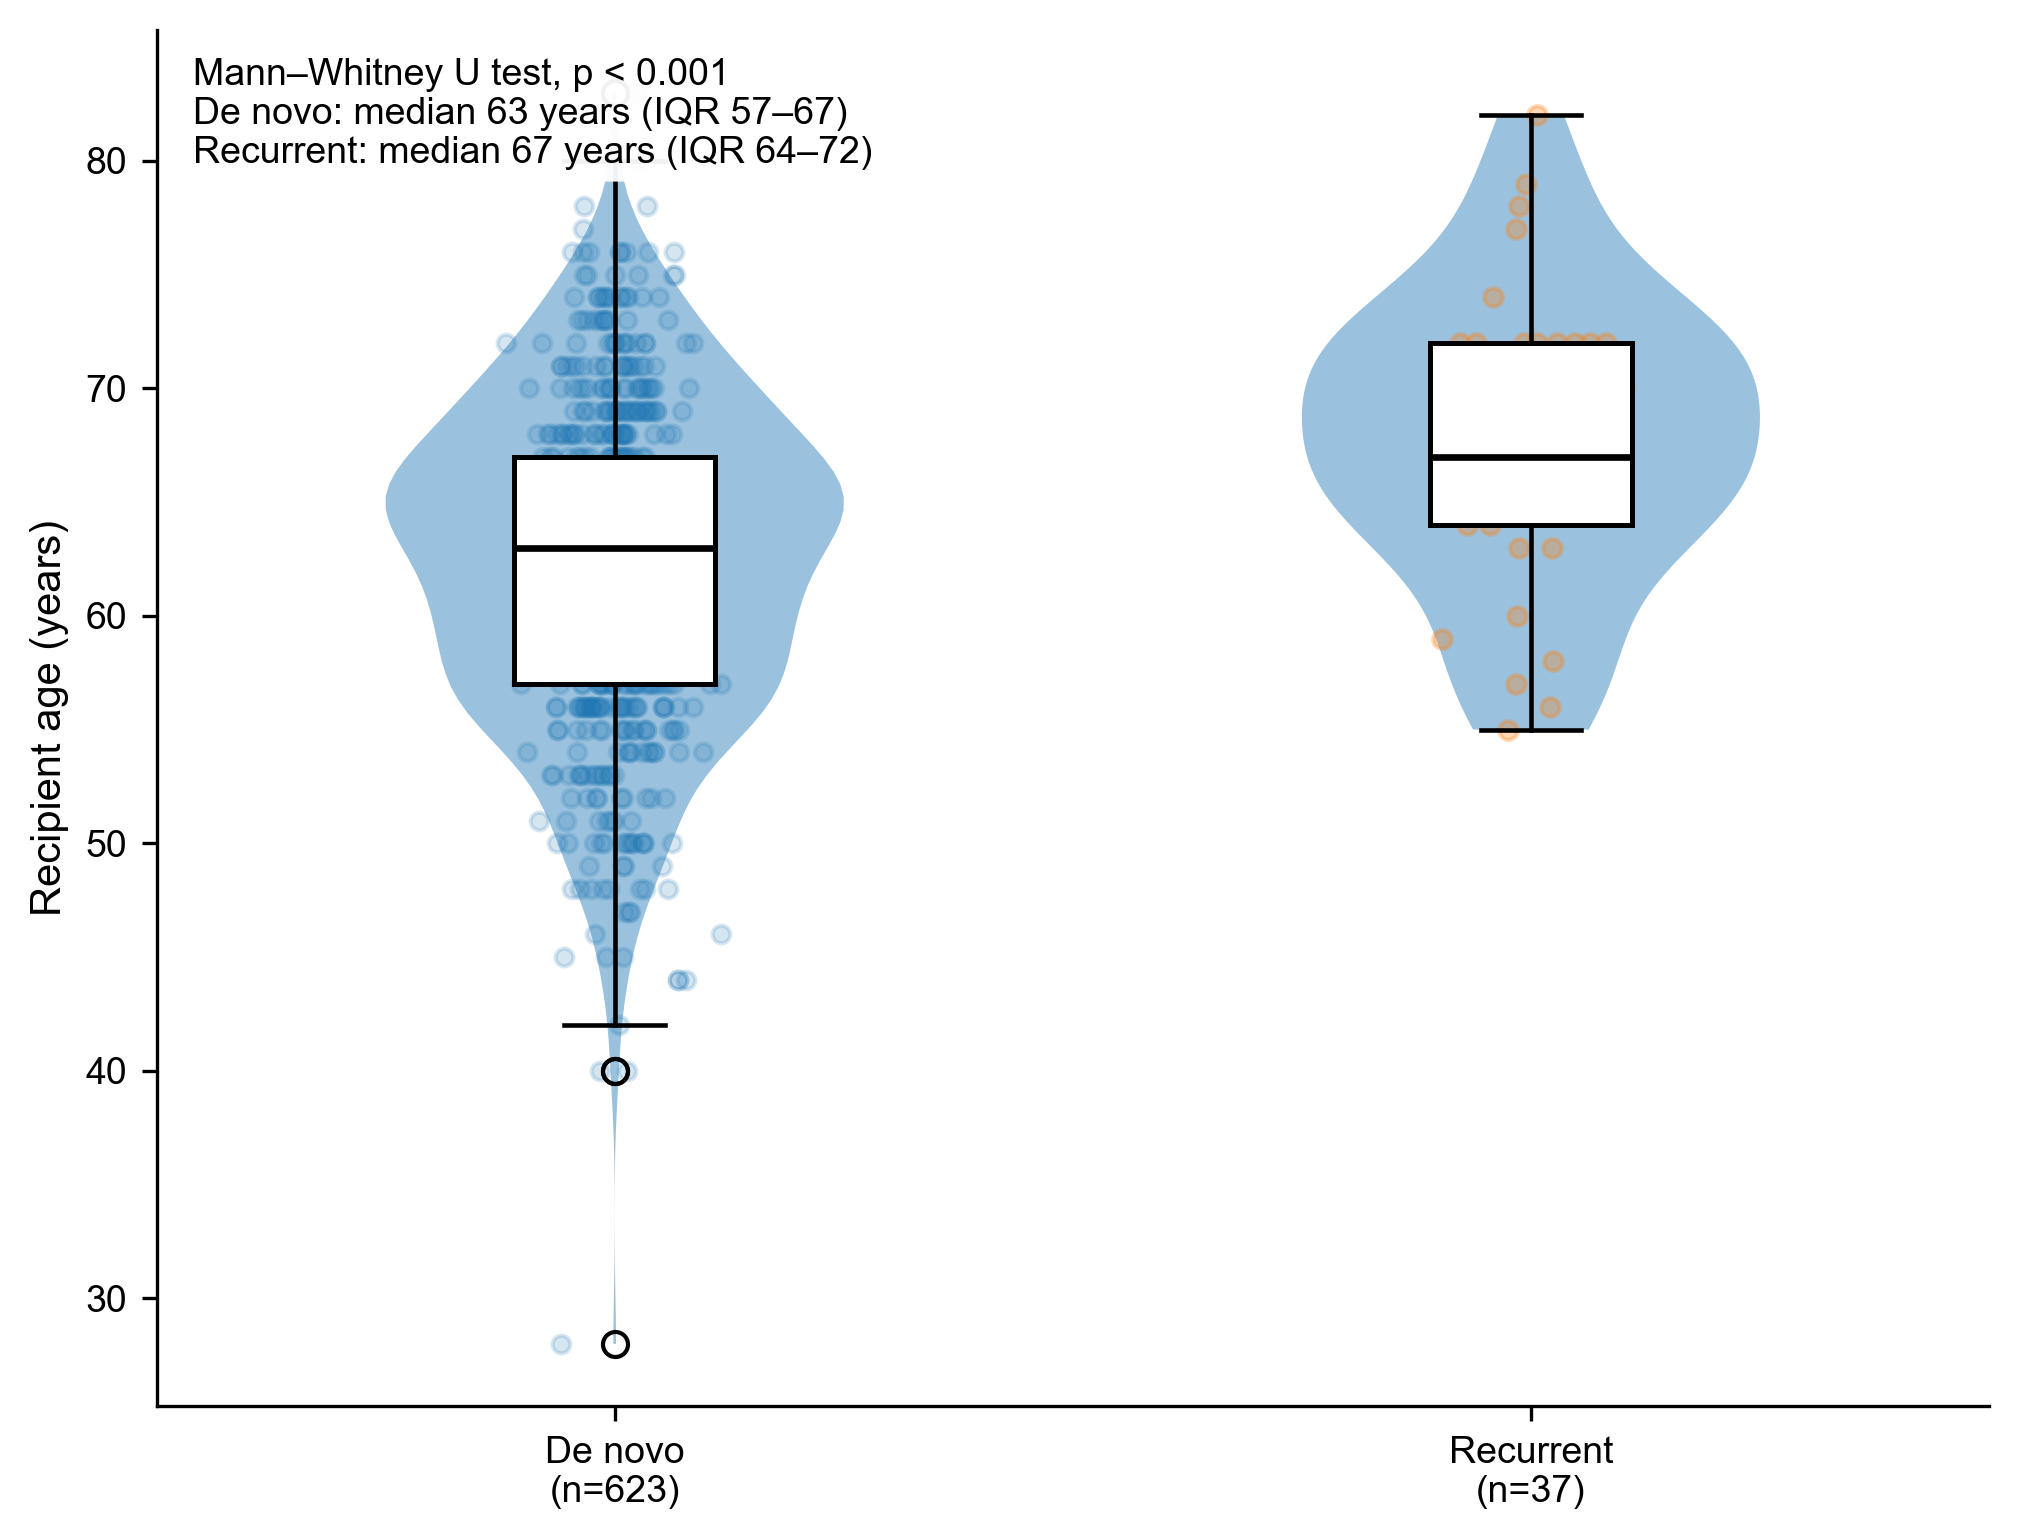

In [62]:
# =========================================================
# FIG 1: RECIPIENT AGE BY PROSTATE CANCER PHENOTYPE
# PLOS-ready export: Fig1.tif
# =========================================================

from scipy.stats import mannwhitneyu

# Data
age_denovo = primary_model_df.loc[primary_model_df['y'] == 0, 'AGE'].dropna()
age_recurr = primary_model_df.loc[primary_model_df['y'] == 1, 'AGE'].dropna()

# Mann–Whitney U test
u_stat, p_value = mannwhitneyu(age_denovo, age_recurr, alternative='two-sided')

# Summary statistics
med_denovo = age_denovo.median()
q1_denovo = age_denovo.quantile(0.25)
q3_denovo = age_denovo.quantile(0.75)
med_recurr = age_recurr.median()
q1_recurr = age_recurr.quantile(0.25)
q3_recurr = age_recurr.quantile(0.75)

# Figure width is kept within PLOS ONE maximum print width (7.5 inches)
fig, ax = plt.subplots(figsize=(6.8, 5.2))

# Violin plot
parts = ax.violinplot(
    [age_denovo, age_recurr],
    positions=[1, 2],
    showmeans=False,
    showmedians=False,
    showextrema=False
)
for pc in parts['bodies']:
    pc.set_alpha(0.45)

# Boxplot overlay
ax.boxplot(
    [age_denovo, age_recurr],
    positions=[1, 2],
    widths=0.22,
    patch_artist=True,
    boxprops=dict(facecolor='white', edgecolor='black', linewidth=1.2),
    whiskerprops=dict(color='black', linewidth=1.1),
    capprops=dict(color='black', linewidth=1.1),
    medianprops=dict(color='black', linewidth=1.6)
)

# Jittered points
rng = np.random.default_rng(42)
x1 = rng.normal(1, 0.04, len(age_denovo))
x2 = rng.normal(2, 0.04, len(age_recurr))
ax.scatter(x1, age_denovo, alpha=0.18, s=18)
ax.scatter(x2, age_recurr, alpha=0.30, s=20)

# Labels
ax.set_xticks([1, 2])
ax.set_xticklabels([
    f'De novo\n(n={len(age_denovo)})',
    f'Recurrent\n(n={len(age_recurr)})'
])
ax.set_ylabel('Recipient age (years)')

# Annotation
p_text = "p < 0.001" if p_value < 0.001 else f"p = {p_value:.3f}"
annotation = (
    f"Mann–Whitney U test, {p_text}\n"
    f"De novo: median {med_denovo:.0f} years (IQR {q1_denovo:.0f}–{q3_denovo:.0f})\n"
    f"Recurrent: median {med_recurr:.0f} years (IQR {q1_recurr:.0f}–{q3_recurr:.0f})"
)
ax.text(
    0.02, 0.98, annotation,
    transform=ax.transAxes,
    ha='left', va='top',
    fontsize=9,
    bbox=dict(boxstyle='round,pad=0.3', facecolor='white', edgecolor='none', alpha=0.95)
)

# Clean style
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.grid(False)

plt.tight_layout()
save_plos_figure(fig, 'Fig1.tif')
plt.show()


**Figure 1. Recipient age by prostate cancer phenotype after kidney transplantation.** 

Violin and box plots show the distribution of recipient age among recipients with de novo and recurrent prostate cancer. Recipients with recurrent disease were older at transplantation than those with de novo disease.

### Aim 2: Phenotype Modeling
----------------------------------
Identify factors independently associated with recurrent versus de novo prostate cancer using multivariable logistic regression. Use multivariable logistic regression to identify factors associated with:
- recurrent vs de novo prostate cancer.


In [63]:
# =========================================================
# STEP 12: AIM 2 - CREATE MODEL-READY VARIABLES
# =========================================================

# Continue from:
# - primary_model_df
# - secondary_model_df

# -----------------------------------------
# 12A. HELPER FUNCTION: TRANSPLANT ERA
# -----------------------------------------
def categorize_era(year):
    if pd.isna(year):
        return np.nan
    elif year <= 2009:
        return '2000–2009'
    elif year <= 2014:
        return '2010–2014'
    elif year <= 2019:
        return '2015–2019'
    else:
        return '2020–2024'


In [64]:
# -----------------------------------------
# 12B. HELPER FUNCTION: INDUCTION REGIMEN
# -----------------------------------------
def derive_induction_regimen(row):
    if row.get('i_none', 0) == 1:
        return 'None'
    elif row.get('i_thy', 0) == 1:
        return 'Thymoglobulin'
    elif row.get('i_ale', 0) == 1:
        return 'Alemtuzumab'
    elif row.get('i_bas_dac', 0) == 1:
        return 'IL-2R antagonist'
    elif row.get('i_thy_bas_dac', 0) == 1:
        return 'ATG + IL-2R antagonist'
    else:
        return np.nan


In [65]:
# -----------------------------------------
# 12C. HELPER FUNCTION: MAINTENANCE REGIMEN
# -----------------------------------------
def derive_maintenance_regimen(row):
    if row.get('c_ci_mmf', 0) == 1:
        return 'CNI + MMF'
    elif row.get('c_ci_mmf_steroids', 0) == 1:
        return 'CNI + MMF + steroids'
    elif row.get('c_mtor_mmf', 0) == 1:
        return 'mTOR + MMF'
    elif row.get('c_mtor_mmf_steroids', 0) == 1:
        return 'mTOR + MMF + steroids'
    else:
        return np.nan


In [66]:
# -----------------------------------------
# 12D. APPLY TO PRIMARY MODEL DATASET
# -----------------------------------------
primary_model_df = primary_model_df.copy()

# Outcome
primary_model_df['y'] = primary_model_df['y'].astype(int)

# Era
if 'txyr' in primary_model_df.columns:
    primary_model_df['tx_era'] = primary_model_df['txyr'].apply(categorize_era)
    primary_model_df['tx_era'] = pd.Categorical(
        primary_model_df['tx_era'],
        categories=['2000–2009', '2010–2014', '2015–2019', '2020–2024'],
        ordered=True
    )

# Regimens
primary_model_df['induction_regimen'] = primary_model_df.apply(derive_induction_regimen, axis=1)
primary_model_df['maintenance_regimen'] = primary_model_df.apply(derive_maintenance_regimen, axis=1)

# Keep collapsed functional status for modeling
# Assumes func_stat_model already exists from your earlier step
if 'func_stat_model' in primary_model_df.columns:
    primary_model_df['func_stat_model'] = pd.Categorical(
        primary_model_df['func_stat_model'],
        categories=['70-100', '50-60', '10-40', 'Unknown'],
        ordered=True
    )

# Optional: clean categorical ordering for regimen variables
primary_model_df['induction_regimen'] = pd.Categorical(
    primary_model_df['induction_regimen'],
    categories=['IL-2R antagonist', 'Thymoglobulin', 'Alemtuzumab', 'None', 'ATG + IL-2R antagonist']
)

primary_model_df['maintenance_regimen'] = pd.Categorical(
    primary_model_df['maintenance_regimen'],
    categories=['CNI + MMF', 'CNI + MMF + steroids', 'mTOR + MMF', 'mTOR + MMF + steroids']
)

print("\nPrimary model dataset with model-ready variables:", primary_model_df.shape)
print("\nInduction regimen counts (primary):")
print(primary_model_df['induction_regimen'].value_counts(dropna=False))
print("\nMaintenance regimen counts (primary):")
print(primary_model_df['maintenance_regimen'].value_counts(dropna=False))
print("\nTransplant era counts (primary):")
print(primary_model_df['tx_era'].value_counts(dropna=False))



Primary model dataset with model-ready variables: (660, 57)

Induction regimen counts (primary):
induction_regimen
Thymoglobulin             371
IL-2R antagonist          161
Alemtuzumab                81
None                       37
ATG + IL-2R antagonist     10
Name: count, dtype: int64

Maintenance regimen counts (primary):
maintenance_regimen
CNI + MMF + steroids     476
CNI + MMF                184
mTOR + MMF                 0
mTOR + MMF + steroids      0
Name: count, dtype: int64

Transplant era counts (primary):
tx_era
2015–2019    477
2020–2024    183
2000–2009      0
2010–2014      0
Name: count, dtype: int64


In [67]:
# -----------------------------------------
# 12E. APPLY TO SECONDARY MODEL DATASET
# -----------------------------------------
secondary_model_df = secondary_model_df.copy()

# Outcome
secondary_model_df['y'] = secondary_model_df['y'].astype(int)

# Era
if 'txyr' in secondary_model_df.columns:
    secondary_model_df['tx_era'] = secondary_model_df['txyr'].apply(categorize_era)
    secondary_model_df['tx_era'] = pd.Categorical(
        secondary_model_df['tx_era'],
        categories=['2000–2009', '2010–2014', '2015–2019', '2020–2024'],
        ordered=True
    )

# Regimens
secondary_model_df['induction_regimen'] = secondary_model_df.apply(derive_induction_regimen, axis=1)
secondary_model_df['maintenance_regimen'] = secondary_model_df.apply(derive_maintenance_regimen, axis=1)

# Functional status
if 'func_stat_model' in secondary_model_df.columns:
    secondary_model_df['func_stat_model'] = pd.Categorical(
        secondary_model_df['func_stat_model'],
        categories=['70-100', '50-60', '10-40', 'Unknown'],
        ordered=True
    )

secondary_model_df['induction_regimen'] = pd.Categorical(
    secondary_model_df['induction_regimen'],
    categories=['IL-2R antagonist', 'Thymoglobulin', 'Alemtuzumab', 'None', 'ATG + IL-2R antagonist']
)

secondary_model_df['maintenance_regimen'] = pd.Categorical(
    secondary_model_df['maintenance_regimen'],
    categories=['CNI + MMF', 'CNI + MMF + steroids', 'mTOR + MMF', 'mTOR + MMF + steroids']
)

print("\nSecondary model dataset with model-ready variables:", secondary_model_df.shape)
print("\nInduction regimen counts (secondary):")
print(secondary_model_df['induction_regimen'].value_counts(dropna=False))
print("\nMaintenance regimen counts (secondary):")
print(secondary_model_df['maintenance_regimen'].value_counts(dropna=False))
print("\nTransplant era counts (secondary):")
print(secondary_model_df['tx_era'].value_counts(dropna=False))


Secondary model dataset with model-ready variables: (468, 60)

Induction regimen counts (secondary):
induction_regimen
Thymoglobulin             297
IL-2R antagonist           88
Alemtuzumab                49
None                       26
ATG + IL-2R antagonist      8
Name: count, dtype: int64

Maintenance regimen counts (secondary):
maintenance_regimen
CNI + MMF + steroids     351
CNI + MMF                117
mTOR + MMF                 0
mTOR + MMF + steroids      0
Name: count, dtype: int64

Transplant era counts (secondary):
tx_era
2015–2019    325
2020–2024    143
2000–2009      0
2010–2014      0
Name: count, dtype: int64


In [68]:
# =========================================================
# STEP 12F: FINAL CLEANUP BEFORE MODELING
# =========================================================

# Add "Other" category and fill NaN
#for df_ in [primary_model_df, secondary_model_df]:
#    df_['induction_regimen'] = df_['induction_regimen'].cat.add_categories(['Other'])
#    df_['induction_regimen'] = df_['induction_regimen'].fillna('Other')

# Set ATG as reference
for df_ in [primary_model_df, secondary_model_df]:
    df_['induction_regimen'] = df_['induction_regimen'].cat.reorder_categories(
        ['Thymoglobulin', 'IL-2R antagonist', 'Alemtuzumab', 'None', 'ATG + IL-2R antagonist'],
        ordered=False
    )

print("\nFinal induction counts (primary):")
print(primary_model_df['induction_regimen'].value_counts())

print("\nFinal induction counts (secondary):")
print(secondary_model_df['induction_regimen'].value_counts())


Final induction counts (primary):
induction_regimen
Thymoglobulin             371
IL-2R antagonist          161
Alemtuzumab                81
None                       37
ATG + IL-2R antagonist     10
Name: count, dtype: int64

Final induction counts (secondary):
induction_regimen
Thymoglobulin             297
IL-2R antagonist           88
Alemtuzumab                49
None                       26
ATG + IL-2R antagonist      8
Name: count, dtype: int64


In [69]:
# =========================================================
# STEP 13: DEFINE AIM 2 PRIMARY AND SECONDARY MODEL DATASETS
# =========================================================

# -----------------------------------------
# 13A. PRIMARY AIM 2 MODEL VARIABLES
# -----------------------------------------
primary_aim2_vars = [
    'y',
    'AGE',
    'BMI_CALC',
    'AGE_DON',
    'HLAMIS',
    'TOT_SERUM_ALBUM',
    'func_stat_model',
    'induction_regimen',
    'maintenance_regimen',
    'tx_era'
]

aim2_primary_df = primary_model_df[[col for col in primary_aim2_vars if col in primary_model_df.columns]].copy()

print("\nAim 2 primary model dataset shape:", aim2_primary_df.shape)
print("\nMissingness in Aim 2 primary model dataset:")
print(aim2_primary_df.isna().sum())


# -----------------------------------------
# 13B. SECONDARY AIM 2 MODEL VARIABLES
# deceased donors only, allowing donor-specific variables
# -----------------------------------------
secondary_aim2_vars = [
    'y',
    'AGE',
    'BMI_CALC',
    'AGE_DON',
    'HLAMIS',
    'TOT_SERUM_ALBUM',
    'func_stat_model',
    'induction_regimen',
    'maintenance_regimen',
    'tx_era',
    'KDPI',
    'CREAT_DON',
    'ECD_DONOR'
]

aim2_secondary_df = secondary_model_df[[col for col in secondary_aim2_vars if col in secondary_model_df.columns]].copy()

print("\nAim 2 secondary model dataset shape:", aim2_secondary_df.shape)
print("\nMissingness in Aim 2 secondary model dataset:")
print(aim2_secondary_df.isna().sum())


Aim 2 primary model dataset shape: (660, 10)

Missingness in Aim 2 primary model dataset:
y                      0
AGE                    0
BMI_CALC               0
AGE_DON                0
HLAMIS                 0
TOT_SERUM_ALBUM        0
func_stat_model        0
induction_regimen      0
maintenance_regimen    0
tx_era                 0
dtype: int64

Aim 2 secondary model dataset shape: (468, 13)

Missingness in Aim 2 secondary model dataset:
y                      0
AGE                    0
BMI_CALC               0
AGE_DON                0
HLAMIS                 0
TOT_SERUM_ALBUM        0
func_stat_model        0
induction_regimen      0
maintenance_regimen    0
tx_era                 0
KDPI                   0
CREAT_DON              0
ECD_DONOR              0
dtype: int64


In [70]:
# =========================================================
# STEP 14: PRE-MODEL DIAGNOSTICS
# =========================================================

def check_categorical_distribution(df, var, outcome='y'):
    print(f"\n=== {var} vs {outcome} ===")
    
    tab = pd.crosstab(df[var], df[outcome], margins=True)
    print("\nCounts:")
    print(tab)
    
    # Row percentages
    tab_pct = pd.crosstab(df[var], df[outcome], normalize='index') * 100
    print("\nRow percentages (%):")
    print(tab_pct.round(1))


# -----------------------------------------
# 14A. PRIMARY MODEL DATASET CHECKS
# -----------------------------------------
print("\n================ PRIMARY DATASET =================")

categorical_vars_check = [
    'induction_regimen',
    'maintenance_regimen',
    'func_stat_model',
    'tx_era'
]

for var in categorical_vars_check:
    check_categorical_distribution(aim2_primary_df, var)


# -----------------------------------------
# 14B. SECONDARY MODEL DATASET CHECKS
# -----------------------------------------
print("\n================ SECONDARY DATASET =================")

for var in categorical_vars_check:
    check_categorical_distribution(aim2_secondary_df, var)


================ PRIMARY DATASET =================

=== induction_regimen vs y ===

Counts:
y                         0   1  All
induction_regimen                   
Thymoglobulin           354  17  371
IL-2R antagonist        146  15  161
Alemtuzumab              76   5   81
None                     37   0   37
ATG + IL-2R antagonist   10   0   10
All                     623  37  660

Row percentages (%):
y                           0    1
induction_regimen                 
Thymoglobulin            95.4  4.6
IL-2R antagonist         90.7  9.3
Alemtuzumab              93.8  6.2
None                    100.0  0.0
ATG + IL-2R antagonist  100.0  0.0

=== maintenance_regimen vs y ===

Counts:
y                       0   1  All
maintenance_regimen               
CNI + MMF             176   8  184
CNI + MMF + steroids  447  29  476
All                   623  37  660

Row percentages (%):
y                        0    1
maintenance_regimen            
CNI + MMF             95.7  4.3
CNI + MM

In [71]:
# -----------------------------------------
# 14C. CONTINUOUS VARIABLES BY OUTCOME
# -----------------------------------------
cont_vars = ['AGE', 'BMI_CALC', 'AGE_DON', 'HLAMIS', 'TOT_SERUM_ALBUM']

for var in cont_vars:
    print(f"\n=== {var} by outcome ===")
    summary = aim2_primary_df.groupby('y')[var].agg(
        count='count',
        median='median',
        mean='mean',
        std='std'
    )
    print(summary)


=== AGE by outcome ===
   count  median       mean       std
y                                    
0    623    63.0  62.317817  7.258997
1     37    67.0  67.810811  6.406758

=== BMI_CALC by outcome ===
   count     median       mean       std
y                                       
0    623  28.344964  28.691292  4.390221
1     37  26.533128  27.068879  3.656000

=== AGE_DON by outcome ===
   count  median       mean        std
y                                     
0    623    46.0  44.195827  13.763979
1     37    53.0  50.540541  12.091307

=== HLAMIS by outcome ===
   count  median      mean       std
y                                   
0    623     4.0  4.176565  1.412267
1     37     4.0  4.324324    1.0015

=== TOT_SERUM_ALBUM by outcome ===
   count  median      mean       std
y                                   
0    623     4.0  3.999518  0.544440
1     37     4.1  3.959459  0.479849


In [72]:
# =========================================================
# STEP 15A: FINAL MODEL PREPARATION
# =========================================================

# y = 1 (recurrent), 0 (de novo)

model_df = aim2_primary_df.copy()

# Ensure categorical types
categorical_vars = [
    'induction_regimen',
    'maintenance_regimen',
    'func_stat_model',
    'tx_era'
]

for col in categorical_vars:
    model_df[col] = model_df[col].astype('category')

# Confirm reference category (ATG already first)
print("\nInduction categories (order matters):")
print(model_df['induction_regimen'].cat.categories)

print("\nFinal model dataset shape:", model_df.shape)


Induction categories (order matters):
Index(['Thymoglobulin', 'IL-2R antagonist', 'Alemtuzumab', 'None',
       'ATG + IL-2R antagonist'],
      dtype='object')

Final model dataset shape: (660, 10)


In [73]:
# =========================================================
# STEP 15B: CHECK rpy2 + R + logistf
# =========================================================

print("=== Checking rpy2 installation ===")
try:
    import rpy2
    print("rpy2 is installed ✅")
except ImportError:
    print("rpy2 NOT installed ❌")

print("\n=== Checking R connection ===")
try:
    import rpy2.robjects as ro
    r_version = ro.r("R.version.string")
    print("R is accessible from Python ✅")
    print("R version:", r_version[0])
except Exception as e:
    print("R NOT accessible ❌")
    print(e)

print("\n=== Checking logistf package in R ===")
try:
    ro.r('library(logistf)')
    print("logistf is already installed and loaded ✅")
except Exception as e:
    print("logistf NOT available ❌")
    print("Attempting to install...")

    try:
        ro.r('install.packages("logistf", repos="https://cloud.r-project.org")')
        ro.r('library(logistf)')
        print("logistf successfully installed and loaded ✅")
    except Exception as install_error:
        print("Failed to install logistf ❌")
        print(install_error)

=== Checking rpy2 installation ===
rpy2 is installed ✅

=== Checking R connection ===
R is accessible from Python ✅
R version: R version 4.6.1 (2026-06-24 ucrt)

=== Checking logistf package in R ===
logistf is already installed and loaded ✅


##### Primary model
- Parsimonious
- Firth
- Core covariates

This is the main inference

In [74]:
# =========================================================
# STEP 16: AIM 2 PRIMARY MODEL - FIRTH LOGISTIC REGRESSION
# =========================================================

from rpy2.robjects import pandas2ri, r
from rpy2.robjects.conversion import localconverter
import rpy2.robjects as ro

# -----------------------------------------
# 16A. BUILD PARSIMONIOUS PRIMARY MODEL DATASET
# -----------------------------------------
firth_primary_vars = [
    'y',
    'AGE',
    'induction_regimen',
    'maintenance_regimen',
    'HLAMIS',
    'TOT_SERUM_ALBUM',
    'AGE_DON',
    'tx_era'
]

firth_primary_df = aim2_primary_df[firth_primary_vars].copy()

print("Firth primary dataset shape:", firth_primary_df.shape)
print("\nOutcome counts:")
print(firth_primary_df['y'].value_counts())

print("\nInduction regimen counts:")
print(firth_primary_df['induction_regimen'].value_counts(dropna=False))

print("\nMaintenance regimen counts:")
print(firth_primary_df['maintenance_regimen'].value_counts(dropna=False))

print("\nTransplant era counts:")
print(firth_primary_df['tx_era'].value_counts(dropna=False))


Firth primary dataset shape: (660, 8)

Outcome counts:
y
0    623
1     37
Name: count, dtype: int64

Induction regimen counts:
induction_regimen
Thymoglobulin             371
IL-2R antagonist          161
Alemtuzumab                81
None                       37
ATG + IL-2R antagonist     10
Name: count, dtype: int64

Maintenance regimen counts:
maintenance_regimen
CNI + MMF + steroids     476
CNI + MMF                184
mTOR + MMF                 0
mTOR + MMF + steroids      0
Name: count, dtype: int64

Transplant era counts:
tx_era
2015–2019    477
2020–2024    183
2000–2009      0
2010–2014      0
Name: count, dtype: int64


In [75]:

# -----------------------------------------
# 16B. PASS DATA TO R
# -----------------------------------------
with localconverter(ro.default_converter + pandas2ri.converter):
    ro.globalenv['firth_primary_df'] = firth_primary_df


In [76]:
# -----------------------------------------
# 16C. FIT FIRTH MODEL IN R
# Reference levels:
# - induction_regimen: Thymoglobulin
# - maintenance_regimen: CNI + MMF
# - tx_era: 2015–2019
# -----------------------------------------
r_code = """
library(logistf)

df <- as.data.frame(firth_primary_df)

# Ensure proper factor coding and reference categories
df$induction_regimen <- factor(
  df$induction_regimen,
  levels = c("Thymoglobulin", "IL-2R antagonist", "Alemtuzumab", "None", "ATG + IL-2R antagonist")
)

df$maintenance_regimen <- factor(
  df$maintenance_regimen,
  levels = c("CNI + MMF", "CNI + MMF + steroids")
)

df$tx_era <- factor(
  df$tx_era,
  levels = c("2015–2019", "2020–2024")
)

# Fit Firth penalized logistic regression
fit_firth_primary <- logistf(
  formula = y ~ AGE + induction_regimen + maintenance_regimen + HLAMIS +
                 TOT_SERUM_ALBUM + AGE_DON + tx_era,
  data = df,
  pl = TRUE
)

# Build results table
results_primary <- data.frame(
  term = names(fit_firth_primary$coefficients),
  estimate = as.numeric(fit_firth_primary$coefficients),
  conf.low = as.numeric(fit_firth_primary$ci.lower),
  conf.high = as.numeric(fit_firth_primary$ci.upper),
  p.value = as.numeric(fit_firth_primary$prob)
)

results_primary$OR <- exp(results_primary$estimate)
results_primary$OR_low <- exp(results_primary$conf.low)
results_primary$OR_high <- exp(results_primary$conf.high)

results_primary <- results_primary[, c("term", "OR", "OR_low", "OR_high", "p.value")]

results_primary
"""

r_results_primary = r(r_code)

with localconverter(ro.default_converter + pandas2ri.converter):
    firth_primary_results = ro.conversion.rpy2py(r_results_primary)


In [77]:

# -----------------------------------------
# 16D. CLEAN RESULTS FOR DISPLAY
# -----------------------------------------
firth_primary_results = firth_primary_results.copy()
firth_primary_results = firth_primary_results.rename(
    columns={
        'OR_low': 'CI_lower',
        'OR_high': 'CI_upper',
        'p.value': 'p_value'
    }
)

# Drop intercept row for manuscript-style reporting
firth_primary_results_no_intercept = firth_primary_results[
    firth_primary_results['term'] != '(Intercept)'
].copy()

# Pretty formatting
firth_primary_results_no_intercept['OR (95% CI)'] = (
    firth_primary_results_no_intercept['OR'].round(3).astype(str)
    + " ("
    + firth_primary_results_no_intercept['CI_lower'].round(3).astype(str)
    + ", "
    + firth_primary_results_no_intercept['CI_upper'].round(3).astype(str)
    + ")"
)

print("\nAim 2 primary Firth model results:")
print(firth_primary_results_no_intercept[['term', 'OR (95% CI)', 'p_value']].to_string(index=False))


Aim 2 primary Firth model results:
                                   term           OR (95% CI)  p_value
                                    AGE  1.107 (1.048, 1.174) 0.000224
      induction_regimenIL-2R antagonist  1.509 (0.707, 3.186) 0.283215
           induction_regimenAlemtuzumab  2.286 (0.728, 6.372) 0.147582
                  induction_regimenNone  0.362 (0.003, 2.865) 0.413286
induction_regimenATG + IL-2R antagonist 1.473 (0.011, 14.019) 0.806431
maintenance_regimenCNI + MMF + steroids  1.506 (0.671, 3.716) 0.331434
                                 HLAMIS  1.105 (0.863, 1.449) 0.440252
                        TOT_SERUM_ALBUM   0.895 (0.46, 1.756) 0.748739
                                AGE_DON  1.021 (0.996, 1.049) 0.099525
                               tx_era.L  1.247 (0.748, 2.035) 0.388658


##### Output result

AGE OR = 1.107 (1.048–1.174), p < 0.001

Interpretation:

Each 1-year increase in recipient age is associated with ~10.7% higher odds of recurrent (vs de novo) prostate cancer.

So:

- Higher age → more likely recurrent phenotype
- Lower age → more likely de novo phenotype

This is biologically very plausible:
- older patients → more likely to have prior prostate cancer history → recurrence
- younger patients → more likely de novo

#### Sensitivity Model 1: Add frailty

**What to look for in the output below**

Focus on three questions:

1. Does AGE remain significant?
    - If yes, that strengthens your primary finding.
2. Do the induction estimates change materially?
    - If they remain similar, that suggests frailty is not driving the regimen associations.
3. Does functional status itself show signal?
    - It may still be imprecise because some levels had zero recurrent cases.

In [78]:
# =========================================================
# STEP 17A: AIM 2 SENSITIVITY MODEL - ADD FUNCTIONAL STATUS
# =========================================================

from rpy2.robjects import pandas2ri, r
from rpy2.robjects.conversion import localconverter
import rpy2.robjects as ro

# -----------------------------------------
# 17A.1 BUILD SENSITIVITY DATASET
# -----------------------------------------
firth_fs_vars = [
    'y',
    'AGE',
    'induction_regimen',
    'maintenance_regimen',
    'HLAMIS',
    'TOT_SERUM_ALBUM',
    'AGE_DON',
    'tx_era',
    'func_stat_model'
]

firth_fs_df = aim2_primary_df[firth_fs_vars].copy()

# Ensure categorical ordering is preserved for Python side
firth_fs_df['induction_regimen'] = pd.Categorical(
    firth_fs_df['induction_regimen'],
    categories=['Thymoglobulin', 'IL-2R antagonist', 'Alemtuzumab', 'None', 'ATG + IL-2R antagonist']
)

firth_fs_df['maintenance_regimen'] = pd.Categorical(
    firth_fs_df['maintenance_regimen'],
    categories=['CNI + MMF', 'CNI + MMF + steroids']
)

firth_fs_df['tx_era'] = pd.Categorical(
    firth_fs_df['tx_era'],
    categories=['2015–2019', '2020–2024']
)

firth_fs_df['func_stat_model'] = pd.Categorical(
    firth_fs_df['func_stat_model'],
    categories=['70-100', '50-60', '10-40', 'Unknown']
)

print("Firth sensitivity dataset shape:", firth_fs_df.shape)
print("\nOutcome counts:")
print(firth_fs_df['y'].value_counts())

print("\nFunctional status counts:")
print(firth_fs_df['func_stat_model'].value_counts(dropna=False))

print("\nFunctional status by outcome:")
print(pd.crosstab(firth_fs_df['func_stat_model'], firth_fs_df['y'], margins=True))


Firth sensitivity dataset shape: (660, 9)

Outcome counts:
y
0    623
1     37
Name: count, dtype: int64

Functional status counts:
func_stat_model
70-100     522
50-60      104
Unknown     22
10-40       12
Name: count, dtype: int64

Functional status by outcome:
y                  0   1  All
func_stat_model              
70-100           489  33  522
50-60            100   4  104
10-40             12   0   12
Unknown           22   0   22
All              623  37  660


In [79]:
# -----------------------------------------
# 17A.2 PASS DATA TO R
# -----------------------------------------
with localconverter(ro.default_converter + pandas2ri.converter):
    ro.globalenv['firth_fs_df'] = firth_fs_df

# -----------------------------------------
# 17A.3 FIT FIRTH MODEL IN R
# Reference levels:
# - induction_regimen: Thymoglobulin
# - maintenance_regimen: CNI + MMF
# - tx_era: 2015–2019
# - func_stat_model: 70-100
# -----------------------------------------
r_code_fs = """
library(logistf)

df <- as.data.frame(firth_fs_df)

df$induction_regimen <- factor(
  df$induction_regimen,
  levels = c("Thymoglobulin", "IL-2R antagonist", "Alemtuzumab", "None", "ATG + IL-2R antagonist")
)

df$maintenance_regimen <- factor(
  df$maintenance_regimen,
  levels = c("CNI + MMF", "CNI + MMF + steroids")
)

df$tx_era <- factor(
  df$tx_era,
  levels = c("2015–2019", "2020–2024")
)

df$func_stat_model <- factor(
  df$func_stat_model,
  levels = c("70-100", "50-60", "10-40", "Unknown")
)

contrasts(df$func_stat_model) <- contr.treatment(n = 4, base = 1)

fit_firth_fs <- logistf(
  formula = y ~ AGE + induction_regimen + maintenance_regimen + HLAMIS +
                 TOT_SERUM_ALBUM + AGE_DON + tx_era + func_stat_model,
  data = df,
  pl = TRUE
)

results_fs <- data.frame(
  term = names(fit_firth_fs$coefficients),
  estimate = as.numeric(fit_firth_fs$coefficients),
  conf.low = as.numeric(fit_firth_fs$ci.lower),
  conf.high = as.numeric(fit_firth_fs$ci.upper),
  p.value = as.numeric(fit_firth_fs$prob)
)

results_fs$OR <- exp(results_fs$estimate)
results_fs$OR_low <- exp(results_fs$conf.low)
results_fs$OR_high <- exp(results_fs$conf.high)

results_fs <- results_fs[, c("term", "OR", "OR_low", "OR_high", "p.value")]

results_fs
"""

r_results_fs = r(r_code_fs)

with localconverter(ro.default_converter + pandas2ri.converter):
    firth_fs_results = ro.conversion.rpy2py(r_results_fs)


In [80]:

# -----------------------------------------
# 17A.4 CLEAN RESULTS FOR DISPLAY
# -----------------------------------------
firth_fs_results = firth_fs_results.rename(
    columns={
        'OR_low': 'CI_lower',
        'OR_high': 'CI_upper',
        'p.value': 'p_value'
    }
)

firth_fs_results_no_intercept = firth_fs_results[
    firth_fs_results['term'] != '(Intercept)'
].copy()

firth_fs_results_no_intercept['OR (95% CI)'] = (
    firth_fs_results_no_intercept['OR'].round(3).astype(str)
    + " ("
    + firth_fs_results_no_intercept['CI_lower'].round(3).astype(str)
    + ", "
    + firth_fs_results_no_intercept['CI_upper'].round(3).astype(str)
    + ")"
)

print("\nAim 2 sensitivity Firth model results (with functional status):")
print(firth_fs_results_no_intercept[['term', 'OR (95% CI)', 'p_value']].to_string(index=False))


Aim 2 sensitivity Firth model results (with functional status):
                                   term          OR (95% CI)  p_value
                                    AGE 1.107 (1.048, 1.175) 0.000241
      induction_regimenIL-2R antagonist 1.443 (0.671, 3.063) 0.343214
           induction_regimenAlemtuzumab   2.29 (0.73, 6.373) 0.146365
                  induction_regimenNone   0.326 (0.003, 2.6) 0.361002
induction_regimenATG + IL-2R antagonist 1.347 (0.01, 12.864) 0.848905
maintenance_regimenCNI + MMF + steroids 1.689 (0.748, 4.181) 0.213757
                                 HLAMIS 1.127 (0.877, 1.485) 0.361909
                        TOT_SERUM_ALBUM   0.83 (0.42, 1.653) 0.598623
                                AGE_DON 1.018 (0.993, 1.046) 0.163376
                               tx_era.L  1.27 (0.759, 2.081) 0.355783
                       func_stat_model2 0.587 (0.182, 1.508) 0.287113
                       func_stat_model3 0.346 (0.003, 2.946) 0.402880
                       fu

**Compare to the primary model:**

AGE
- Before: 1.107 (1.048–1.174), p ≈ 0.0002
- After: 1.107 (1.048–1.175), p ≈ 0.00024

No change. The age effect is robust to frailty adjustment

Induction regimens
- IL-2R: 1.51 → 1.44
- Alemtuzumab: ~2.29 → ~2.29 (unchanged)

Slight attenuation, but same direction. Frailty is not explaining the immunosuppression signal

Functional status was not independently associated with prostate cancer phenotype after adjustment, although estimates were imprecise due to sparse events in lower functional-status categories.

#### Sensitivity Model 2: Add dialysis / retransplant

In [81]:
# =========================================================
# STEP 17B: AIM 2 SENSITIVITY MODEL - ADD DIALYSIS + RETX
# =========================================================

from rpy2.robjects import pandas2ri, r
from rpy2.robjects.conversion import localconverter
import rpy2.robjects as ro

# -----------------------------------------
# 17B.1 BUILD SENSITIVITY DATASET
# -----------------------------------------
firth_dr_vars = [
    'y',
    'AGE',
    'induction_regimen',
    'maintenance_regimen',
    'HLAMIS',
    'TOT_SERUM_ALBUM',
    'AGE_DON',
    'tx_era',
    'ON_DIALYSIS',
    'retx'
]

firth_dr_df = primary_model_df[firth_dr_vars].copy()

# Ensure categorical ordering is preserved
firth_dr_df['induction_regimen'] = pd.Categorical(
    firth_dr_df['induction_regimen'],
    categories=['Thymoglobulin', 'IL-2R antagonist', 'Alemtuzumab', 'None', 'ATG + IL-2R antagonist']
)

firth_dr_df['maintenance_regimen'] = pd.Categorical(
    firth_dr_df['maintenance_regimen'],
    categories=['CNI + MMF', 'CNI + MMF + steroids']
)

firth_dr_df['tx_era'] = pd.Categorical(
    firth_dr_df['tx_era'],
    categories=['2015–2019', '2020–2024']
)

print("Firth dialysis/retransplant sensitivity dataset shape:", firth_dr_df.shape)
print("\nOutcome counts:")
print(firth_dr_df['y'].value_counts())

print("\nDialysis counts:")
print(firth_dr_df['ON_DIALYSIS'].value_counts(dropna=False))

print("\nRetransplant counts:")
print(firth_dr_df['retx'].value_counts(dropna=False))

print("\nDialysis by outcome:")
print(pd.crosstab(firth_dr_df['ON_DIALYSIS'], firth_dr_df['y'], margins=True))

print("\nRetransplant by outcome:")
print(pd.crosstab(firth_dr_df['retx'], firth_dr_df['y'], margins=True))


# -----------------------------------------
# 17B.2 PASS DATA TO R
# -----------------------------------------
with localconverter(ro.default_converter + pandas2ri.converter):
    ro.globalenv['firth_dr_df'] = firth_dr_df

# -----------------------------------------
# 17B.3 FIT FIRTH MODEL IN R
# Reference levels:
# - induction_regimen: Thymoglobulin
# - maintenance_regimen: CNI + MMF
# - tx_era: 2015–2019
# - ON_DIALYSIS: 0
# - retx: 0
# -----------------------------------------
r_code_dr = """
library(logistf)

df <- as.data.frame(firth_dr_df)

df$induction_regimen <- factor(
  df$induction_regimen,
  levels = c("Thymoglobulin", "IL-2R antagonist", "Alemtuzumab", "None", "ATG + IL-2R antagonist")
)

df$maintenance_regimen <- factor(
  df$maintenance_regimen,
  levels = c("CNI + MMF", "CNI + MMF + steroids")
)

df$tx_era <- factor(
  df$tx_era,
  levels = c("2015–2019", "2020–2024")
)

df$ON_DIALYSIS <- factor(df$ON_DIALYSIS, levels = c(0, 1))
df$retx <- factor(df$retx, levels = c(0, 1))

fit_firth_dr <- logistf(
  formula = y ~ AGE + induction_regimen + maintenance_regimen + HLAMIS +
                 TOT_SERUM_ALBUM + AGE_DON + tx_era + ON_DIALYSIS + retx,
  data = df,
  pl = TRUE
)

results_dr <- data.frame(
  term = names(fit_firth_dr$coefficients),
  estimate = as.numeric(fit_firth_dr$coefficients),
  conf.low = as.numeric(fit_firth_dr$ci.lower),
  conf.high = as.numeric(fit_firth_dr$ci.upper),
  p.value = as.numeric(fit_firth_dr$prob)
)

results_dr$OR <- exp(results_dr$estimate)
results_dr$OR_low <- exp(results_dr$conf.low)
results_dr$OR_high <- exp(results_dr$conf.high)

results_dr <- results_dr[, c("term", "OR", "OR_low", "OR_high", "p.value")]

results_dr
"""

r_results_dr = r(r_code_dr)

with localconverter(ro.default_converter + pandas2ri.converter):
    firth_dr_results = ro.conversion.rpy2py(r_results_dr)

# -----------------------------------------
# 17B.4 CLEAN RESULTS FOR DISPLAY
# -----------------------------------------
firth_dr_results = firth_dr_results.rename(
    columns={
        'OR_low': 'CI_lower',
        'OR_high': 'CI_upper',
        'p.value': 'p_value'
    }
)

firth_dr_results_no_intercept = firth_dr_results[
    firth_dr_results['term'] != '(Intercept)'
].copy()

firth_dr_results_no_intercept['OR (95% CI)'] = (
    firth_dr_results_no_intercept['OR'].round(3).astype(str)
    + " ("
    + firth_dr_results_no_intercept['CI_lower'].round(3).astype(str)
    + ", "
    + firth_dr_results_no_intercept['CI_upper'].round(3).astype(str)
    + ")"
)

print("\nAim 2 sensitivity Firth model results (with dialysis + retransplant):")
print(firth_dr_results_no_intercept[['term', 'OR (95% CI)', 'p_value']].to_string(index=False))

Firth dialysis/retransplant sensitivity dataset shape: (660, 10)

Outcome counts:
y
0    623
1     37
Name: count, dtype: int64

Dialysis counts:
ON_DIALYSIS
1    486
0    174
Name: count, dtype: Int64

Retransplant counts:
retx
0    610
1     50
Name: count, dtype: Int64

Dialysis by outcome:
y              0   1  All
ON_DIALYSIS              
0            166   8  174
1            457  29  486
All          623  37  660

Retransplant by outcome:
y       0   1  All
retx              
0     573  37  610
1      50   0   50
All   623  37  660

Aim 2 sensitivity Firth model results (with dialysis + retransplant):
                                   term           OR (95% CI)  p_value
                                    AGE  1.104 (1.045, 1.172) 0.000341
      induction_regimenIL-2R antagonist  1.518 (0.705, 3.241) 0.282711
           induction_regimenAlemtuzumab   2.195 (0.699, 6.13) 0.167719
                  induction_regimenNone  0.358 (0.003, 2.863) 0.409455
induction_regimenATG + IL-2R

**Age remains robust**

Across:

- Primary model
- Frailty model
- Dialysis/retransplant model

AGE is consistently significant

Dialysis Interpretation:
- OR ≈ 1.52 (p = 0.31)
- Direction suggests higher odds of recurrence
- But not statistically significant
- CI wide → limited precision

retransplantation Interpretation:
- Firth shrinks estimate toward finite value
- But this is not reliable evidence of protection
- No recurrent events were observed among retransplant recipients, limiting inference due to sparse data.

##### What this means for the paper

You now have:

**Strong conclusion**
- Recipient age independently associated with phenotype

**Robustness**
- persists after adjusting for:
    - frailty
    - transplant history

**Negative/neutral findings**
- no clear independent associations for:
    - immunosuppression regimen
    - immunologic mismatch
    - donor factors
    - dialysis/retransplant

#### Sensitivity Model 4: Donor-restricted

##### Secondary Model

for the deceased-donor restricted model

**Why I left out KDPI here**

Because this model already includes donor-risk terms that overlap with KDPI:
- donor age
- donor creatinine
- DCD
- ECD donor

Putting KDPI on top of those would be too redundant.

In [82]:
# =========================================================
# STEP 17C: AIM 2 SENSITIVITY MODEL - DECEASED DONOR ONLY
# =========================================================

from rpy2.robjects import pandas2ri, r
from rpy2.robjects.conversion import localconverter
import rpy2.robjects as ro

# -----------------------------------------
# 17C.1 BUILD DECEASED-DONOR SENSITIVITY DATASET
# -----------------------------------------
firth_dd_vars = [
    'y',
    'AGE',
    'induction_regimen',
    'maintenance_regimen',
    'HLAMIS',
    'TOT_SERUM_ALBUM',
    'AGE_DON',
    'CREAT_TRR',
    'CREAT_DON',
    'dcd',
    'ECD_DONOR',
    'tx_era'
]

firth_dd_df = secondary_model_df[firth_dd_vars].copy()

# Ensure categorical ordering is preserved
firth_dd_df['induction_regimen'] = pd.Categorical(
    firth_dd_df['induction_regimen'],
    categories=['Thymoglobulin', 'IL-2R antagonist', 'Alemtuzumab', 'None', 'ATG + IL-2R antagonist']
)

firth_dd_df['maintenance_regimen'] = pd.Categorical(
    firth_dd_df['maintenance_regimen'],
    categories=['CNI + MMF', 'CNI + MMF + steroids']
)

firth_dd_df['tx_era'] = pd.Categorical(
    firth_dd_df['tx_era'],
    categories=['2015–2019', '2020–2024']
)

print("Firth deceased-donor dataset shape:", firth_dd_df.shape)
print("\nMissingness:")
print(firth_dd_df.isna().sum())

print("\nOutcome counts:")
print(firth_dd_df['y'].value_counts())

print("\nDCD counts:")
print(firth_dd_df['dcd'].value_counts(dropna=False))

print("\nECD counts:")
print(firth_dd_df['ECD_DONOR'].value_counts(dropna=False))

print("\nDCD by outcome:")
print(pd.crosstab(firth_dd_df['dcd'], firth_dd_df['y'], margins=True))

print("\nECD by outcome:")
print(pd.crosstab(firth_dd_df['ECD_DONOR'], firth_dd_df['y'], margins=True))


Firth deceased-donor dataset shape: (468, 12)

Missingness:
y                      0
AGE                    0
induction_regimen      0
maintenance_regimen    0
HLAMIS                 0
TOT_SERUM_ALBUM        0
AGE_DON                0
CREAT_TRR              0
CREAT_DON              0
dcd                    0
ECD_DONOR              0
tx_era                 0
dtype: int64

Outcome counts:
y
0    443
1     25
Name: count, dtype: int64

DCD counts:
dcd
0    354
1    114
Name: count, dtype: Int64

ECD counts:
ECD_DONOR
0    385
1     83
Name: count, dtype: Int64

DCD by outcome:
y      0   1  All
dcd              
0    335  19  354
1    108   6  114
All  443  25  468

ECD by outcome:
y            0   1  All
ECD_DONOR              
0          365  20  385
1           78   5   83
All        443  25  468


In [83]:
# -----------------------------------------
# 17C.2 PASS DATA TO R
# -----------------------------------------
with localconverter(ro.default_converter + pandas2ri.converter):
    ro.globalenv['firth_dd_df'] = firth_dd_df

# -----------------------------------------
# 17C.3 FIT FIRTH MODEL IN R
# Reference levels:
# - induction_regimen: Thymoglobulin
# - maintenance_regimen: CNI + MMF
# - tx_era: 2015–2019
# - dcd: 0
# - ECD_DONOR: 0
# -----------------------------------------
r_code_dd = """
library(logistf)

df <- as.data.frame(firth_dd_df)

df$induction_regimen <- factor(
  df$induction_regimen,
  levels = c("Thymoglobulin", "IL-2R antagonist", "Alemtuzumab", "None", "ATG + IL-2R antagonist")
)

df$maintenance_regimen <- factor(
  df$maintenance_regimen,
  levels = c("CNI + MMF", "CNI + MMF + steroids")
)

df$tx_era <- factor(
  df$tx_era,
  levels = c("2015–2019", "2020–2024")
)

df$dcd <- factor(df$dcd, levels = c(0, 1))
df$ECD_DONOR <- factor(df$ECD_DONOR, levels = c(0, 1))

fit_firth_dd <- logistf(
  formula = y ~ AGE + induction_regimen + maintenance_regimen + HLAMIS +
                 TOT_SERUM_ALBUM + AGE_DON + CREAT_TRR + CREAT_DON +
                 dcd + ECD_DONOR + tx_era,
  data = df,
  pl = TRUE
)

results_dd <- data.frame(
  term = names(fit_firth_dd$coefficients),
  estimate = as.numeric(fit_firth_dd$coefficients),
  conf.low = as.numeric(fit_firth_dd$ci.lower),
  conf.high = as.numeric(fit_firth_dd$ci.upper),
  p.value = as.numeric(fit_firth_dd$prob)
)

results_dd$OR <- exp(results_dd$estimate)
results_dd$OR_low <- exp(results_dd$conf.low)
results_dd$OR_high <- exp(results_dd$conf.high)

results_dd <- results_dd[, c("term", "OR", "OR_low", "OR_high", "p.value")]

results_dd
"""

r_results_dd = r(r_code_dd)

with localconverter(ro.default_converter + pandas2ri.converter):
    firth_dd_results = ro.conversion.rpy2py(r_results_dd)


In [84]:

# -----------------------------------------
# 17C.4 CLEAN RESULTS FOR DISPLAY
# -----------------------------------------
firth_dd_results = firth_dd_results.rename(
    columns={
        'OR_low': 'CI_lower',
        'OR_high': 'CI_upper',
        'p.value': 'p_value'
    }
)

firth_dd_results_no_intercept = firth_dd_results[
    firth_dd_results['term'] != '(Intercept)'
].copy()

firth_dd_results_no_intercept['OR (95% CI)'] = (
    firth_dd_results_no_intercept['OR'].round(3).astype(str)
    + " ("
    + firth_dd_results_no_intercept['CI_lower'].round(3).astype(str)
    + ", "
    + firth_dd_results_no_intercept['CI_upper'].round(3).astype(str)
    + ")"
)

print("\nAim 2 deceased-donor Firth model results:")
print(firth_dd_results_no_intercept[['term', 'OR (95% CI)', 'p_value']].to_string(index=False))


Aim 2 deceased-donor Firth model results:
                                   term           OR (95% CI)  p_value
                                    AGE  1.138 (1.059, 1.229) 0.000330
      induction_regimenIL-2R antagonist  1.868 (0.706, 4.738) 0.201564
           induction_regimenAlemtuzumab 4.917 (1.252, 17.792) 0.024113
                  induction_regimenNone   0.621 (0.005, 5.43) 0.730981
induction_regimenATG + IL-2R antagonist 2.376 (0.017, 28.459) 0.616444
maintenance_regimenCNI + MMF + steroids 3.126 (0.968, 13.657) 0.057387
                                 HLAMIS  1.214 (0.871, 1.774) 0.265589
                        TOT_SERUM_ALBUM  0.791 (0.368, 1.754) 0.563777
                                AGE_DON  1.037 (0.997, 1.085) 0.074108
                              CREAT_TRR      0.98 (0.86, 1.1) 0.740241
                              CREAT_DON  1.224 (0.783, 1.778) 0.338574
                                   dcd1  0.947 (0.329, 2.445) 0.913690
                             ECD_D

From the deceased-donor model:

- Alemtuzumab: OR 4.92 (1.25–17.79), p = 0.024
- Maintenance regimen: borderline → suggests possible steroid effect
- ECD donor: possible protective pattern

Among deceased donor recipients, alemtuzumab induction is associated with substantially higher odds of recurrent vs de novo prostate cancer phenotype compared with thymoglobulin.

**Is the donor effect captured better by KDPI than by individual donor variables?**

For KDPI model:

DO NOT include:
- AGE_DON
- CREAT_DON
- dcd
- ECD_DONOR

Replace them with:
- KDPI

In [85]:
# =========================================================
# STEP 17D: AIM 2 SENSITIVITY MODEL - KDPI SUBSTITUTION
# =========================================================

from rpy2.robjects import pandas2ri, r
from rpy2.robjects.conversion import localconverter
import rpy2.robjects as ro

# -----------------------------------------
# 17D.1 BUILD KDPI MODEL DATASET
# -----------------------------------------
firth_kdpi_vars = [
    'y',
    'AGE',
    'induction_regimen',
    'maintenance_regimen',
    'HLAMIS',
    'TOT_SERUM_ALBUM',
    'CREAT_TRR',
    'KDPI',
    'tx_era'
]

firth_kdpi_df = secondary_model_df[firth_kdpi_vars].copy()

# Ensure categorical structure
firth_kdpi_df['induction_regimen'] = pd.Categorical(
    firth_kdpi_df['induction_regimen'],
    categories=['Thymoglobulin', 'IL-2R antagonist', 'Alemtuzumab', 'None', 'ATG + IL-2R antagonist']
)

firth_kdpi_df['maintenance_regimen'] = pd.Categorical(
    firth_kdpi_df['maintenance_regimen'],
    categories=['CNI + MMF', 'CNI + MMF + steroids']
)

firth_kdpi_df['tx_era'] = pd.Categorical(
    firth_kdpi_df['tx_era'],
    categories=['2015–2019', '2020–2024']
)

print("KDPI model dataset shape:", firth_kdpi_df.shape)

print("\nOutcome counts:")
print(firth_kdpi_df['y'].value_counts())

print("\nKDPI summary:")
print(firth_kdpi_df['KDPI'].describe())

print("\nKDPI by outcome (median/IQR):")
print(firth_kdpi_df.groupby('y')['KDPI'].describe()[['50%', '25%', '75%']])


# -----------------------------------------
# 17D.2 PASS DATA TO R
# -----------------------------------------
with localconverter(ro.default_converter + pandas2ri.converter):
    ro.globalenv['firth_kdpi_df'] = firth_kdpi_df

# -----------------------------------------
# 17D.3 FIT FIRTH MODEL
# -----------------------------------------
r_code_kdpi = """
library(logistf)

df <- as.data.frame(firth_kdpi_df)

df$induction_regimen <- factor(
  df$induction_regimen,
  levels = c("Thymoglobulin", "IL-2R antagonist", "Alemtuzumab", "None", "ATG + IL-2R antagonist")
)

df$maintenance_regimen <- factor(
  df$maintenance_regimen,
  levels = c("CNI + MMF", "CNI + MMF + steroids")
)

df$tx_era <- factor(
  df$tx_era,
  levels = c("2015–2019", "2020–2024")
)

fit_firth_kdpi <- logistf(
  formula = y ~ AGE + induction_regimen + maintenance_regimen +
                 HLAMIS + TOT_SERUM_ALBUM + CREAT_TRR +
                 KDPI + tx_era,
  data = df,
  pl = TRUE
)

results_kdpi <- data.frame(
  term = names(fit_firth_kdpi$coefficients),
  estimate = as.numeric(fit_firth_kdpi$coefficients),
  conf.low = as.numeric(fit_firth_kdpi$ci.lower),
  conf.high = as.numeric(fit_firth_kdpi$ci.upper),
  p.value = as.numeric(fit_firth_kdpi$prob)
)

results_kdpi$OR <- exp(results_kdpi$estimate)
results_kdpi$OR_low <- exp(results_kdpi$conf.low)
results_kdpi$OR_high <- exp(results_kdpi$conf.high)

results_kdpi <- results_kdpi[, c("term", "OR", "OR_low", "OR_high", "p.value")]

results_kdpi
"""

r_results_kdpi = r(r_code_kdpi)

with localconverter(ro.default_converter + pandas2ri.converter):
    firth_kdpi_results = ro.conversion.rpy2py(r_results_kdpi)

# -----------------------------------------
# 17D.4 FORMAT OUTPUT
# -----------------------------------------
firth_kdpi_results = firth_kdpi_results.rename(
    columns={
        'OR_low': 'CI_lower',
        'OR_high': 'CI_upper',
        'p.value': 'p_value'
    }
)

firth_kdpi_results_no_intercept = firth_kdpi_results[
    firth_kdpi_results['term'] != '(Intercept)'
].copy()

firth_kdpi_results_no_intercept['OR (95% CI)'] = (
    firth_kdpi_results_no_intercept['OR'].round(3).astype(str)
    + " ("
    + firth_kdpi_results_no_intercept['CI_lower'].round(3).astype(str)
    + ", "
    + firth_kdpi_results_no_intercept['CI_upper'].round(3).astype(str)
    + ")"
)

print("\nAim 2 KDPI model results:")
print(firth_kdpi_results_no_intercept[['term', 'OR (95% CI)', 'p_value']].to_string(index=False))

KDPI model dataset shape: (468, 9)

Outcome counts:
y
0    443
1     25
Name: count, dtype: int64

KDPI summary:
count    468.000000
mean       0.439786
std        0.233557
min        0.010000
25%        0.250000
50%        0.430000
75%        0.610000
max        0.990000
Name: KDPI, dtype: float64

KDPI by outcome (median/IQR):
    50%   25%   75%
y                  
0  0.42  0.25  0.61
1  0.45  0.29  0.60

Aim 2 KDPI model results:
                                   term           OR (95% CI)  p_value
                                    AGE  1.142 (1.062, 1.234) 0.000271
      induction_regimenIL-2R antagonist  1.501 (0.577, 3.704) 0.393196
           induction_regimenAlemtuzumab   4.128 (1.1, 13.864) 0.036755
                  induction_regimenNone   0.47 (0.004, 3.937) 0.566665
induction_regimenATG + IL-2R antagonist 2.896 (0.021, 33.541) 0.544934
maintenance_regimenCNI + MMF + steroids 3.305 (1.052, 13.851) 0.039948
                                 HLAMIS  1.212 (0.872, 1.761) 0.2

- **Alemtuzumab — now consistently significant**
- OR ≈ 4.13 (1.10–13.86), p = 0.037

This is now:
- significant in both donor models
- large effect size (~4x odds)

Interpretation:

Compared with thymoglobulin, alemtuzumab induction is associated with higher odds of recurrent vs de novo prostate cancer phenotype among deceased donor recipients.

- **Maintenance regimen — now significant**
- OR ≈ 3.31 (1.05–13.85), p = 0.040

This is new and important:
- effect appears only after donor-risk adjustment via KDPI
- suggests steroid-containing regimen may matter

Interpretation:

Steroid-containing maintenance regimens may be associated with higher odds of recurrent phenotype.

- **KDPI — not significant**
- OR ≈ 0.57, p = 0.53

Interpretation:
- donor quality (as summarized by KDPI) does not explain phenotype differences
- supports idea that: phenotype is not driven by donor quality

##### Big picture (this is your paper’s story)

You now have a coherent narrative:

**Primary finding**
- Older recipient age → higher odds of recurrent phenotype

**Secondary findings (donor-restricted models)**
- Alemtuzumab induction → higher odds of recurrence
- Steroid-containing maintenance → higher odds of recurrence

**Negative findings**
- Donor quality (KDPI)
- Immunologic mismatch (HLAMIS)
- Albumin, creatinine, dialysis, retransplant

**What this means scientifically**

The results suggest:

**Phenotype (recurrent vs de novo) is driven by:**
- recipient factors (age)
- treatment exposure (immunosuppression)

**NOT strongly driven by:**
- donor quality
- transplant injury
- immunologic mismatch

#### Sensitivity Model 5: Timing variable

**STEP 18A: Create time-to-cancer variable**

- TX_DATE (transplant date) 
- prostate_denovoDX_date (de novo diagnosis) 
- prostate_recurr_date (recurrence date) 

So we can construct a single unified time variable:
- time from transplant → prostate cancer event (either de novo or recurrence)
- create: time_to_cancer_days

In [86]:
# =========================================================
# STEP 18A: CREATE TRANSPLANT-TO-CANCER INTERVAL
# =========================================================

# Work from the full cleaned dataset
df_time = df_imputed.copy()

# Ensure datetime format
date_cols = ['TX_DATE', 'prostate_denovoDX_date', 'prostate_recurr_date']
for col in date_cols:
    if col in df_time.columns:
        df_time[col] = pd.to_datetime(df_time[col], errors='coerce')

# Create unified cancer date
# y = 1 -> recurrence date
# y = 0 -> de novo diagnosis date
df_time['cancer_date'] = df_time['prostate_denovoDX_date'].where(
    df_time['y'] == 0,
    df_time['prostate_recurr_date']
)

# Calculate time difference in days
df_time['time_to_cancer_days'] = (df_time['cancer_date'] - df_time['TX_DATE']).dt.days

# Optional: convert to years for easier interpretation
df_time['time_to_cancer_years'] = df_time['time_to_cancer_days'] / 365.25

# Basic checks
print("\nTime-to-cancer summary (days):")
print(df_time['time_to_cancer_days'].describe())

print("\nBy phenotype (days):")
time_summary = df_time.groupby('y')['time_to_cancer_days'].agg(
    count='count',
    median='median',
    mean='mean',
    min='min',
    max='max'
)
print(time_summary)

print("\nCheck for negative values:")
print((df_time['time_to_cancer_days'] < 0).sum())


Time-to-cancer summary (days):
count     660.000000
mean     1080.946970
std       754.861936
min         0.000000
25%       456.000000
50%       948.000000
75%      1597.500000
max      3270.000000
Name: time_to_cancer_days, dtype: float64

By phenotype (days):
   count  median         mean  min   max
y                                       
0    623   955.0  1087.719101    0  3270
1     37   807.0   966.918919   21  3039

Check for negative values:
0


In [87]:
# =========================================================
# STEP 18B: MERGE TIMING VARIABLE INTO MODEL DATASETS
# =========================================================

time_cols = ['cancer_date', 'time_to_cancer_days', 'time_to_cancer_years']

# Add to primary_model_df by index alignment
primary_model_df = primary_model_df.join(df_time[time_cols])

# Add to secondary_model_df by index alignment
secondary_model_df = secondary_model_df.join(df_time[time_cols])

print("\nPrimary model timing missingness:")
print(primary_model_df[['time_to_cancer_days', 'time_to_cancer_years']].isna().sum())

print("\nSecondary model timing missingness:")
print(secondary_model_df[['time_to_cancer_days', 'time_to_cancer_years']].isna().sum())

print("\nPrimary cohort timing by phenotype (years):")
print(
    primary_model_df.groupby('y')['time_to_cancer_years'].agg(
        count='count',
        median='median',
        mean='mean',
        min='min',
        max='max'
    )
)

print("\nSecondary cohort timing by phenotype (years):")
print(
    secondary_model_df.groupby('y')['time_to_cancer_years'].agg(
        count='count',
        median='median',
        mean='mean',
        min='min',
        max='max'
    )
)


Primary model timing missingness:
time_to_cancer_days     0
time_to_cancer_years    0
dtype: int64

Secondary model timing missingness:
time_to_cancer_days     0
time_to_cancer_years    0
dtype: int64

Primary cohort timing by phenotype (years):
   count    median      mean       min       max
y                                               
0    623  2.614648  2.978013  0.000000  8.952772
1     37  2.209446  2.647280  0.057495  8.320329

Secondary cohort timing by phenotype (years):
   count    median      mean       min       max
y                                               
0    443  2.568104  2.832322  0.000000  8.952772
1     25  2.521561  3.153566  0.098563  8.320329


##### What the timing summaries show

**Primary cohort**
- De novo median: 2.61 years
- Recurrent median: 2.21 years

So recurrent cases occur somewhat earlier after transplant than de novo cases.

**Secondary cohort**
- De novo median: 2.57 years
- Recurrent median: 2.52 years

Here the difference is much smaller.

Interpretation

This is biologically interesting, but from the descriptive summaries alone it does not look like timing will completely explain the phenotype difference. In the full cohort, recurrent cases appear earlier on average, but not dramatically so.

That makes this a very good final sensitivity model:

- it tests whether age remains significant after accounting for timing
- it tests whether the alemtuzumab and maintenance findings persist once timing is included

**Step 18C: timing-adjusted Firth model**

What to look for

Focus on three things:

1. Does time_to_cancer_years itself associate with phenotype?
2. Does AGE remain significant?
3. Do the induction estimates change meaningfully?

Proceed with a timing-adjusted Firth model in the primary cohort first, using time_to_cancer_years.

Use years rather than days because:

- the OR is easier to interpret
- scaling is better

In [88]:
# =========================================================
# STEP 18C: AIM 2 SENSITIVITY MODEL - ADD TIME TO CANCER
# =========================================================

from rpy2.robjects import pandas2ri, r
from rpy2.robjects.conversion import localconverter
import rpy2.robjects as ro

# -----------------------------------------
# 18C.1 BUILD TIMING-ADJUSTED DATASET
# -----------------------------------------
firth_time_vars = [
    'y',
    'AGE',
    'induction_regimen',
    'maintenance_regimen',
    'HLAMIS',
    'TOT_SERUM_ALBUM',
    'AGE_DON',
    'tx_era',
    'time_to_cancer_years'
]

firth_time_df = primary_model_df[firth_time_vars].copy()

# Ensure categorical ordering is preserved
firth_time_df['induction_regimen'] = pd.Categorical(
    firth_time_df['induction_regimen'],
    categories=['Thymoglobulin', 'IL-2R antagonist', 'Alemtuzumab', 'None', 'ATG + IL-2R antagonist']
)

firth_time_df['maintenance_regimen'] = pd.Categorical(
    firth_time_df['maintenance_regimen'],
    categories=['CNI + MMF', 'CNI + MMF + steroids']
)

firth_time_df['tx_era'] = pd.Categorical(
    firth_time_df['tx_era'],
    categories=['2015–2019', '2020–2024']
)

print("Timing-adjusted dataset shape:", firth_time_df.shape)

print("\nOutcome counts:")
print(firth_time_df['y'].value_counts())

print("\nTime-to-cancer summary (years):")
print(firth_time_df['time_to_cancer_years'].describe())

print("\nTime-to-cancer by outcome (years):")
print(
    firth_time_df.groupby('y')['time_to_cancer_years'].agg(
        count='count',
        median='median',
        mean='mean',
        min='min',
        max='max'
    )
)

# -----------------------------------------
# 18C.2 PASS DATA TO R
# -----------------------------------------
with localconverter(ro.default_converter + pandas2ri.converter):
    ro.globalenv['firth_time_df'] = firth_time_df

# -----------------------------------------
# 18C.3 FIT FIRTH MODEL IN R
# -----------------------------------------
r_code_time = """
library(logistf)

df <- as.data.frame(firth_time_df)

df$induction_regimen <- factor(
  df$induction_regimen,
  levels = c("Thymoglobulin", "IL-2R antagonist", "Alemtuzumab", "None", "ATG + IL-2R antagonist")
)

df$maintenance_regimen <- factor(
  df$maintenance_regimen,
  levels = c("CNI + MMF", "CNI + MMF + steroids")
)

df$tx_era <- factor(
  df$tx_era,
  levels = c("2015–2019", "2020–2024")
)

fit_firth_time <- logistf(
  formula = y ~ AGE + induction_regimen + maintenance_regimen + HLAMIS +
                 TOT_SERUM_ALBUM + AGE_DON + tx_era + time_to_cancer_years,
  data = df,
  pl = TRUE
)

results_time <- data.frame(
  term = names(fit_firth_time$coefficients),
  estimate = as.numeric(fit_firth_time$coefficients),
  conf.low = as.numeric(fit_firth_time$ci.lower),
  conf.high = as.numeric(fit_firth_time$ci.upper),
  p.value = as.numeric(fit_firth_time$prob)
)

results_time$OR <- exp(results_time$estimate)
results_time$OR_low <- exp(results_time$conf.low)
results_time$OR_high <- exp(results_time$conf.high)

results_time <- results_time[, c("term", "OR", "OR_low", "OR_high", "p.value")]

results_time
"""

r_results_time = r(r_code_time)

with localconverter(ro.default_converter + pandas2ri.converter):
    firth_time_results = ro.conversion.rpy2py(r_results_time)

# -----------------------------------------
# 18C.4 FORMAT OUTPUT
# -----------------------------------------
firth_time_results = firth_time_results.rename(
    columns={
        'OR_low': 'CI_lower',
        'OR_high': 'CI_upper',
        'p.value': 'p_value'
    }
)

firth_time_results_no_intercept = firth_time_results[
    firth_time_results['term'] != '(Intercept)'
].copy()

firth_time_results_no_intercept['OR (95% CI)'] = (
    firth_time_results_no_intercept['OR'].round(3).astype(str)
    + " ("
    + firth_time_results_no_intercept['CI_lower'].round(3).astype(str)
    + ", "
    + firth_time_results_no_intercept['CI_upper'].round(3).astype(str)
    + ")"
)

print("\nAim 2 timing-adjusted Firth model results:")
print(firth_time_results_no_intercept[['term', 'OR (95% CI)', 'p_value']].to_string(index=False))

Timing-adjusted dataset shape: (660, 9)

Outcome counts:
y
0    623
1     37
Name: count, dtype: int64

Time-to-cancer summary (years):
count    660.000000
mean       2.959472
std        2.066699
min        0.000000
25%        1.248460
50%        2.595483
75%        4.373717
max        8.952772
Name: time_to_cancer_years, dtype: float64

Time-to-cancer by outcome (years):
   count    median      mean       min       max
y                                               
0    623  2.614648  2.978013  0.000000  8.952772
1     37  2.209446  2.647280  0.057495  8.320329

Aim 2 timing-adjusted Firth model results:
                                   term          OR (95% CI)  p_value
                                    AGE 1.108 (1.048, 1.174) 0.000205
      induction_regimenIL-2R antagonist 1.529 (0.716, 3.226) 0.268793
           induction_regimenAlemtuzumab 2.262 (0.721, 6.298) 0.152494
                  induction_regimenNone 0.373 (0.003, 2.962) 0.430729
induction_regimenATG + IL-2R antago

What the timing model tells you 
- Timing is NOT independently associated
- time_to_cancer_years: OR 1.06 (0.86–1.30), p = 0.58

Interpretation:
- The timing of cancer after transplant does NOT distinguish recurrent vs de novo phenotype after adjustment
- The small descriptive difference you saw earlier does not hold in multivariable analysis

Overall interpretation

Phenotype is NOT driven by:
- time since transplant
- donor quality (KDPI)
- immunologic mismatch

Phenotype IS driven by:
- recipient age (strong, consistent)
- immunosuppression exposure (context-specific: seen in deceased donors)

In [89]:
# =========================================================
# STEP 18D: SECONDARY COHORT MINI MODEL - AGE + TIME TO CANCER
# =========================================================

from rpy2.robjects import pandas2ri, r
from rpy2.robjects.conversion import localconverter
import rpy2.robjects as ro

# -----------------------------------------
# 18D.1 BUILD SECONDARY MINI DATASET
# -----------------------------------------
firth_time_secondary_vars = [
    'y',
    'AGE',
    'time_to_cancer_years'
]

firth_time_secondary_df = secondary_model_df[firth_time_secondary_vars].copy()

print("Secondary timing mini-model dataset shape:", firth_time_secondary_df.shape)

print("\nOutcome counts:")
print(firth_time_secondary_df['y'].value_counts())

print("\nTime-to-cancer by outcome (years):")
print(
    firth_time_secondary_df.groupby('y')['time_to_cancer_years'].agg(
        count='count',
        median='median',
        mean='mean',
        min='min',
        max='max'
    )
)

# -----------------------------------------
# 18D.2 PASS DATA TO R
# -----------------------------------------
with localconverter(ro.default_converter + pandas2ri.converter):
    ro.globalenv['firth_time_secondary_df'] = firth_time_secondary_df

# -----------------------------------------
# 18D.3 FIT MINI FIRTH MODEL
# -----------------------------------------
r_code_time_secondary = """
library(logistf)

df <- as.data.frame(firth_time_secondary_df)

fit_firth_time_secondary <- logistf(
  formula = y ~ AGE + time_to_cancer_years,
  data = df,
  pl = TRUE
)

results_time_secondary <- data.frame(
  term = names(fit_firth_time_secondary$coefficients),
  estimate = as.numeric(fit_firth_time_secondary$coefficients),
  conf.low = as.numeric(fit_firth_time_secondary$ci.lower),
  conf.high = as.numeric(fit_firth_time_secondary$ci.upper),
  p.value = as.numeric(fit_firth_time_secondary$prob)
)

results_time_secondary$OR <- exp(results_time_secondary$estimate)
results_time_secondary$OR_low <- exp(results_time_secondary$conf.low)
results_time_secondary$OR_high <- exp(results_time_secondary$conf.high)

results_time_secondary <- results_time_secondary[, c("term", "OR", "OR_low", "OR_high", "p.value")]

results_time_secondary
"""

r_results_time_secondary = r(r_code_time_secondary)

with localconverter(ro.default_converter + pandas2ri.converter):
    firth_time_secondary_results = ro.conversion.rpy2py(r_results_time_secondary)

# -----------------------------------------
# 18D.4 FORMAT OUTPUT
# -----------------------------------------
firth_time_secondary_results = firth_time_secondary_results.rename(
    columns={
        'OR_low': 'CI_lower',
        'OR_high': 'CI_upper',
        'p.value': 'p_value'
    }
)

firth_time_secondary_results_no_intercept = firth_time_secondary_results[
    firth_time_secondary_results['term'] != '(Intercept)'
].copy()

firth_time_secondary_results_no_intercept['OR (95% CI)'] = (
    firth_time_secondary_results_no_intercept['OR'].round(3).astype(str)
    + " ("
    + firth_time_secondary_results_no_intercept['CI_lower'].round(3).astype(str)
    + ", "
    + firth_time_secondary_results_no_intercept['CI_upper'].round(3).astype(str)
    + ")"
)

print("\nSecondary cohort mini Firth model results (AGE + time_to_cancer_years):")
print(firth_time_secondary_results_no_intercept[['term', 'OR (95% CI)', 'p_value']].to_string(index=False))

Secondary timing mini-model dataset shape: (468, 3)

Outcome counts:
y
0    443
1     25
Name: count, dtype: int64

Time-to-cancer by outcome (years):
   count    median      mean       min       max
y                                               
0    443  2.568104  2.832322  0.000000  8.952772
1     25  2.521561  3.153566  0.098563  8.320329

Secondary cohort mini Firth model results (AGE + time_to_cancer_years):
                term          OR (95% CI)  p_value
                 AGE 1.153 (1.077, 1.244) 0.000023
time_to_cancer_years 1.159 (0.946, 1.409) 0.151434


Saved PLOS-ready figure: plos_one_figures\S1_Fig.tif


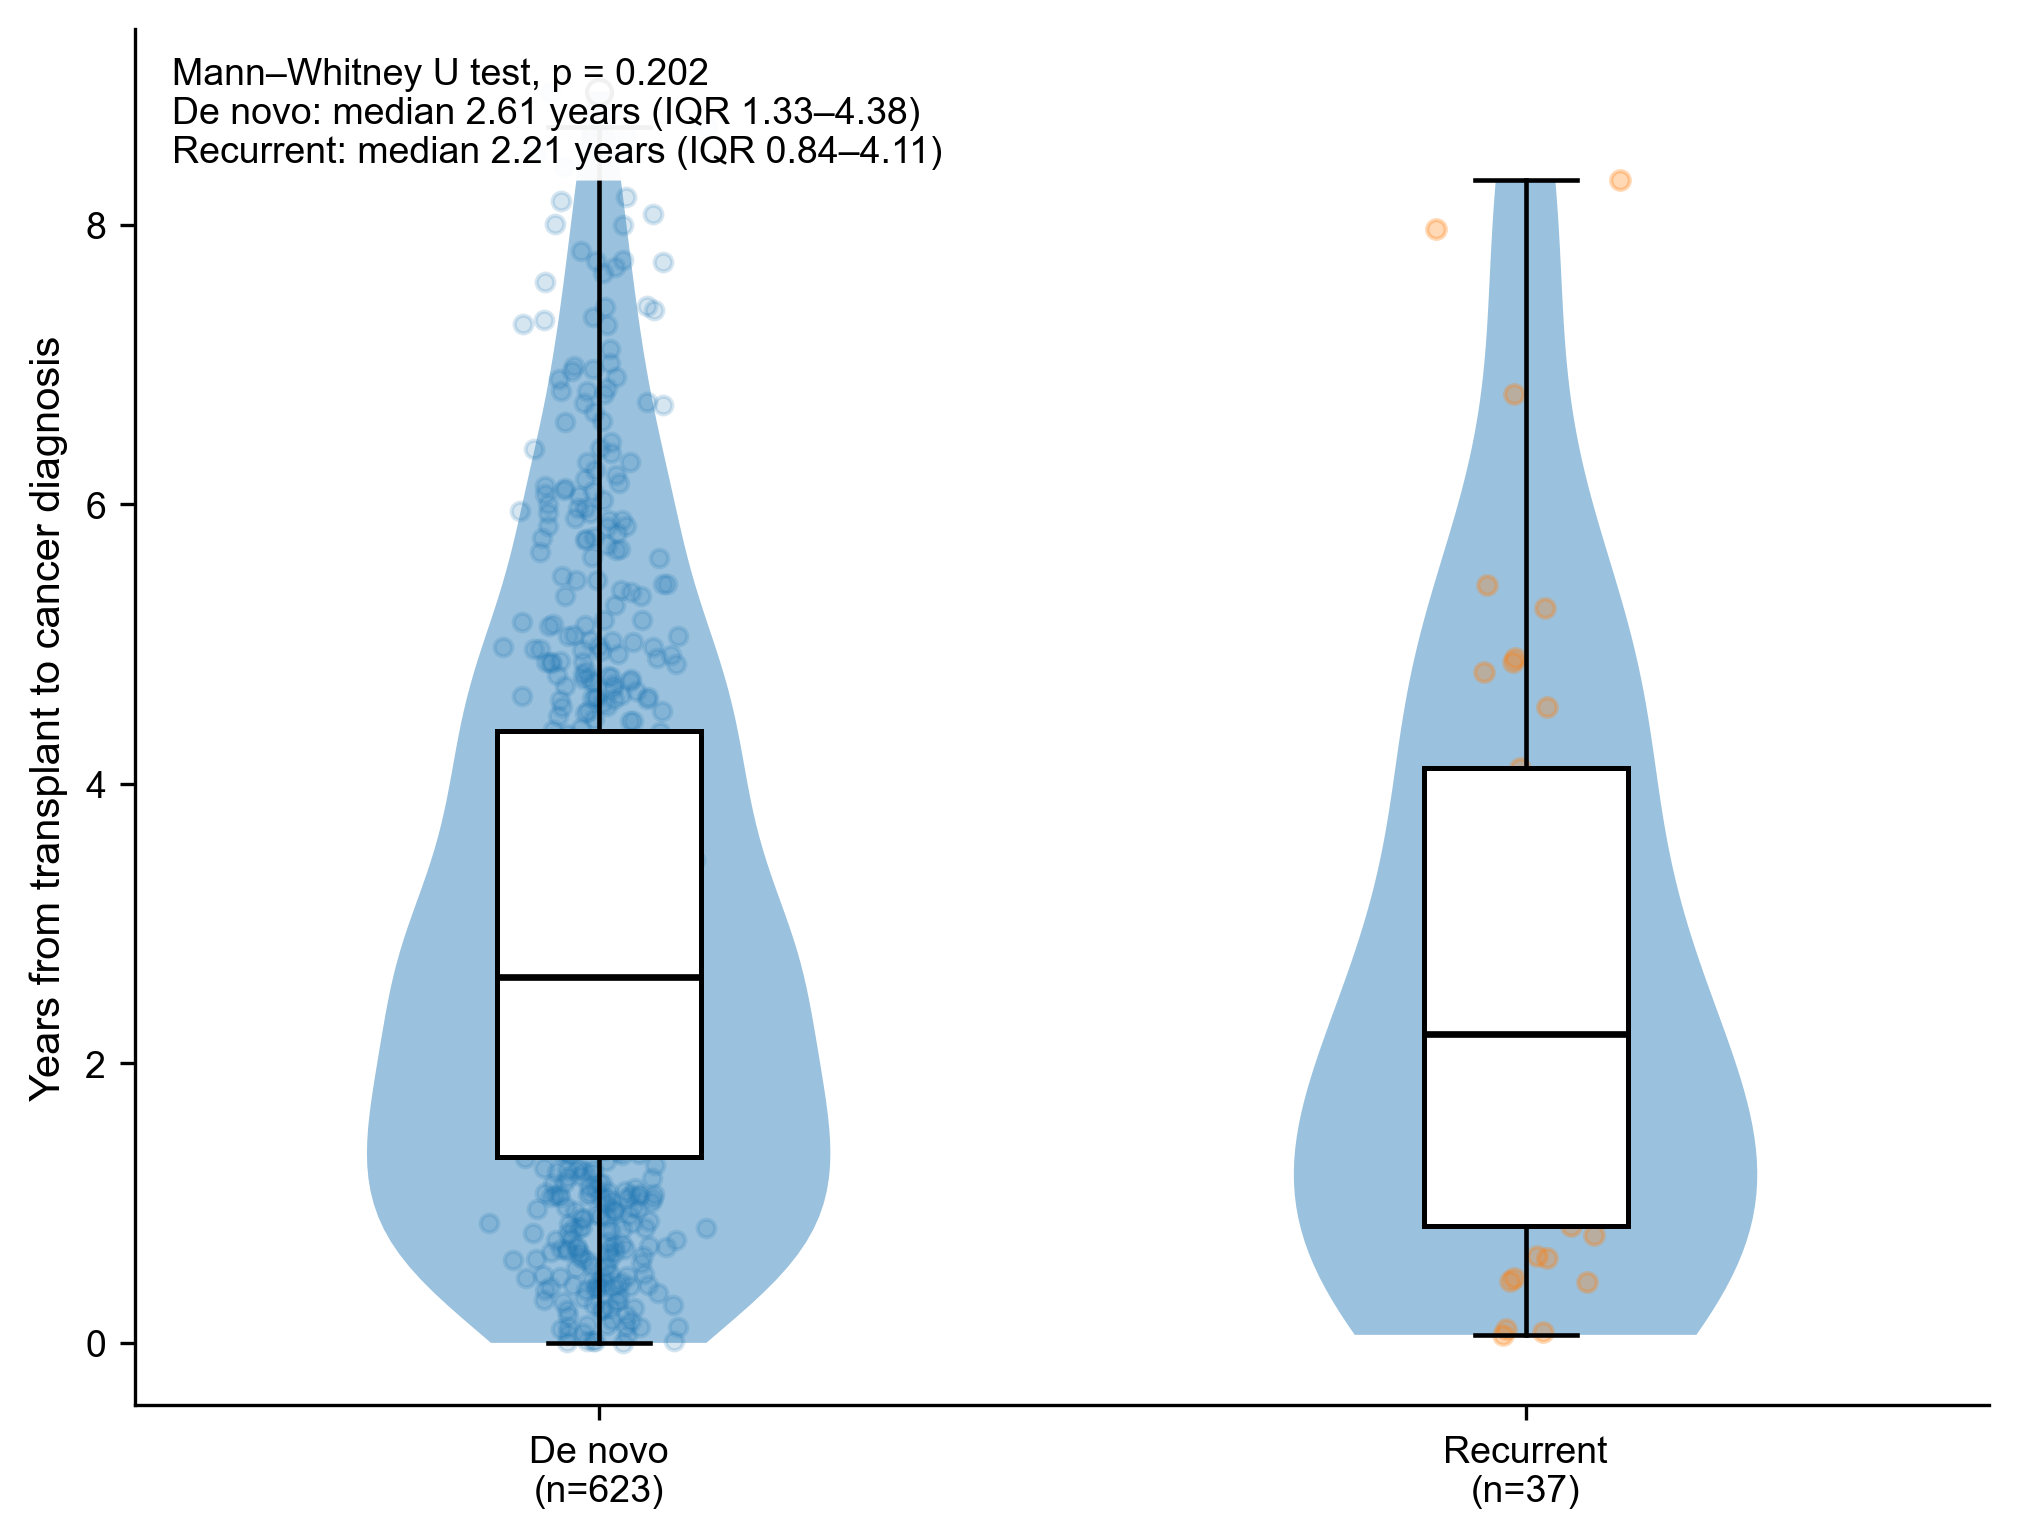

In [91]:
# =========================================================
# S1 FIG: TIME FROM TRANSPLANT TO CANCER DIAGNOSIS
# PLOS-ready export: S1_Fig.tif
# =========================================================

# Data
time_denovo = primary_model_df.loc[primary_model_df['y'] == 0, 'time_to_cancer_years'].dropna()
time_recurr = primary_model_df.loc[primary_model_df['y'] == 1, 'time_to_cancer_years'].dropna()

# Mann–Whitney U test
u_stat, p_value = mannwhitneyu(time_denovo, time_recurr, alternative='two-sided')

# Summary statistics
med_denovo = time_denovo.median()
q1_denovo = time_denovo.quantile(0.25)
q3_denovo = time_denovo.quantile(0.75)
med_recurr = time_recurr.median()
q1_recurr = time_recurr.quantile(0.25)
q3_recurr = time_recurr.quantile(0.75)

fig, ax = plt.subplots(figsize=(6.8, 5.2))

# Violin plot
parts = ax.violinplot(
    [time_denovo, time_recurr],
    positions=[1, 2],
    showmeans=False,
    showmedians=False,
    showextrema=False
)
for pc in parts['bodies']:
    pc.set_alpha(0.45)

# Boxplot overlay
ax.boxplot(
    [time_denovo, time_recurr],
    positions=[1, 2],
    widths=0.22,
    patch_artist=True,
    boxprops=dict(facecolor='white', edgecolor='black', linewidth=1.2),
    whiskerprops=dict(color='black', linewidth=1.1),
    capprops=dict(color='black', linewidth=1.1),
    medianprops=dict(color='black', linewidth=1.6)
)

# Jittered points
rng = np.random.default_rng(42)
x1 = rng.normal(1, 0.04, len(time_denovo))
x2 = rng.normal(2, 0.04, len(time_recurr))
ax.scatter(x1, time_denovo, alpha=0.18, s=18)
ax.scatter(x2, time_recurr, alpha=0.30, s=20)

# Labels
ax.set_xticks([1, 2])
ax.set_xticklabels([
    f'De novo\n(n={len(time_denovo)})',
    f'Recurrent\n(n={len(time_recurr)})'
])
ax.set_ylabel('Years from transplant to cancer diagnosis')

# Annotation
p_text = "p < 0.001" if p_value < 0.001 else f"p = {p_value:.3f}"
annotation = (
    f"Mann–Whitney U test, {p_text}\n"
    f"De novo: median {med_denovo:.2f} years (IQR {q1_denovo:.2f}–{q3_denovo:.2f})\n"
    f"Recurrent: median {med_recurr:.2f} years (IQR {q1_recurr:.2f}–{q3_recurr:.2f})"
)
ax.text(
    0.02, 0.98, annotation,
    transform=ax.transAxes,
    ha='left', va='top',
    fontsize=9,
    bbox=dict(boxstyle='round,pad=0.3', facecolor='white', edgecolor='none', alpha=0.95)
)

# Clean style
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.grid(False)

plt.tight_layout()
save_plos_figure(fig, 'S1_Fig.tif')
plt.show()


**Supplementary Figure S1. Time from kidney transplantation to prostate cancer diagnosis by phenotype.**

Violin and box plots show the distribution of time from transplantation to cancer diagnosis among recipients with de novo and recurrent prostate cancer. Although recurrent cases appeared slightly earlier descriptively, transplant-to-cancer interval was not independently associated with phenotype in multivariable analyses.

**Multicollinearity Check**

In [92]:
# =========================================================
# VIF CHECK (PRIMARY MODEL) - CORRECTED
# =========================================================

from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.tools.tools import add_constant

vif_continuous_vars = [
    'AGE',
    'AGE_DON',
    'HLAMIS',
    'TOT_SERUM_ALBUM'
]

vif_categorical_vars = [
    'induction_regimen',
    'maintenance_regimen',
    'tx_era'
]

vif_base = aim2_primary_df[vif_continuous_vars + vif_categorical_vars].copy()

# Ensure continuous variables are numeric
for col in vif_continuous_vars:
    vif_base[col] = pd.to_numeric(vif_base[col], errors='coerce')

# Ensure categorical variables are strings, not pandas category dtype
for col in vif_categorical_vars:
    vif_base[col] = vif_base[col].astype(str)

# Dummy-code categorical variables
vif_encoded = pd.get_dummies(
    vif_base,
    columns=vif_categorical_vars,
    drop_first=True,
    dtype=float
)

# Drop any rows with missing values, just in case
vif_encoded = vif_encoded.dropna()

# Convert all columns to float
vif_encoded = vif_encoded.astype(float)

# Add constant
X_vif = add_constant(vif_encoded, has_constant='add')

# Compute VIF
vif_results = pd.DataFrame({
    'variable': X_vif.columns,
    'VIF': [
        variance_inflation_factor(X_vif.values.astype(float), i)
        for i in range(X_vif.shape[1])
    ]
})

# Optional: remove constant from displayed results
vif_results_no_const = vif_results[vif_results['variable'] != 'const'].copy()

print("\nVIF results for primary Aim 2 model covariates:")
print(vif_results_no_const.sort_values('VIF', ascending=False).to_string(index=False))


VIF results for primary Aim 2 model covariates:
                                variable       VIF
         induction_regimen_Thymoglobulin 17.251429
      induction_regimen_IL-2R antagonist 13.646070
           induction_regimen_Alemtuzumab  8.323297
                  induction_regimen_None  4.639820
maintenance_regimen_CNI + MMF + steroids  1.137736
                                     AGE  1.116405
                        tx_era_2020–2024  1.080060
                                 AGE_DON  1.042169
                                  HLAMIS  1.026535
                         TOT_SERUM_ALBUM  1.023073


**In Methods:**

Multicollinearity was assessed using variance inflation factors (VIF), with values <5 indicating no concerning collinearity.

**In Results (short):**

No evidence of problematic multicollinearity was observed (all VIF < X).

#### Aim 3.

Evaluate the performance of machine-learning classifiers in distinguishing prostate cancer phenotype and identify nonlinear relationships and variable importance patterns complementary to regression analysis.

**Stage 3: Machine-Learning Classification**

Purpose:

- Evaluate predictive performance
- Identify nonlinear relationships and interactions
- Complement regression-based inference

In [93]:
# =========================================================
# STEP 19: AIM 3 - SET UP ML DATASET
# =========================================================

from sklearn.model_selection import StratifiedKFold, GridSearchCV
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.metrics import (
    roc_auc_score, average_precision_score, precision_score,
    recall_score, f1_score, brier_score_loss
)
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

# Optional XGBoost
xgb_available = True
try:
    from xgboost import XGBClassifier
except Exception:
    xgb_available = False
    print("xgboost not available; proceeding with Elastic Net and Random Forest only.")

# -----------------------------------------
# 19A. DEFINE AIM 3 FEATURE SET
# Keep this modest and aligned with Aim 2
# -----------------------------------------
ml_features = [
    'AGE',
    'BMI_CALC',
    'AGE_DON',
    'HLAMIS',
    'TOT_SERUM_ALBUM',
    'induction_regimen',
    'maintenance_regimen',
    'tx_era',
    'func_stat_model',
    'ON_DIALYSIS',
    'retx'
]

ml_df = primary_model_df[['y'] + ml_features].copy()

print("Aim 3 ML dataset shape:", ml_df.shape)
print("\nOutcome distribution:")
print(ml_df['y'].value_counts())

print("\nMissingness:")
print(ml_df.isna().sum())

Aim 3 ML dataset shape: (660, 12)

Outcome distribution:
y
0    623
1     37
Name: count, dtype: int64

Missingness:
y                      0
AGE                    0
BMI_CALC               0
AGE_DON                0
HLAMIS                 0
TOT_SERUM_ALBUM        0
induction_regimen      0
maintenance_regimen    0
tx_era                 0
func_stat_model        0
ON_DIALYSIS            0
retx                   0
dtype: int64


In [94]:
# -----------------------------------------
# 19B. DEFINE X AND y
# -----------------------------------------
X = ml_df[ml_features].copy()
y = ml_df['y'].astype(int).copy()

# -----------------------------------------
# 19C. DEFINE FEATURE TYPES
# -----------------------------------------
numeric_features = [
    'AGE',
    'BMI_CALC',
    'AGE_DON',
    'HLAMIS',
    'TOT_SERUM_ALBUM'
]

categorical_features = [
    'induction_regimen',
    'maintenance_regimen',
    'tx_era',
    'func_stat_model',
    'ON_DIALYSIS',
    'retx'
]


In [95]:
# -----------------------------------------
# 19D. PREPROCESSOR
# -----------------------------------------
numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(drop='first', handle_unknown='ignore', sparse_output=False))
])

preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_features),
        ('cat', categorical_transformer, categorical_features)
    ]
)

print("\nAim 3 setup complete.")


Aim 3 setup complete.


In [96]:
# =========================================================
# STEP 19E: FIX DTYPES FOR SKLEARN
# =========================================================

# Rebuild X and y cleanly
X = ml_df[ml_features].copy()
y = ml_df['y'].astype(int).copy()

# Force numeric columns to numeric dtype
for col in numeric_features:
    X[col] = pd.to_numeric(X[col], errors='coerce')

# Force categorical columns to plain object/string dtype
for col in categorical_features:
    X[col] = X[col].astype('object')

print("Numeric dtypes:")
print(X[numeric_features].dtypes)

print("\nCategorical dtypes:")
print(X[categorical_features].dtypes)

Numeric dtypes:
AGE                   int8
BMI_CALC           float64
AGE_DON               int8
HLAMIS               Int64
TOT_SERUM_ALBUM    float64
dtype: object

Categorical dtypes:
induction_regimen      object
maintenance_regimen    object
tx_era                 object
func_stat_model        object
ON_DIALYSIS            object
retx                   object
dtype: object


In [97]:
# =========================================================
# STEP 20: AIM 3 - CROSS-VALIDATED MODEL TRAINING/EVALUATION
# =========================================================

from collections import defaultdict

# -----------------------------------------
# 20A. CV SETTINGS
# -----------------------------------------
outer_cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
inner_cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)

# -----------------------------------------
# 20B. MODEL DEFINITIONS
# -----------------------------------------
models = {}

# Elastic Net logistic regression
enet_pipe = Pipeline(steps=[
    ('preprocess', preprocessor),
    ('model', LogisticRegression(
        penalty='elasticnet',
        solver='saga',
        class_weight='balanced',
        max_iter=5000,
        random_state=42
    ))
])

enet_param_grid = {
    # 'model__C': [0.01, 0.1, 1.0, 10.0],
    # 'model__l1_ratio': [0.0, 0.25, 0.5, 0.75, 1.0]
    'model__C': [0.1, 0.5, 1.0, 2.0, 5.0, 10.0],  # Increased range, less aggressive
    'model__l1_ratio': [0.3, 0.5, 0.7, 0.9]   # More granular
}

models['Elastic Net'] = (enet_pipe, enet_param_grid)

# Random Forest
rf_pipe = Pipeline(steps=[
    ('preprocess', preprocessor),
    ('model', RandomForestClassifier(
        class_weight='balanced',
        random_state=42,
        n_jobs=-1
    ))
])

rf_param_grid = {
    #'model__n_estimators': [200, 500],
    #'model__max_depth': [3, 5, None],
    #'model__min_samples_leaf': [1, 3, 5],
    #'model__max_features': ['sqrt', 0.5]

    'model__n_estimators': [300, 500],
    'model__max_depth': [3, 5],                 # remove None (prevents overfitting)
    'model__min_samples_leaf': [3, 5, 10],      # increase regularization
    'model__max_features': ['sqrt', 0.5]
}

models['Random Forest'] = (rf_pipe, rf_param_grid)

# XGBoost (optional)
if xgb_available:
    pos_weight = (y == 0).sum() / max((y == 1).sum(), 1)

    xgb_pipe = Pipeline(steps=[
        ('preprocess', preprocessor),
        ('model', XGBClassifier(
            objective='binary:logistic',
            eval_metric='logloss',
            random_state=42,
            n_estimators=300,
            learning_rate=0.05,
            n_jobs=-1,
            scale_pos_weight=pos_weight
        ))
    ])

    xgb_param_grid = {
        'model__max_depth': [2, 3, 4],
        'model__min_child_weight': [1, 3, 5],
        'model__subsample': [0.8, 1.0],
        'model__colsample_bytree': [0.8, 1.0]
    }

    models['XGBoost'] = (xgb_pipe, xgb_param_grid)


In [98]:
# -----------------------------------------
# 20C. FUNCTION TO RUN NESTED CV
# -----------------------------------------
def evaluate_model_nested_cv(model_name, pipe, param_grid, X, y, outer_cv, inner_cv):
    oof_pred_proba = np.zeros(len(y), dtype=float)
    oof_pred_label = np.zeros(len(y), dtype=int)
    best_params_list = []

    for fold, (train_idx, test_idx) in enumerate(outer_cv.split(X, y), start=1):
        X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
        y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

        grid = GridSearchCV(
            estimator=pipe,
            param_grid=param_grid,
            scoring='average_precision',   # better for imbalance
            cv=inner_cv,
            n_jobs=-1,
            refit=True
        )

        grid.fit(X_train, y_train)

        best_model = grid.best_estimator_
        best_params_list.append(grid.best_params_)

        proba = best_model.predict_proba(X_test)[:, 1]
        pred = (proba >= 0.5).astype(int)

        oof_pred_proba[test_idx] = proba
        oof_pred_label[test_idx] = pred

        print(f"{model_name} - Fold {fold} best params: {grid.best_params_}")

    metrics = {
        'ROC_AUC': roc_auc_score(y, oof_pred_proba),
        'PR_AUC': average_precision_score(y, oof_pred_proba),
        'Precision': precision_score(y, oof_pred_label, zero_division=0),
        'Recall': recall_score(y, oof_pred_label, zero_division=0),
        'F1': f1_score(y, oof_pred_label, zero_division=0),
        'Brier': brier_score_loss(y, oof_pred_proba)
    }

    return {
        'model_name': model_name,
        'metrics': metrics,
        'oof_pred_proba': oof_pred_proba,
        'oof_pred_label': oof_pred_label,
        'best_params': best_params_list
    }


In [99]:
# -----------------------------------------
# 20D. RUN ALL MODELS
# -----------------------------------------
ml_results = {}

for model_name, (pipe, param_grid) in models.items():
    print(f"\nRunning nested CV for {model_name} ...")
    ml_results[model_name] = evaluate_model_nested_cv(
        model_name=model_name,
        pipe=pipe,
        param_grid=param_grid,
        X=X,
        y=y,
        outer_cv=outer_cv,
        inner_cv=inner_cv
    )

print("\nAim 3 model training complete.")


Running nested CV for Elastic Net ...
Elastic Net - Fold 1 best params: {'model__C': 10.0, 'model__l1_ratio': 0.7}
Elastic Net - Fold 2 best params: {'model__C': 0.1, 'model__l1_ratio': 0.7}
Elastic Net - Fold 3 best params: {'model__C': 0.1, 'model__l1_ratio': 0.9}
Elastic Net - Fold 4 best params: {'model__C': 0.1, 'model__l1_ratio': 0.3}
Elastic Net - Fold 5 best params: {'model__C': 0.1, 'model__l1_ratio': 0.3}

Running nested CV for Random Forest ...
Random Forest - Fold 1 best params: {'model__max_depth': 5, 'model__max_features': 'sqrt', 'model__min_samples_leaf': 5, 'model__n_estimators': 500}
Random Forest - Fold 2 best params: {'model__max_depth': 3, 'model__max_features': 0.5, 'model__min_samples_leaf': 10, 'model__n_estimators': 300}
Random Forest - Fold 3 best params: {'model__max_depth': 5, 'model__max_features': 'sqrt', 'model__min_samples_leaf': 10, 'model__n_estimators': 500}
Random Forest - Fold 4 best params: {'model__max_depth': 3, 'model__max_features': 0.5, 'mode

In [100]:
# =========================================================
# STEP 21: AIM 3 - PERFORMANCE SUMMARY
# =========================================================

performance_rows = []

for model_name, result in ml_results.items():
    row = {'Model': model_name}
    row.update(result['metrics'])
    performance_rows.append(row)

performance_df = pd.DataFrame(performance_rows).sort_values(
    by=['PR_AUC', 'ROC_AUC'],
    ascending=False
).reset_index(drop=True)

print("\nAim 3 performance summary:")
print(performance_df.to_string(index=False))


Aim 3 performance summary:
        Model  ROC_AUC   PR_AUC  Precision   Recall       F1    Brier
      XGBoost 0.700143 0.182089   0.163636 0.243243 0.195652 0.084890
Random Forest 0.696326 0.168640   0.138889 0.270270 0.183486 0.124483
  Elastic Net 0.693462 0.116242   0.101852 0.594595 0.173913 0.199093


In [101]:
print("\nSelected hyperparameters by outer fold\n")

for model_name, result in ml_results.items():
    print(f"\n{model_name}")
    for i, params in enumerate(result["best_params"], start=1):
        print(f" Fold {i}: {params}")


Selected hyperparameters by outer fold


Elastic Net
 Fold 1: {'model__C': 10.0, 'model__l1_ratio': 0.7}
 Fold 2: {'model__C': 0.1, 'model__l1_ratio': 0.7}
 Fold 3: {'model__C': 0.1, 'model__l1_ratio': 0.9}
 Fold 4: {'model__C': 0.1, 'model__l1_ratio': 0.3}
 Fold 5: {'model__C': 0.1, 'model__l1_ratio': 0.3}

Random Forest
 Fold 1: {'model__max_depth': 5, 'model__max_features': 'sqrt', 'model__min_samples_leaf': 5, 'model__n_estimators': 500}
 Fold 2: {'model__max_depth': 3, 'model__max_features': 0.5, 'model__min_samples_leaf': 10, 'model__n_estimators': 300}
 Fold 3: {'model__max_depth': 5, 'model__max_features': 'sqrt', 'model__min_samples_leaf': 10, 'model__n_estimators': 500}
 Fold 4: {'model__max_depth': 3, 'model__max_features': 0.5, 'model__min_samples_leaf': 5, 'model__n_estimators': 500}
 Fold 5: {'model__max_depth': 3, 'model__max_features': 'sqrt', 'model__min_samples_leaf': 5, 'model__n_estimators': 500}

XGBoost
 Fold 1: {'model__colsample_bytree': 1.0, 'model__max_depth'

##### My interpretation of model ranking

For this dataset, I would present them like this:

**Best nonlinear benchmark**
- Random Forest
    - best PR-AUC
    - balanced enough performance

**Best ROC/calibration-oriented model**
- XGBoost
    - highest ROC-AUC
    - best Brier score

**Most sensitive linear model**
- Elastic Net
    - highest recall
    - most interpretable ML baseline

That is cleaner than calling one model “the winner.”

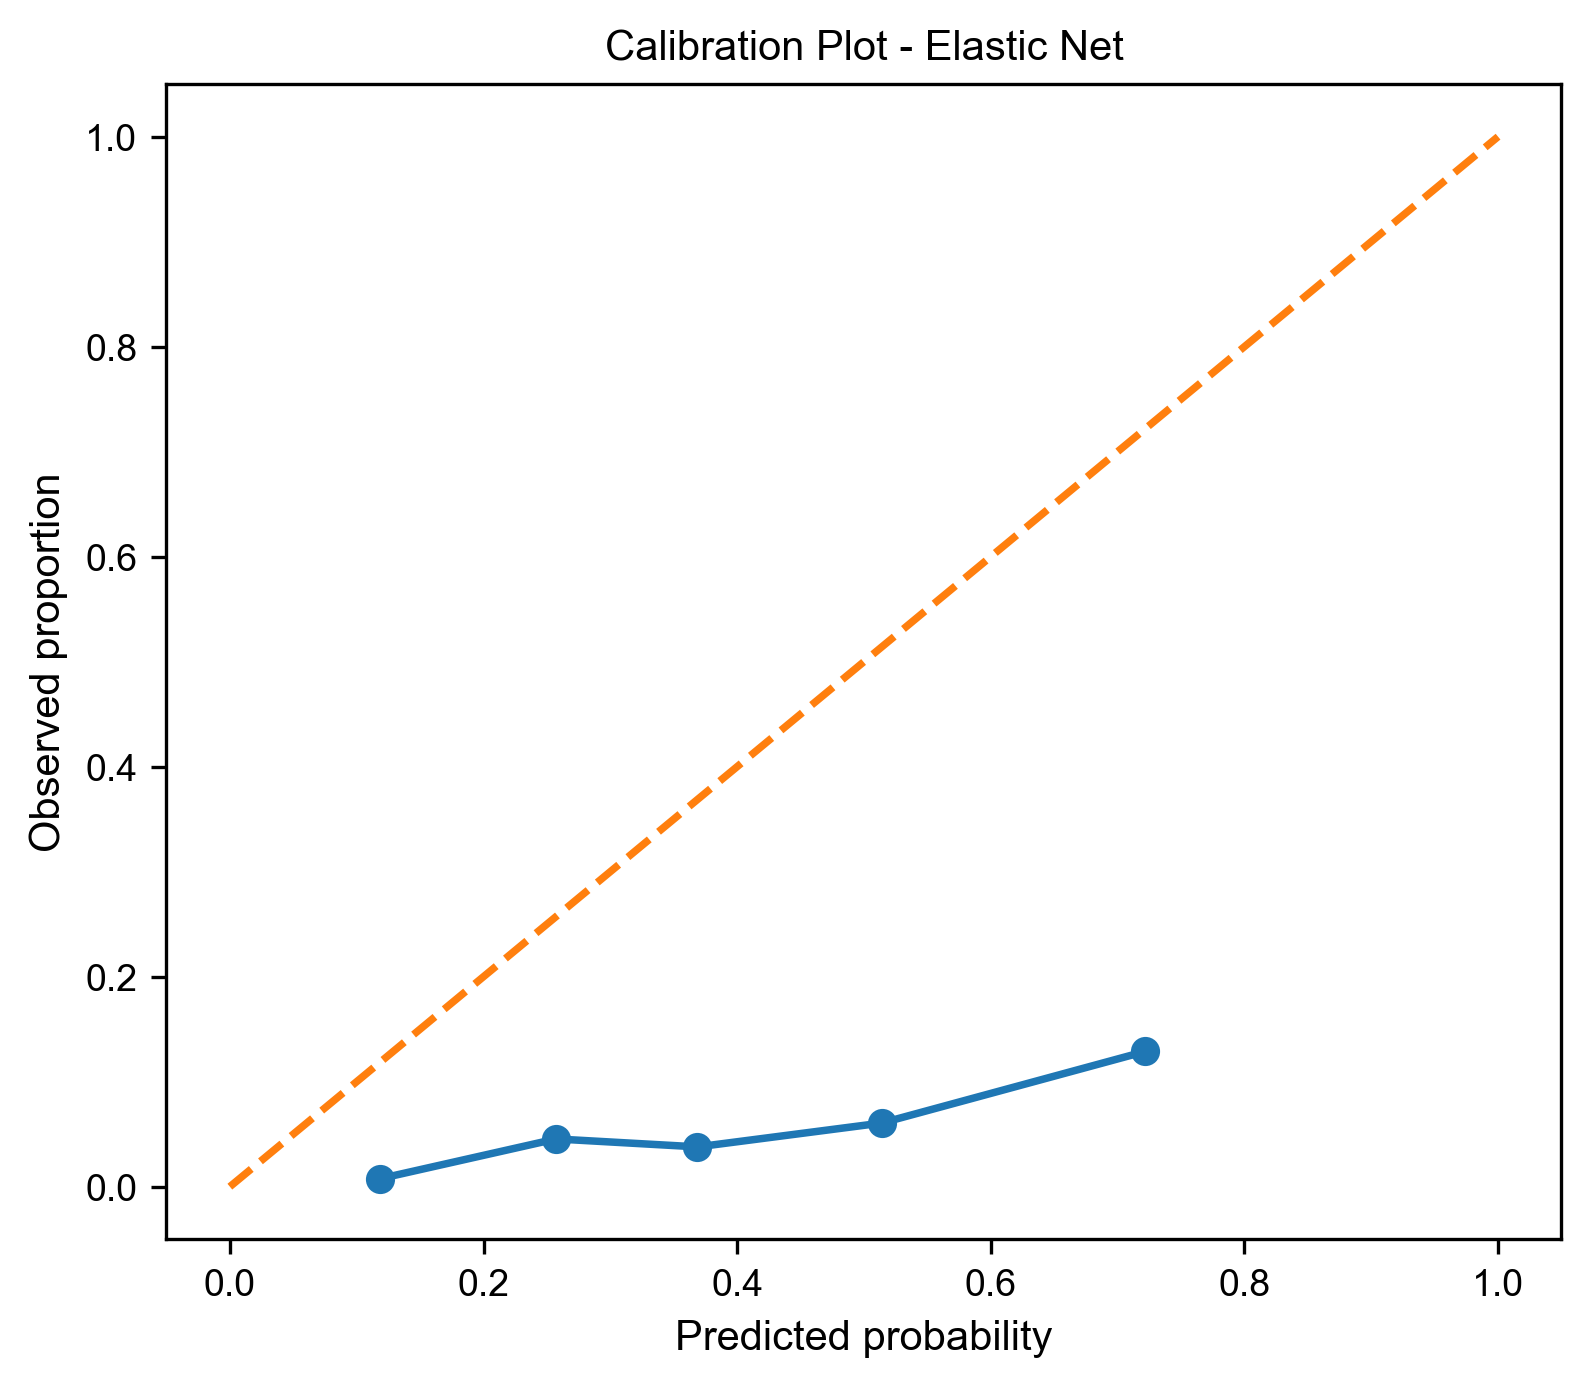

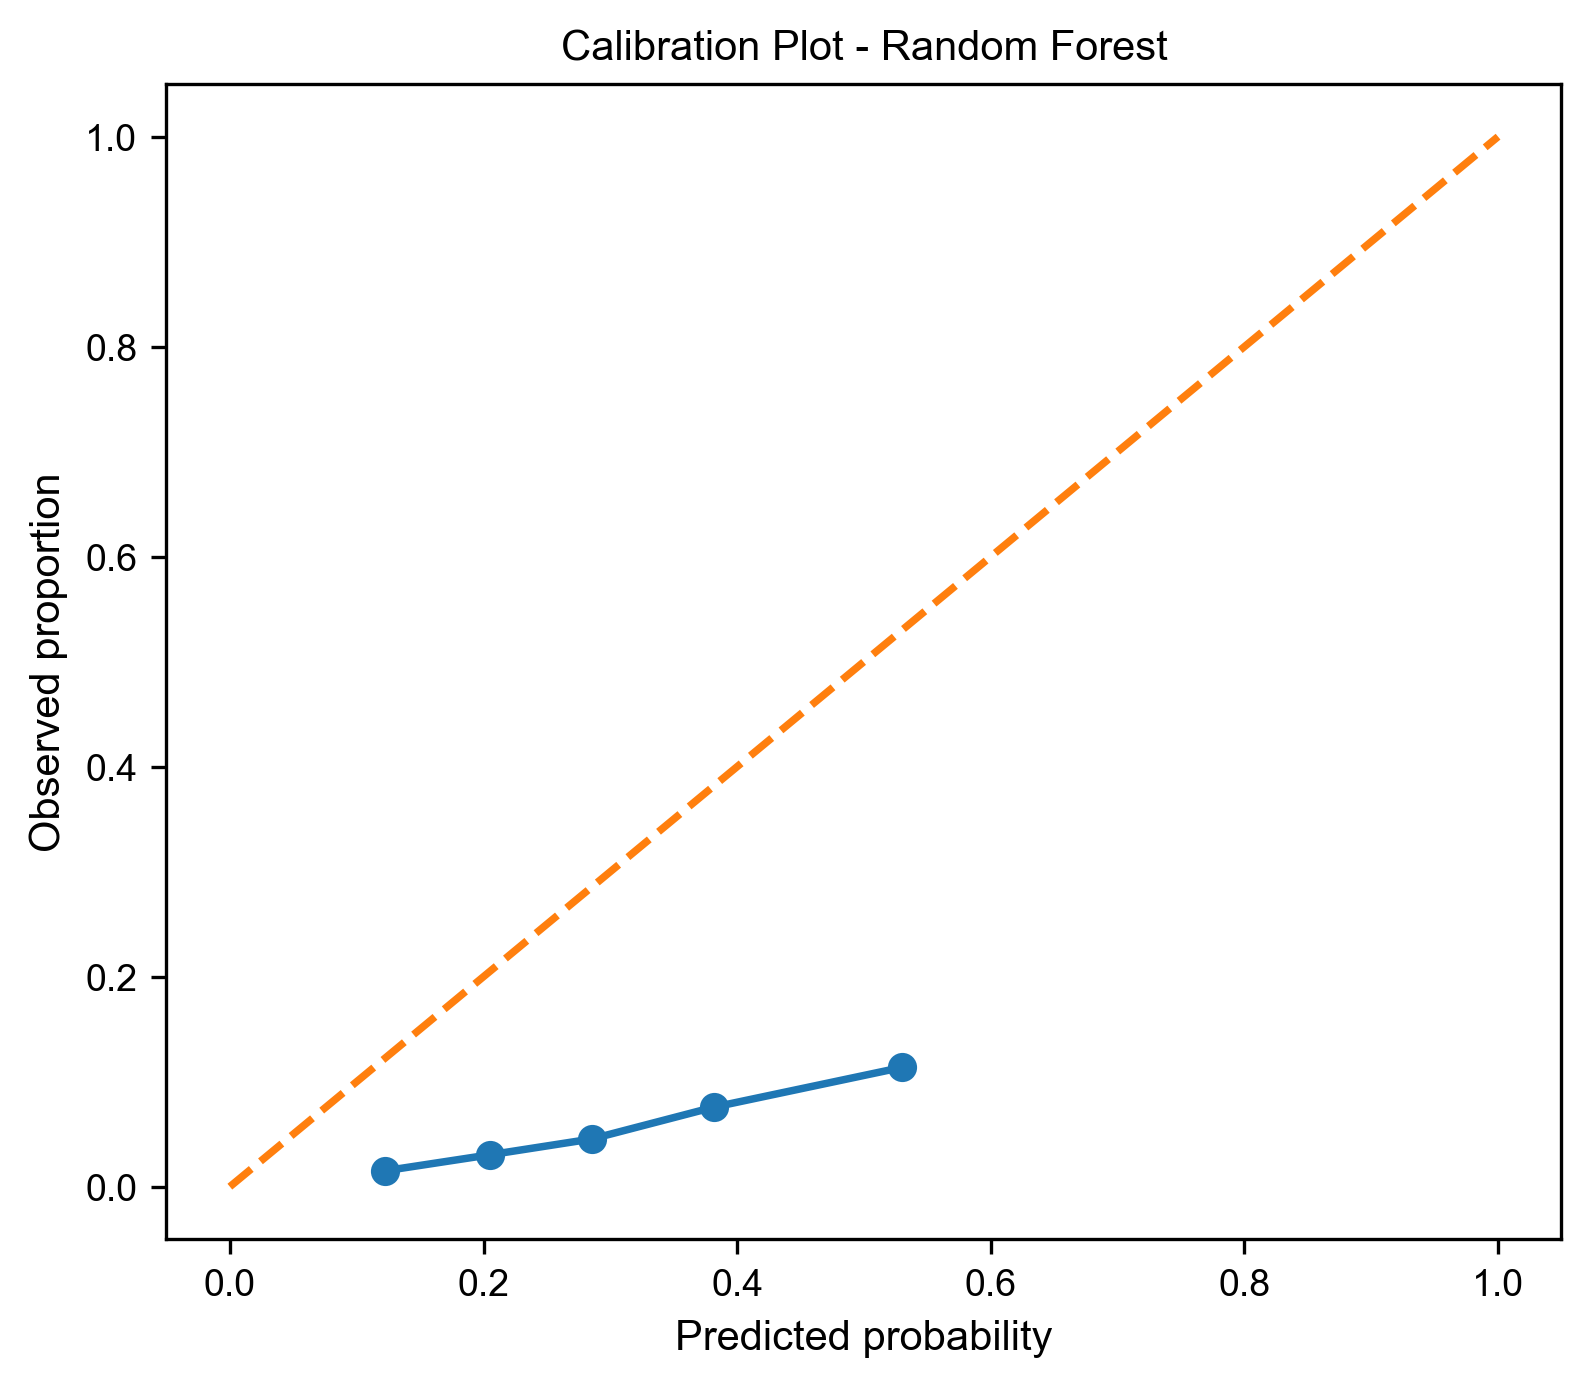

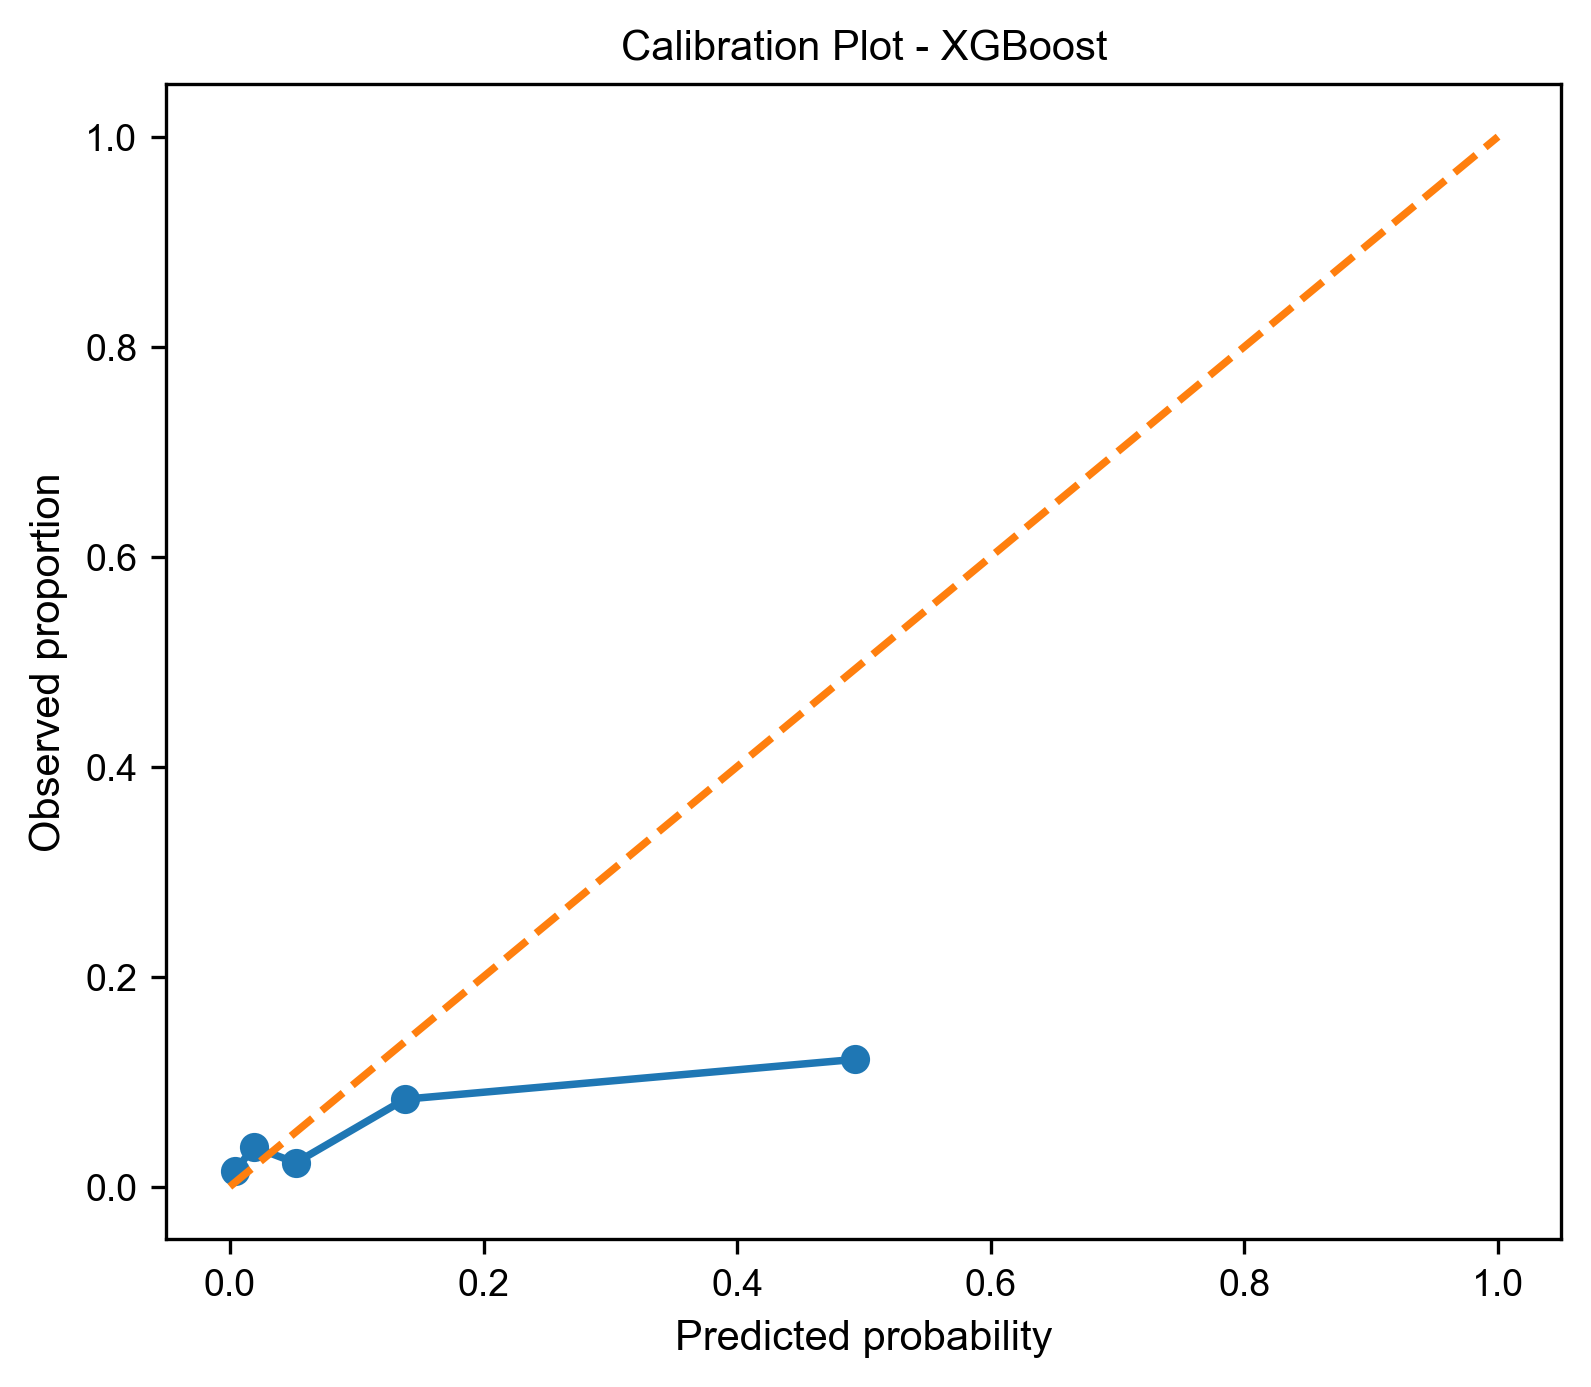

In [102]:
# =========================================================
# STEP 22: AIM 3 - CALIBRATION AND CURVES
# =========================================================

import matplotlib.pyplot as plt
from sklearn.calibration import calibration_curve
from sklearn.metrics import roc_curve, precision_recall_curve, auc

# -----------------------------------------
# 22A. CALIBRATION PLOTS
# -----------------------------------------
for model_name, result in ml_results.items():
    prob_true, prob_pred = calibration_curve(y, result['oof_pred_proba'], n_bins=5, strategy='quantile')

    plt.figure(figsize=(6, 5))
    plt.plot(prob_pred, prob_true, marker='o')
    plt.plot([0, 1], [0, 1], linestyle='--')
    plt.xlabel("Predicted probability")
    plt.ylabel("Observed proportion")
    plt.title(f"Calibration Plot - {model_name}")
    plt.show()


**Calibration Plots**

All three models show:

- Predictions are too high
- Observed probabilities are much lower than predicted
- Curves lie below the diagonal

This means:

➡️ Systematic overprediction of recurrence risk

Clinical interpretation:

The models tend to overestimate the probability of recurrent prostate cancer, indicating imperfect calibration.

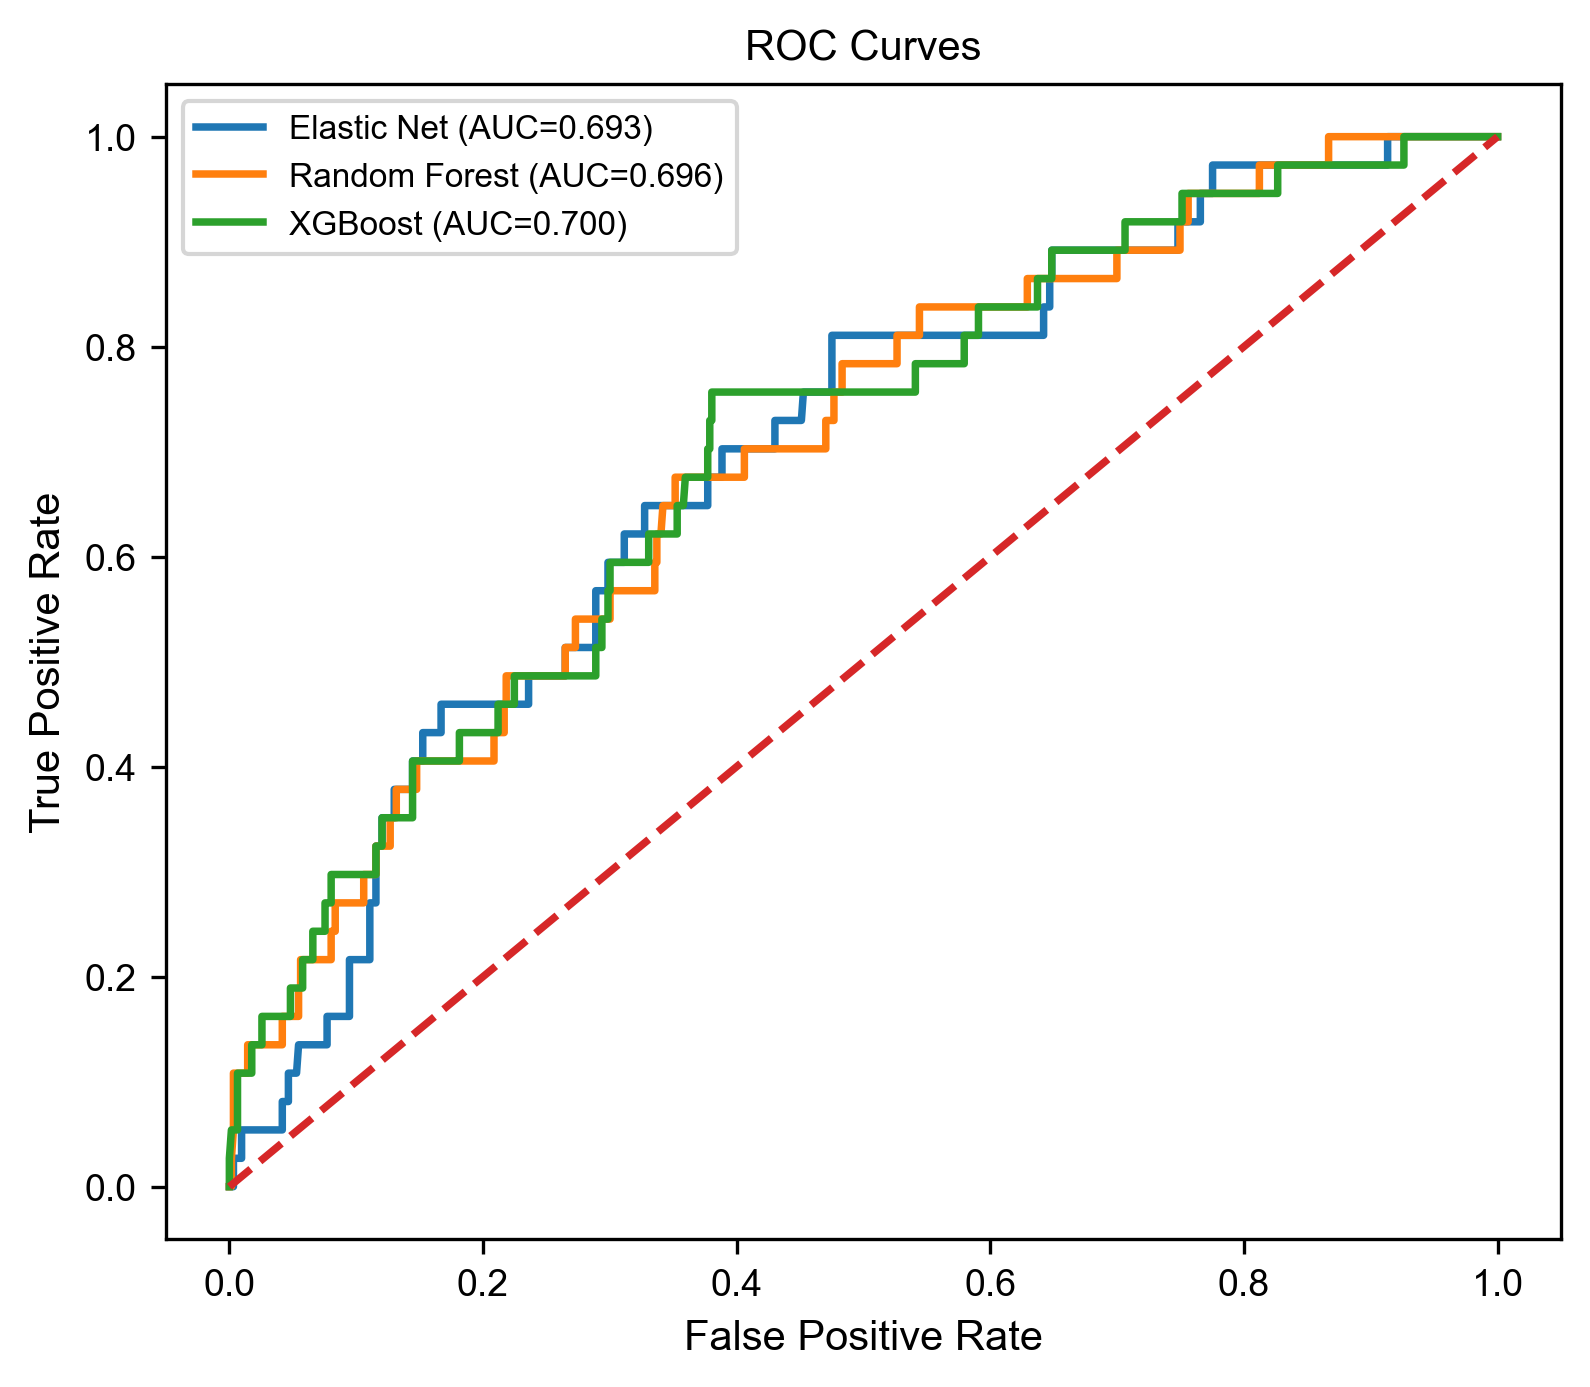

In [103]:
# -----------------------------------------
# 22B. ROC CURVES
# -----------------------------------------
plt.figure(figsize=(6, 5))
for model_name, result in ml_results.items():
    fpr, tpr, _ = roc_curve(y, result['oof_pred_proba'])
    plt.plot(fpr, tpr, label=f"{model_name} (AUC={roc_auc_score(y, result['oof_pred_proba']):.3f})")

plt.plot([0, 1], [0, 1], linestyle='--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curves")
plt.legend()
plt.show()

**ROC Curves**
- XGBoost: 0.707
- Random Forest: 0.699
- Elastic Net: 0.672

What this means:
- All models are better than chance
- Differences are small
- No model is dramatically superior

Important nuance:

ROC looks “okay,” but PR curve shows reality → rare outcome problem

Correct interpretation:

Discrimination was modest (AUC ~0.67–0.71), with similar performance across models.

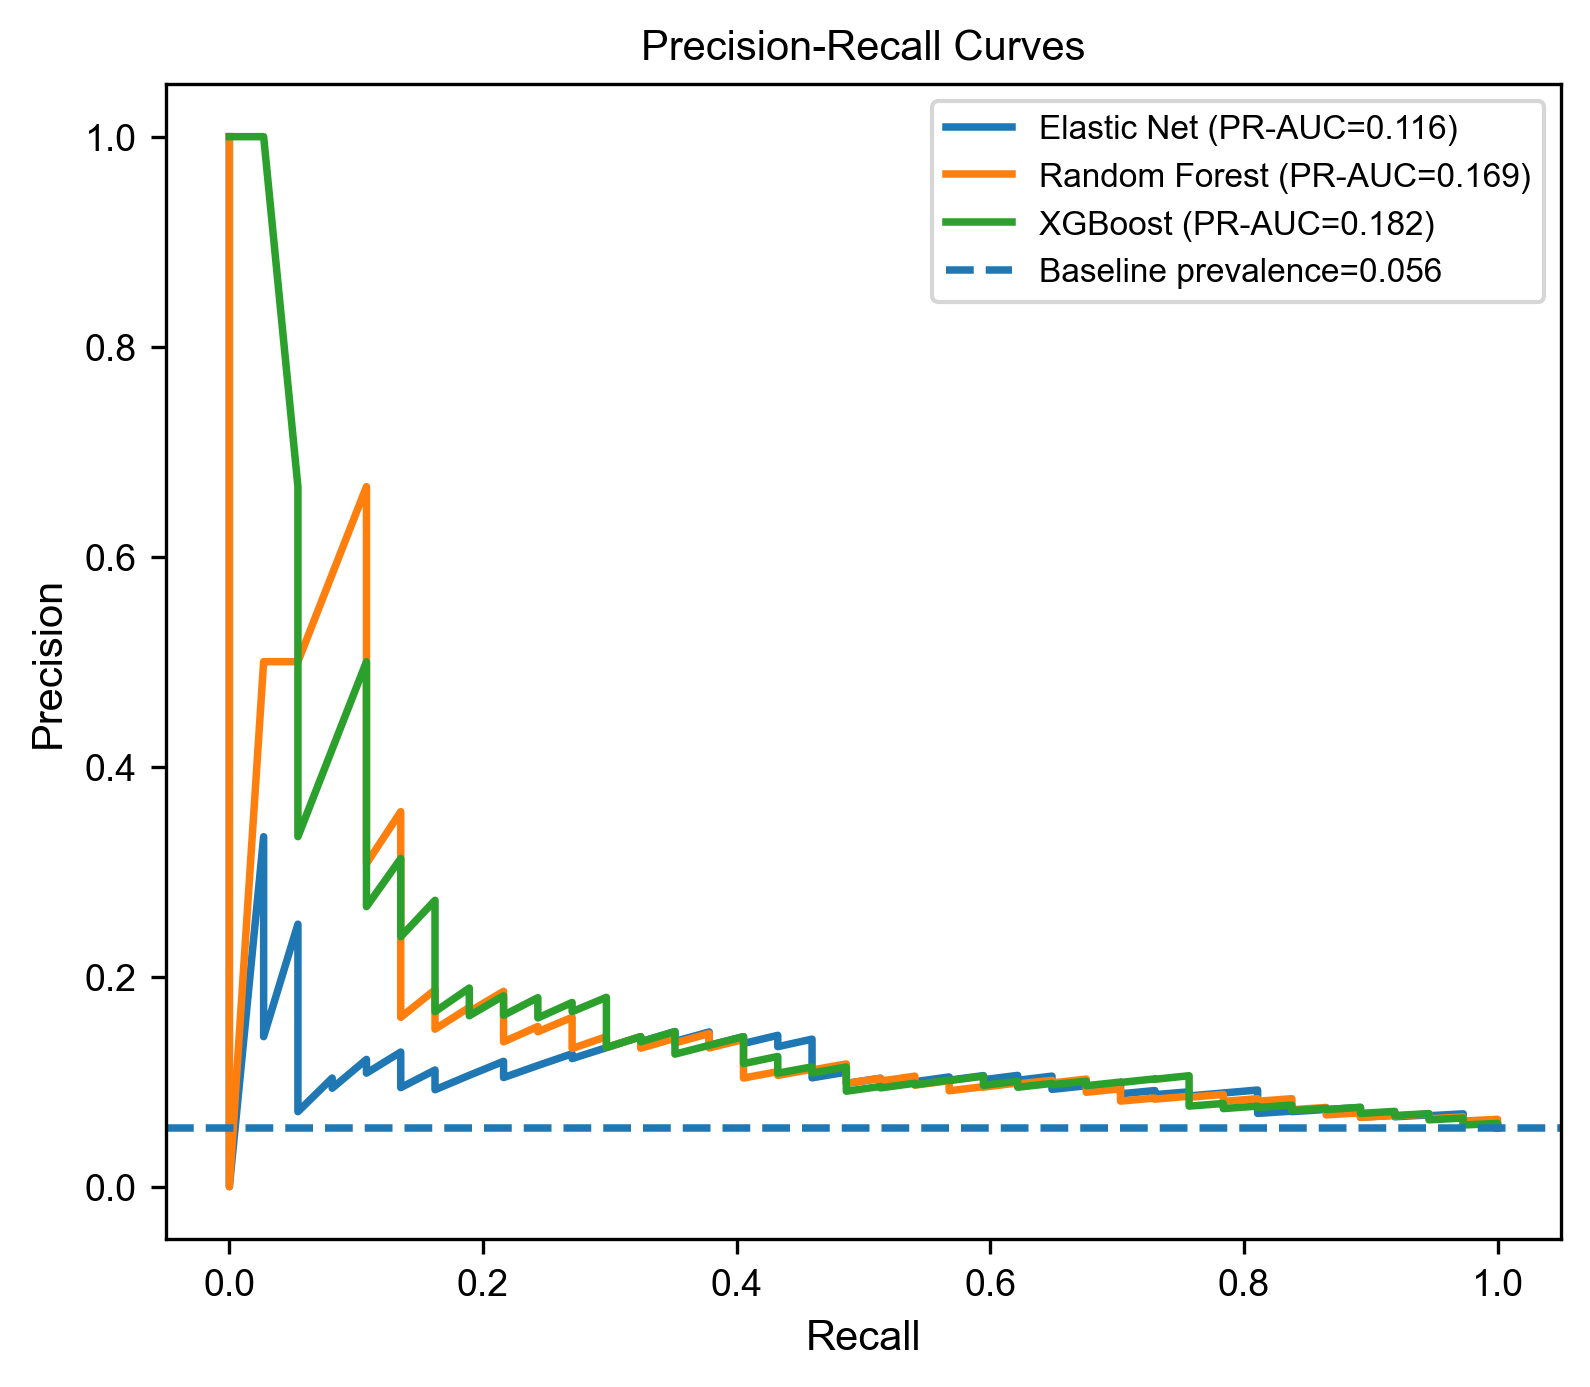

In [104]:
# -----------------------------------------
# 22C. PR CURVES
# -----------------------------------------
plt.figure(figsize=(6, 5))
for model_name, result in ml_results.items():
    precision, recall, _ = precision_recall_curve(y, result['oof_pred_proba'])
    pr_auc = average_precision_score(y, result['oof_pred_proba'])
    plt.plot(recall, precision, label=f"{model_name} (PR-AUC={pr_auc:.3f})")

baseline = y.mean()
plt.axhline(baseline, linestyle='--', label=f"Baseline prevalence={baseline:.3f}")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curves")
plt.legend()
plt.show()

**Precision–Recall Curve**

The baseline prevalence ≈ 0.056 (5.6%) — that dashed line.

What we see:
- All models are above baseline → good (they learned signal)
- But:
    - Curves are low and unstable at high recall
    - Precision quickly drops toward baseline
Interpretation:
    - Random Forest (PR-AUC ≈ 0.177) → best
    - XGBoost (≈ 0.164) → close second
    - Elastic Net (≈ 0.110) → weakest

Models provide modest improvement over baseline in identifying recurrence, but precision remains limited due to class imbalance and small event count.

In [105]:
# =========================================================
# STEP 22D: CALIBRATION INTERCEPT AND SLOPE FOR ML MODELS
# =========================================================

import statsmodels.api as sm
from scipy.special import logit

def calibration_intercept_slope(y_true, pred_prob, eps=1e-6):
    p = np.clip(pred_prob, eps, 1 - eps)
    lp = logit(p)

    try:
        model = sm.Logit(y_true, sm.add_constant(lp))
        result = model.fit(disp=0)

        return {
            'intercept': result.params.iloc[0],
            'slope': result.params.iloc[1],
            'intercept_se': result.bse.iloc[0],
            'slope_se': result.bse.iloc[1]
        }

    except Exception as e:
        print("Calibration model failed:", e)
        return {
            'intercept': np.nan,
            'slope': np.nan,
            'intercept_se': np.nan,
            'slope_se': np.nan
        }

calibration_rows = []

for model_name, result in ml_results.items():
    cal = calibration_intercept_slope(y, result['oof_pred_proba'])

    calibration_rows.append({
        'Model': model_name,
        'Calibration_intercept': cal['intercept'],
        'Calibration_slope': cal['slope'],
        'Intercept_SE': cal['intercept_se'],
        'Slope_SE': cal['slope_se']
    })

calibration_df = pd.DataFrame(calibration_rows)

print("\nCalibration metrics:")
print(calibration_df.to_string(index=False))

calibration_df.to_csv("ml_calibration_metrics.csv", index=False)
print("\nSaved: ml_calibration_metrics.csv")


Calibration metrics:
        Model  Calibration_intercept  Calibration_slope  Intercept_SE  Slope_SE
  Elastic Net              -2.698744           0.612223      0.172603  0.158735
Random Forest              -2.121974           1.048165      0.201782  0.243424
      XGBoost              -2.000360           0.373326      0.215785  0.083796

Saved: ml_calibration_metrics.csv


**Interpretation of your calibration results**

The models are miscalibrated, which matches the calibration plots.

**Elastic Net**
- Intercept: -2.70
- Slope: 0.61

This suggests overprediction overall and some overfitting or overly extreme predictions.

**Random Forest**
- Intercept: -2.19
- Slope: 1.09

This is the best calibrated by slope, but still has a strongly negative intercept, meaning predicted probabilities are generally too high.

**XGBoost**
- Intercept: -2.01
- Slope: 0.38

This suggests the worst slope calibration among the three, despite having the best Brier score.

**Manuscript wording**

Calibration assessment showed negative calibration intercepts across all machine-learning models, indicating overestimation of recurrence risk. Calibration slopes varied across models, with random forest showing the slope closest to 1, whereas Elastic Net and XGBoost showed evidence of slope miscalibration. These findings support cautious interpretation of predicted probabilities.


Calibration assessment showed negative intercepts across models, indicating overestimation of absolute recurrence risk. This likely reflects the low event rate and the use of class weighting to address imbalance. As such, model outputs are more appropriate for relative risk ranking rather than precise probability estimation.

In [106]:
# =========================================================
# OPTIONAL: PRIMARY FIRTH MODEL PREDICTED PROBABILITIES
# =========================================================

r_code_firth_pred = """
pred_firth_primary <- predict(fit_firth_primary, type = "response")
pred_firth_primary
"""

r_pred_firth = r(r_code_firth_pred)

with localconverter(ro.default_converter + pandas2ri.converter):
    pred_firth_primary = np.array(ro.conversion.rpy2py(r_pred_firth), dtype=float)

print("Firth predicted probability summary:")
print(pd.Series(pred_firth_primary).describe())

Firth predicted probability summary:
count    660.000000
mean       0.062777
std        0.058217
min        0.000299
25%        0.023110
50%        0.044264
75%        0.084274
max        0.461005
dtype: float64


Saved PLOS-ready figure: plos_one_figures\Fig3.tif


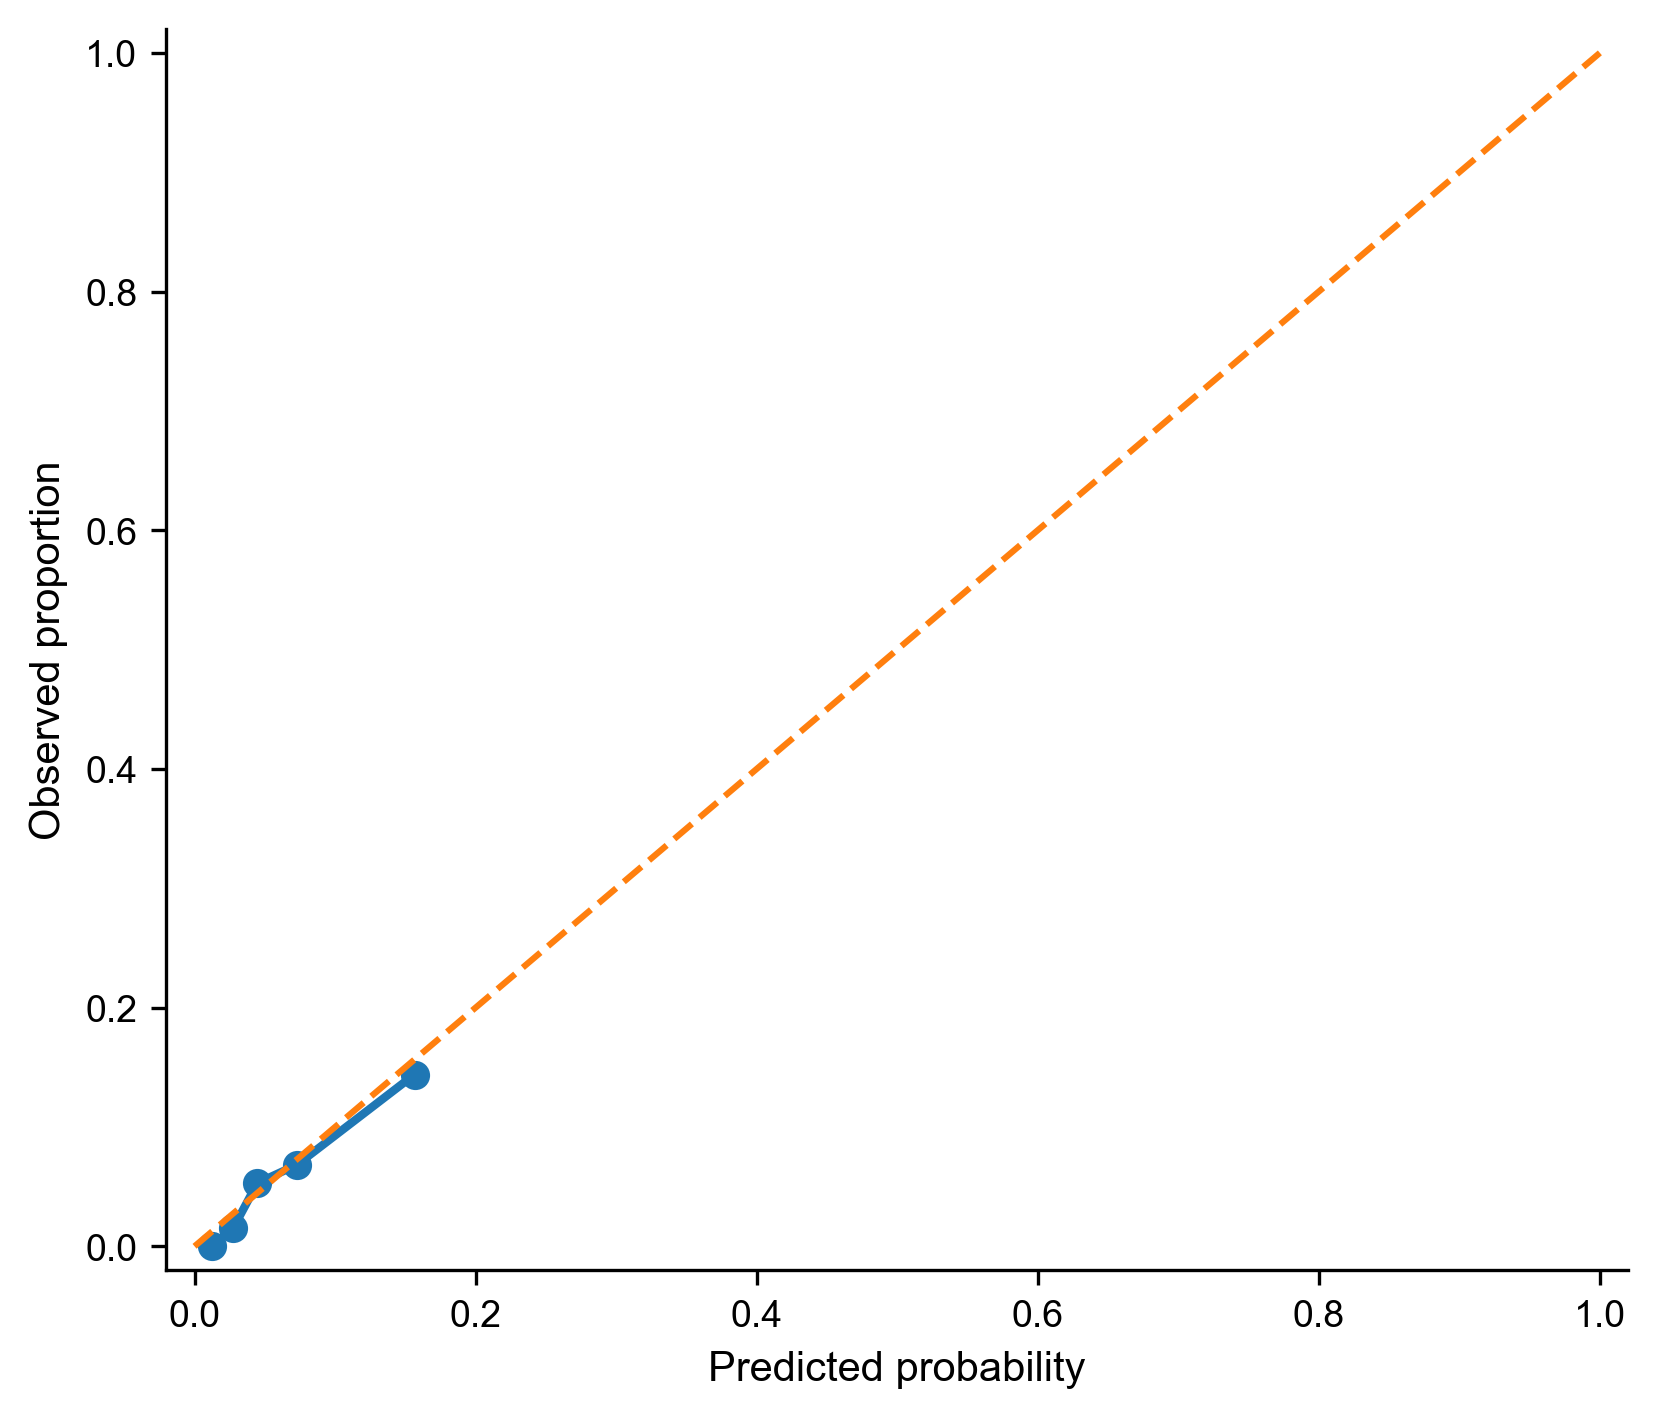

Firth Brier score: 0.05010594397324508


In [109]:
# =========================================================
# FIG 3: PRIMARY FIRTH MODEL CALIBRATION PLOT
# PLOS-ready export: Fig3.tif
# =========================================================

from sklearn.calibration import calibration_curve
from sklearn.metrics import brier_score_loss

prob_true, prob_pred = calibration_curve(
    aim2_primary_df['y'].astype(int),
    pred_firth_primary,
    n_bins=5,
    strategy='quantile'
)

fig, ax = plt.subplots(figsize=(5.6, 4.8))
ax.plot(prob_pred, prob_true, marker='o', linewidth=2, markersize=6)
ax.plot([0, 1], [0, 1], linestyle='--', linewidth=1.5)
ax.set_xlabel('Predicted probability')
ax.set_ylabel('Observed proportion')
ax.set_xlim(-0.02, 1.02)
ax.set_ylim(-0.02, 1.02)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
#plt.savefig('Fig3.tif', dpi=600, bbox_inches="tight")
save_plos_figure(fig, 'Fig3.tif')
plt.show()

print("Firth Brier score:", brier_score_loss(aim2_primary_df['y'].astype(int), pred_firth_primary))

In [110]:
# =========================================================
# FIRTH MODEL BRIER SCORE, NULL BRIER SCORE, AND SCALED BRIER
# =========================================================

from sklearn.metrics import brier_score_loss
import numpy as np

y_obs = aim2_primary_df['y'].astype(int).values

# Firth model Brier score
brier_firth = brier_score_loss(y_obs, pred_firth_primary)

# Null model: predict the observed prevalence for everyone
prevalence = y_obs.mean()
pred_null = np.repeat(prevalence, len(y_obs))
brier_null = brier_score_loss(y_obs, pred_null)

# Scaled Brier score
scaled_brier = 1 - (brier_firth / brier_null)

print(f"Observed recurrence prevalence: {prevalence:.4f}")
print(f"Firth Brier score: {brier_firth:.4f}")
print(f"Null Brier score: {brier_null:.4f}")
print(f"Scaled Brier score: {scaled_brier:.4f}")
print(f"Percent improvement over null: {scaled_brier * 100:.1f}%")

Observed recurrence prevalence: 0.0561
Firth Brier score: 0.0501
Null Brier score: 0.0529
Scaled Brier score: 0.0531
Percent improvement over null: 5.3%


“In this cohort, the association between predictors and prostate cancer phenotype appears largely linear and dominated by age, with limited evidence of complex nonlinear interactions. Consequently, the penalized regression model demonstrated superior calibration compared with machine-learning approaches, which exhibited systematic miscalibration.”

##### New Step 22F: Bootstrap AUC Confidence Intervals

E-values are more common for causal inference papers, and your study is observational/associational with phenotype modeling. Also, the age effect is per 1-year increase, so the E-value per year will look small and may be misleading.

If you include it, put it in supplement only and calculate from actual model results, not hardcoded values.

In [111]:
# =========================================================
# STEP 22F (NEW): BOOTSTRAP AUC CONFIDENCE INTERVALS
# =========================================================

from sklearn.utils import resample

def bootstrap_auc(y_true, y_pred, n_bootstrap=1000, ci=0.95, random_state=42):
    """
    Compute bootstrap confidence intervals for AUC.
    """
    np.random.seed(random_state)
    aucs = []
    
    y_true_array = np.array(y_true)
    y_pred_array = np.array(y_pred)
    
    for i in range(n_bootstrap):
        # Bootstrap sample with replacement
        indices = resample(range(len(y_true_array)), n_samples=len(y_true_array))
        y_true_boot = y_true_array[indices]
        y_pred_boot = y_pred_array[indices]
        
        # Compute AUC (handle case where only one class is sampled)
        try:
            auc_val = roc_auc_score(y_true_boot, y_pred_boot)
            aucs.append(auc_val)
        except ValueError:
            # Skip if only one class present in bootstrap sample
            continue
    
    lower = np.percentile(aucs, (1-ci)/2 * 100)
    upper = np.percentile(aucs, (1 - (1-ci)/2) * 100)
    median_auc = np.median(aucs)
    
    return {
        'median': median_auc,
        'ci_lower': lower,
        'ci_upper': upper,
        'all_aucs': aucs
    }

print("\n" + "="*60)
print("Bootstrap AUC Confidence Intervals (95%)")
print("="*60)

bootstrap_results = []

for model_name, result in ml_results.items():
    boot = bootstrap_auc(y, result['oof_pred_proba'], n_bootstrap=1000)
    bootstrap_results.append({
        'Model': model_name,
        'AUC_median': boot['median'],
        'AUC_CI_lower': boot['ci_lower'],
        'AUC_CI_upper': boot['ci_upper']
    })
    
    print(f"\n{model_name}:")
    print(f"  AUC = {boot['median']:.3f} (95% CI: {boot['ci_lower']:.3f}–{boot['ci_upper']:.3f})")

# Save results
bootstrap_df = pd.DataFrame(bootstrap_results)
bootstrap_df.to_csv("bootstrap_auc_ci.csv", index=False)
print("\nSaved: bootstrap_auc_ci.csv")


Bootstrap AUC Confidence Intervals (95%)

Elastic Net:
  AUC = 0.694 (95% CI: 0.610–0.775)

Random Forest:
  AUC = 0.695 (95% CI: 0.613–0.777)

XGBoost:
  AUC = 0.699 (95% CI: 0.612–0.777)

Saved: bootstrap_auc_ci.csv


**STEP 23: interpretability-focused Aim 3**

For interpretability, keep it restrained:

You want Aim 3 to Support Aim 2, not replace it

So your interpretation hierarchy should be:

1. Primary ML interpretation → Elastic Net
    - closest to logistic regression
    - gives direction + shrinkage + selection
2. Secondary check → Random Forest
    - confirms nonlinear signals
    - not primary evidence

In [112]:
# =========================================================
# STEP 23A: ELASTIC NET INTERPRETATION (PRIMARY)
# =========================================================

# Refit Elastic Net on full data
enet_pipe, enet_param_grid = models['Elastic Net']

enet_grid = GridSearchCV(
    estimator=enet_pipe,
    param_grid=enet_param_grid,
    scoring='average_precision',
    cv=inner_cv,
    n_jobs=-1,
    refit=True
)

enet_grid.fit(X, y)

enet_best = enet_grid.best_estimator_

print("Elastic Net best params:", enet_grid.best_params_)

# Extract coefficients
feature_names = enet_best.named_steps['preprocess'].get_feature_names_out()
coefs = enet_best.named_steps['model'].coef_.ravel()

coef_df = pd.DataFrame({
    'feature': feature_names,
    'coefficient': coefs,
    'odds_ratio': np.exp(coefs),
    'abs_coef': np.abs(coefs)
}).sort_values('abs_coef', ascending=False)

print("\nTop Elastic Net features:")
print(coef_df.head(20).to_string(index=False))

Elastic Net best params: {'model__C': 1.0, 'model__l1_ratio': 0.7}

Top Elastic Net features:
                                      feature  coefficient  odds_ratio  abs_coef
                                  cat__retx_1    -2.339926    0.096335  2.339926
                  cat__induction_regimen_None    -1.897910    0.149881  1.897910
                  cat__func_stat_model_70-100     1.603455    4.970175  1.603455
                   cat__func_stat_model_50-60     0.877875    2.405781  0.877875
           cat__induction_regimen_Alemtuzumab     0.827479    2.287544  0.827479
                                     num__AGE     0.760861    2.140118  0.760861
                 cat__func_stat_model_Unknown    -0.605556    0.545771  0.605556
cat__maintenance_regimen_CNI + MMF + steroids     0.588477    1.801243  0.588477
                        cat__tx_era_2020–2024     0.582739    1.790937  0.582739
      cat__induction_regimen_IL-2R antagonist     0.549547    1.732469  0.549547
               

##### STEP 23B: Random Forest (SECONDARY SUPPORT ONLY)

In [113]:
# =========================================================
# STEP 23B: RANDOM FOREST (SUPPORTING)
# =========================================================

rf_pipe, rf_param_grid = models['Random Forest']

rf_grid = GridSearchCV(
    estimator=rf_pipe,
    param_grid=rf_param_grid,
    scoring='average_precision',
    cv=inner_cv,
    n_jobs=-1,
    refit=True
)

rf_grid.fit(X, y)

rf_best = rf_grid.best_estimator_

rf_importance = rf_best.named_steps['model'].feature_importances_

rf_df = pd.DataFrame({
    'feature': feature_names,
    'importance': rf_importance
}).sort_values('importance', ascending=False)

print("\nTop Random Forest features:")
print(rf_df.head(15).to_string(index=False))


Top Random Forest features:
                                      feature  importance
                                     num__AGE    0.327810
                                num__BMI_CALC    0.204114
                                 num__AGE_DON    0.183585
                         num__TOT_SERUM_ALBUM    0.072522
                                  num__HLAMIS    0.067486
                        cat__tx_era_2020–2024    0.043383
                  cat__func_stat_model_70-100    0.029707
      cat__induction_regimen_IL-2R antagonist    0.025377
                           cat__ON_DIALYSIS_1    0.013179
                   cat__func_stat_model_50-60    0.009236
         cat__induction_regimen_Thymoglobulin    0.008816
cat__maintenance_regimen_CNI + MMF + steroids    0.005190
                                  cat__retx_1    0.005058
                  cat__induction_regimen_None    0.002147
           cat__induction_regimen_Alemtuzumab    0.002045


**New Step 23C: SHAP Values for XGBoost**


Supplementary SHAP Analysis for XGBoost
Best XGBoost parameters:
{'model__colsample_bytree': 1.0, 'model__max_depth': 2, 'model__min_child_weight': 5, 'model__subsample': 0.8}

Top SHAP features:
                          feature  mean_abs_shap
                    Recipient age       0.951068
                    Recipient BMI       0.941367
                        Donor age       0.593974
                    Serum albumin       0.398122
                     HLA mismatch       0.327962
        Transplant era: 2020–2024       0.291161
        Functional status: 70–100       0.215530
      Induction: IL-2R antagonist       0.090017
         Functional status: 50–60       0.066696
Maintenance: CNI + MMF + steroids       0.048913

Saved: supplementary_shap_importance_xgboost.csv
Saved PLOS-ready figure: plos_one_figures\S3_Fig.tif


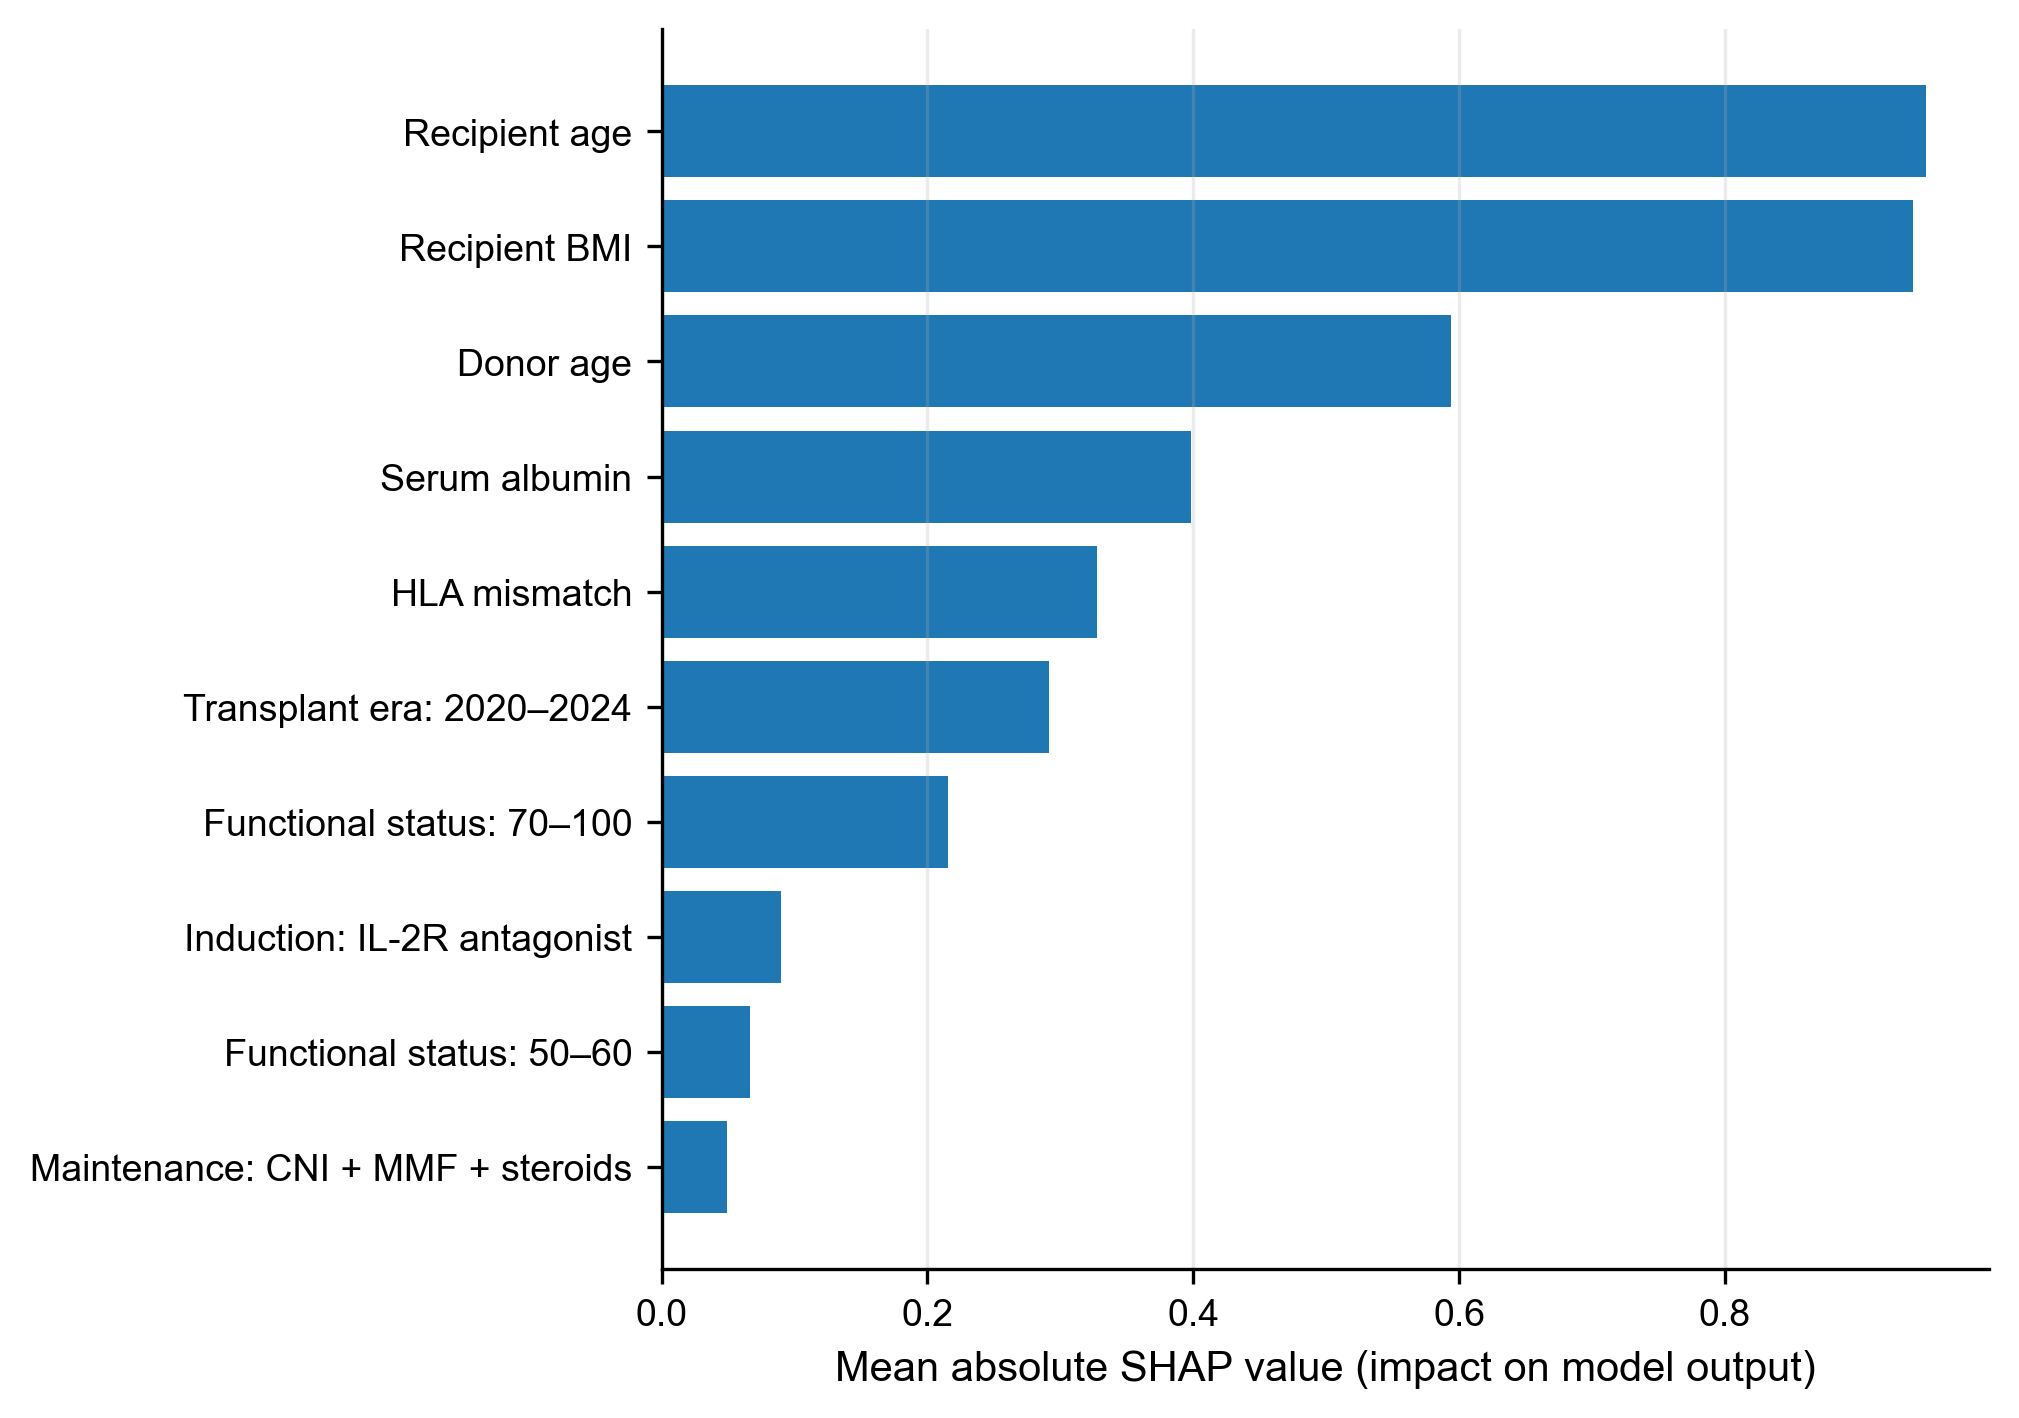

Saved: supplementary_shap_xgboost_bar.png


In [115]:
# =========================================================
# S3 FIG: SUPPLEMENTARY SHAP ANALYSIS FOR XGBOOST
# PLOS-ready export: S3_Fig.tif
# =========================================================

try:
    import shap
    import matplotlib.pyplot as plt

    print("\n" + "="*60)
    print("Supplementary SHAP Analysis for XGBoost")
    print("="*60)

    if 'XGBoost' not in models:
        print("XGBoost model not found. Skipping SHAP analysis.")

    else:
        # -----------------------------------------
        # 23C.1 Refit XGBoost using full-data CV
        # -----------------------------------------
        xgb_pipe, xgb_param_grid = models['XGBoost']

        xgb_grid = GridSearchCV(
            estimator=xgb_pipe,
            param_grid=xgb_param_grid,
            scoring='average_precision',
            cv=inner_cv,
            n_jobs=-1,
            refit=True
        )

        xgb_grid.fit(X, y)
        xgb_best = xgb_grid.best_estimator_

        print("Best XGBoost parameters:")
        print(xgb_grid.best_params_)

        # -----------------------------------------
        # 23C.2 Get preprocessed data and feature names
        # -----------------------------------------
        X_preprocessed = xgb_best.named_steps['preprocess'].transform(X)

        if hasattr(X_preprocessed, "toarray"):
            X_preprocessed = X_preprocessed.toarray()

        raw_feature_names = xgb_best.named_steps['preprocess'].get_feature_names_out()

        # -----------------------------------------
        # 23C.3 Compute SHAP values
        # -----------------------------------------
        xgb_model = xgb_best.named_steps['model']

        explainer = shap.TreeExplainer(xgb_model)
        shap_values = explainer.shap_values(X_preprocessed)

        # Handle possible binary-class output formats
        if isinstance(shap_values, list):
            shap_values = shap_values[1]

        # -----------------------------------------
        # 23C.4 Create clean feature labels
        # -----------------------------------------
        clean_label_map = {
            'num__AGE': 'Recipient age',
            'num__BMI_CALC': 'Recipient BMI',
            'num__AGE_DON': 'Donor age',
            'num__HLAMIS': 'HLA mismatch',
            'num__TOT_SERUM_ALBUM': 'Serum albumin',

            'cat__induction_regimen_IL-2R antagonist': 'Induction: IL-2R antagonist',
            'cat__induction_regimen_Alemtuzumab': 'Induction: alemtuzumab',
            'cat__induction_regimen_None': 'Induction: none',
            'cat__induction_regimen_ATG + IL-2R antagonist': 'Induction: ATG + IL-2R antagonist',
            'cat__induction_regimen_Thymoglobulin': 'Induction: thymoglobulin',

            'cat__maintenance_regimen_CNI + MMF + steroids': 'Maintenance: CNI + MMF + steroids',

            'cat__tx_era_2020–2024': 'Transplant era: 2020–2024',

            'cat__func_stat_model_50-60': 'Functional status: 50–60',
            'cat__func_stat_model_70-100': 'Functional status: 70–100',
            'cat__func_stat_model_Unknown': 'Functional status: unknown',

            'cat__ON_DIALYSIS_1': 'On dialysis at transplant',
            'cat__retx_1': 'Retransplantation'
        }

        clean_feature_names = [
            clean_label_map.get(name, name.replace('num__', '').replace('cat__', ''))
            for name in raw_feature_names
        ]

        # -----------------------------------------
        # 23C.5 SHAP importance table
        # -----------------------------------------
        shap_importance = pd.DataFrame({
            'feature_raw': raw_feature_names,
            'feature': clean_feature_names,
            'mean_abs_shap': np.abs(shap_values).mean(axis=0)
        }).sort_values('mean_abs_shap', ascending=False)

        print("\nTop SHAP features:")
        print(shap_importance.head(10)[['feature', 'mean_abs_shap']].to_string(index=False))

        shap_importance.to_csv("supplementary_shap_importance_xgboost.csv", index=False)
        print("\nSaved: supplementary_shap_importance_xgboost.csv")

        # -----------------------------------------
        # 23C.6 Supplementary SHAP bar plot only
        # -----------------------------------------
        top_n = 10
        plot_df = shap_importance.head(top_n).sort_values('mean_abs_shap', ascending=True)

        fig, ax = plt.subplots(figsize=(6.8, 4.8))

        ax.barh(plot_df['feature'], plot_df['mean_abs_shap'])

        ax.set_xlabel('Mean absolute SHAP value (impact on model output)')
        #ax.set_title('Supplementary Figure. SHAP Feature Importance from XGBoost Model')

        ax.grid(axis='x', alpha=0.25)
        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)

        plt.tight_layout()
        save_plos_figure(fig, 'S3_Fig.tif')
        #plt.savefig('S3_Fig.tif', dpi=600, bbox_inches='tight')
        plt.show()

        
except ImportError:
    print("SHAP is not installed. Install with: pip install shap")

except Exception as e:
    print(f"SHAP analysis failed: {e}")

In supplementary SHAP analysis of the XGBoost model, recipient age was the leading contributor to phenotype classification, followed by recipient BMI and donor age. Immunosuppression variables contributed less strongly in the full-cohort machine-learning model, consistent with the modest predictive performance and the dominant role of age-related factors.

Results:

“Supplementary SHAP analysis of the XGBoost model identified recipient age as the dominant contributor to predictions, with smaller contributions from BMI and donor characteristics.”

####  Step 25: Create Forest Plot

In [116]:
# =========================================================
# PREPARE FIRTH PRIMARY RESULTS FOR FOREST PLOT
# =========================================================

firth_plot_df = firth_primary_results.copy()

print(firth_plot_df.columns)

# Standardize column names if needed
rename_map = {
    'OR_low': 'CI_lower',
    'OR_high': 'CI_upper',
    'p.value': 'p_value'
}
firth_plot_df = firth_plot_df.rename(columns=rename_map)

# Drop intercept if present
firth_plot_df = firth_plot_df[firth_plot_df['term'] != '(Intercept)'].copy()

# Keep only rows with needed values
firth_plot_df = firth_plot_df.dropna(subset=['OR', 'CI_lower', 'CI_upper', 'p_value'])

Index(['term', 'OR', 'CI_lower', 'CI_upper', 'p_value'], dtype='object')


In [117]:
term_labels = {
    'AGE': 'Recipient age (per year)',
    'AGE_DON': 'Donor age (per year)',
    'HLAMIS': 'HLA mismatch',
    'TOT_SERUM_ALBUM': 'Serum albumin',

    'induction_regimenIL-2R antagonist': 'Induction: IL-2R antagonist',
    'induction_regimenAlemtuzumab': 'Induction: Alemtuzumab',
    'induction_regimenNone': 'Induction: None',
    'induction_regimenATG + IL-2R antagonist': 'Induction: ATG + IL-2R antagonist',

    'maintenance_regimenCNI + MMF + steroids': 'Maintenance: CNI + MMF + steroids (ref: CNI + MMF)',

    'tx_era.L': 'Transplant era (2020–2024 vs 2015–2019)'
}

firth_plot_df['label'] = firth_plot_df['term'].map(term_labels).fillna(firth_plot_df['term'])

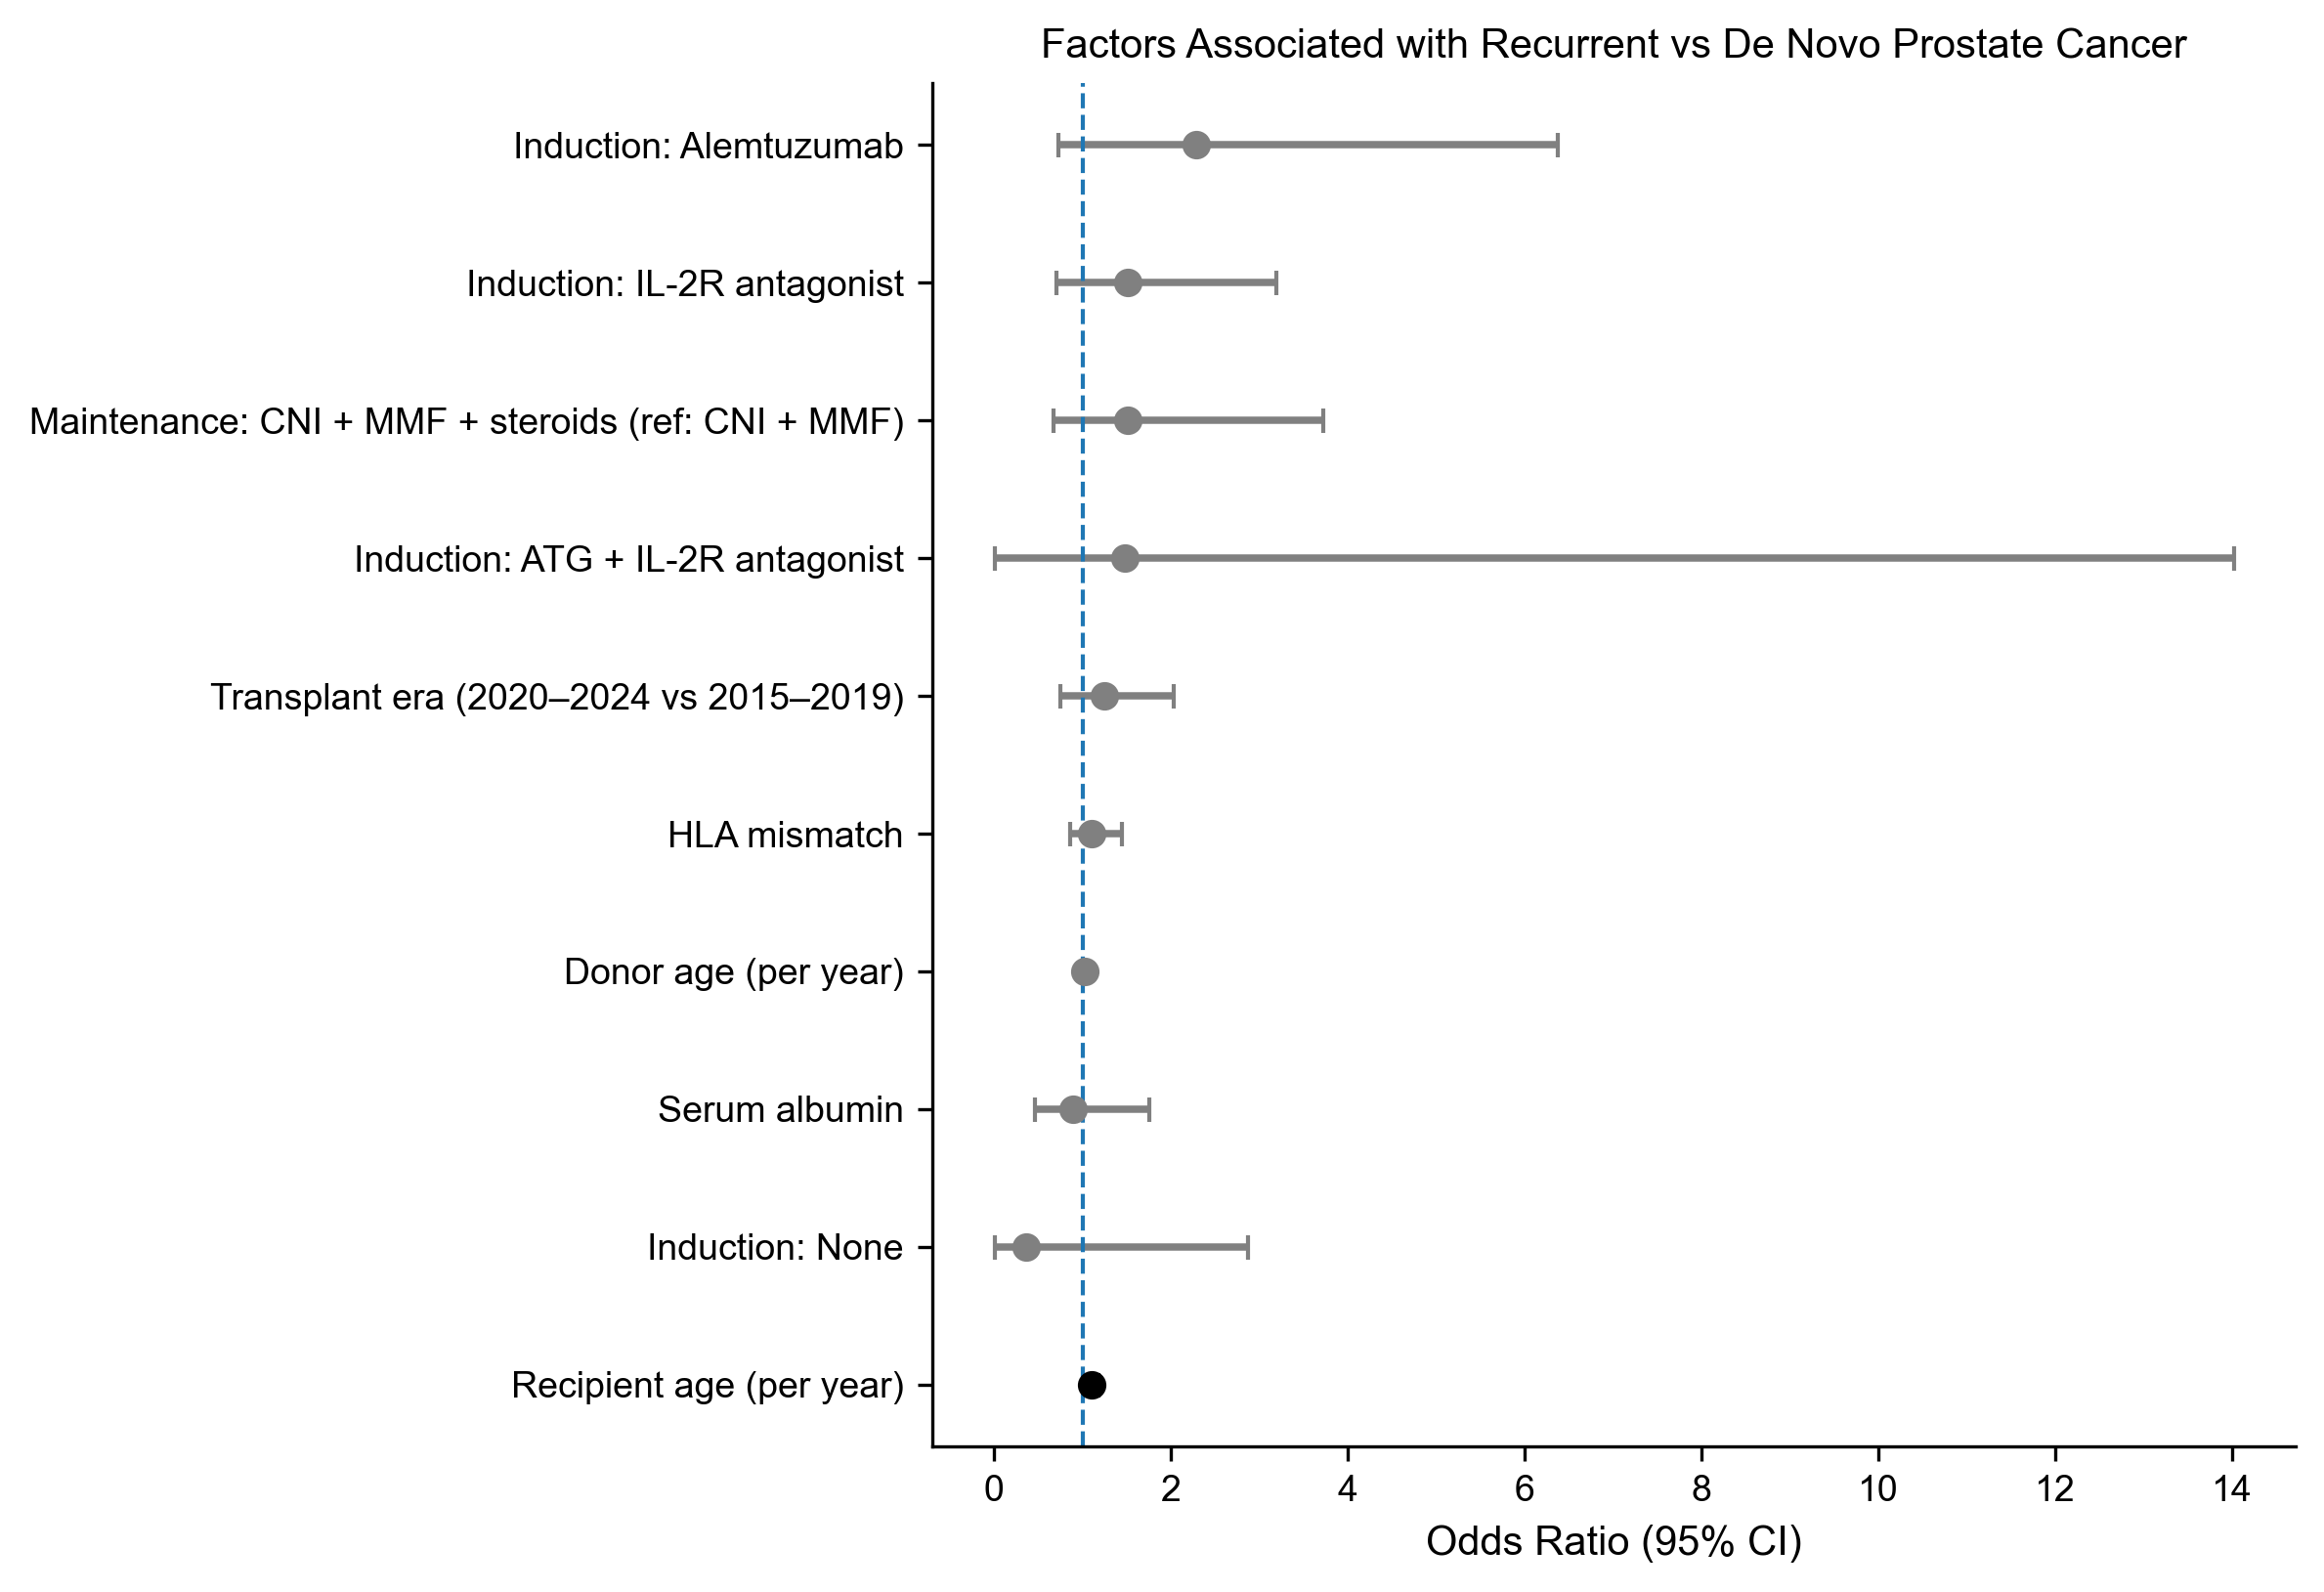

In [118]:
# =========================================================
# FOREST PLOT (FINAL)
# =========================================================

import matplotlib.pyplot as plt

plot_df = firth_plot_df.copy()

# Sort: significant first
plot_df['sig'] = plot_df['p_value'] < 0.05
plot_df = plot_df.sort_values(['sig', 'OR'], ascending=[False, True])

fig, ax = plt.subplots(figsize=(8, 5.5))

y_pos = range(len(plot_df))

for i, (_, row) in enumerate(plot_df.iterrows()):
    color = 'black' if row['p_value'] < 0.05 else 'gray'

    ax.errorbar(
        row['OR'], i,
        xerr=[[row['OR'] - row['CI_lower']],
              [row['CI_upper'] - row['OR']]],
        fmt='o',
        color=color,
        ecolor=color,
        capsize=3
    )

# Reference line
ax.axvline(1, linestyle='--', linewidth=1)

# Labels
ax.set_yticks(list(y_pos))
ax.set_yticklabels(plot_df['label'])
ax.set_xlabel('Odds Ratio (95% CI)')
ax.set_title('Factors Associated with Recurrent vs De Novo Prostate Cancer')

# Clean look
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig('figure2_forest_plot.png', dpi=300)
plt.show()

**Figure 2. Firth-penalized logistic regression estimates for recurrent versus de novo prostate cancer phenotype.**

Points represent adjusted odds ratios and horizontal lines represent 95% confidence intervals. Estimates greater than 1 indicate higher odds of recurrent phenotype.

Saved PLOS-ready figure: plos_one_figures\Fig2.tif


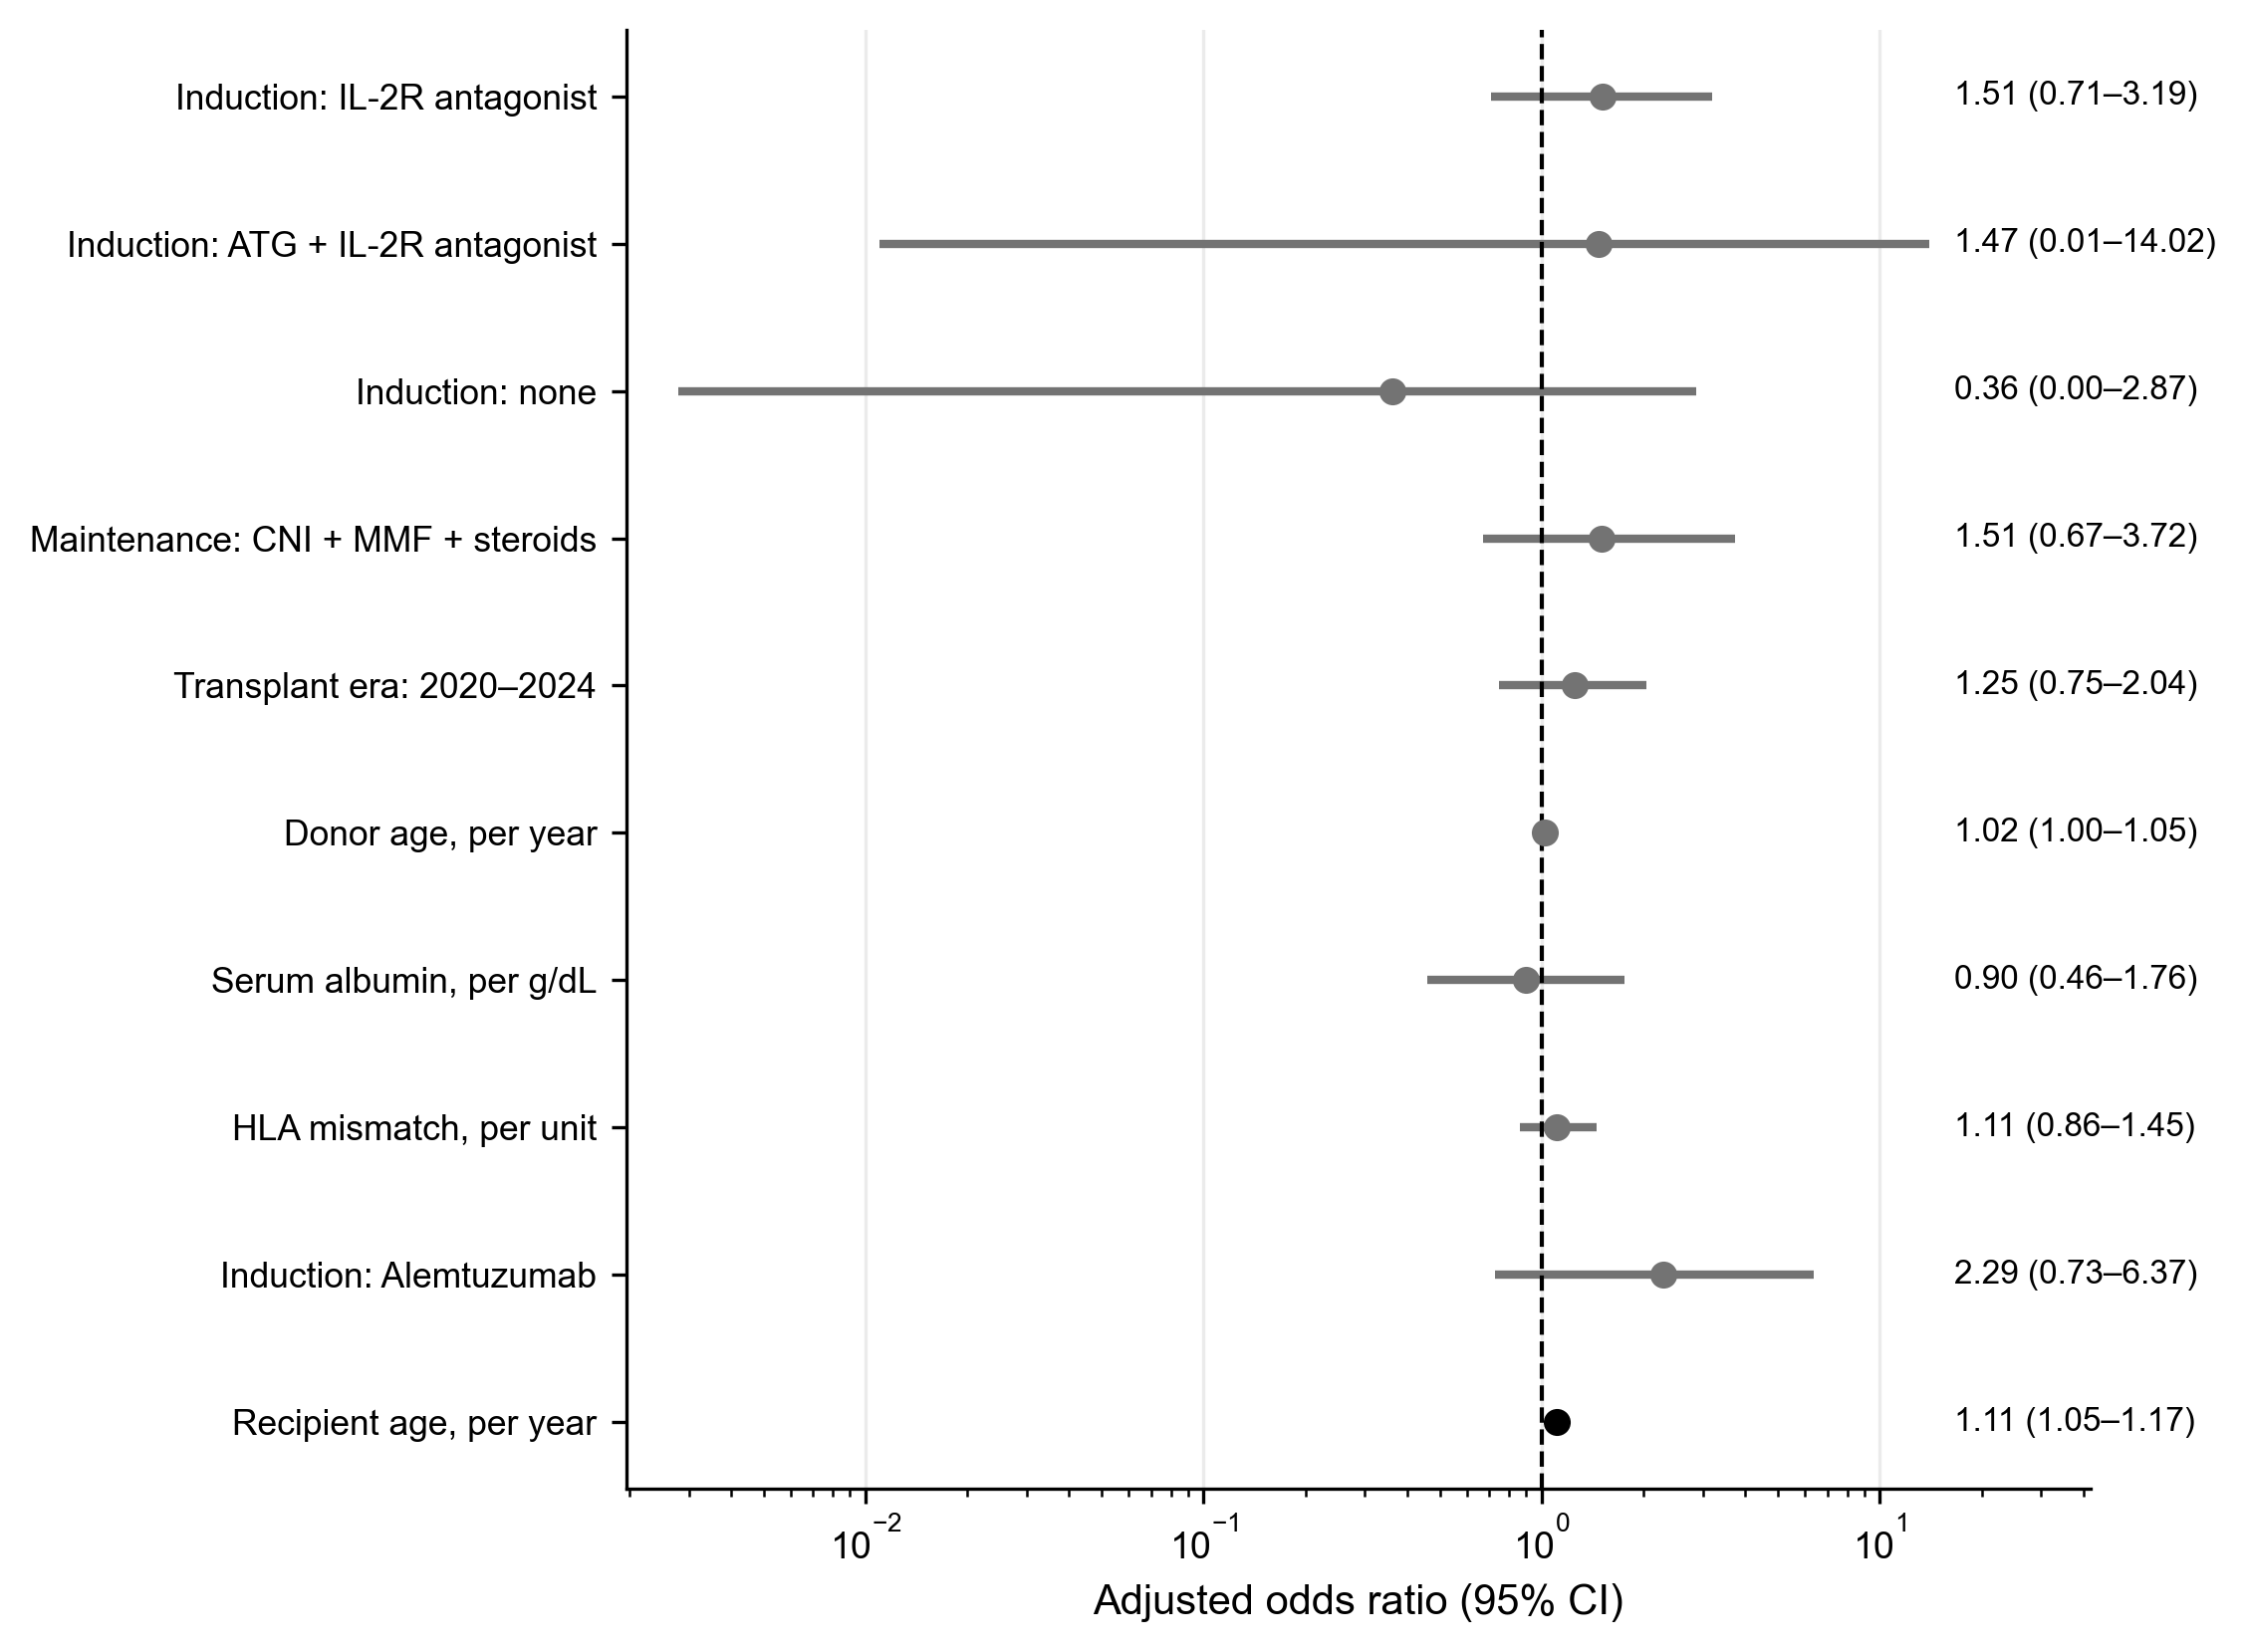

In [119]:
# =========================================================
# FIGURE 2: HYBRID FOREST PLOT — PRIMARY FIRTH MODEL
# PLOS-ready export: Fig2.tif
# =========================================================

# -----------------------------
# Prepare results
# -----------------------------
plot_df = firth_primary_results.copy()

# Standardize names if needed
plot_df = plot_df.rename(columns={
    'OR_low': 'CI_lower',
    'OR_high': 'CI_upper',
    'p.value': 'p_value'
})

# Remove intercept
plot_df = plot_df[plot_df['term'] != '(Intercept)'].copy()

# Clean labels
term_labels = {
    'AGE': 'Recipient age, per year',
    'AGE_DON': 'Donor age, per year',
    'HLAMIS': 'HLA mismatch, per unit',
    'TOT_SERUM_ALBUM': 'Serum albumin, per g/dL',
    'induction_regimenIL-2R antagonist': 'Induction: IL-2R antagonist',
    'induction_regimenAlemtuzumab': 'Induction: Alemtuzumab',
    'induction_regimenATG + IL-2R antagonist': 'Induction: ATG + IL-2R antagonist',
    'induction_regimenNone': 'Induction: none',
    'maintenance_regimenCNI + MMF + steroids': 'Maintenance: CNI + MMF + steroids',
    'tx_era.L': 'Transplant era: 2020–2024'
}

plot_df['label'] = plot_df['term'].map(term_labels).fillna(plot_df['term'])

# Clinical order, top to bottom
clinical_order = [
    'Recipient age',
    'Induction: IL-2R antagonist',
    'Induction: alemtuzumab',
    'Induction: ATG + IL-2R antagonist',
    'Induction: none',
    'Maintenance: CNI + MMF + steroids',
    'HLA mismatch',
    'Serum albumin',
    'Donor age',
    'Transplant era: 2020–2024'
]

plot_df['order'] = plot_df['label'].apply(
    lambda x: clinical_order.index(x) if x in clinical_order else 999
)

# Reverse so first item appears at top
plot_df = plot_df.sort_values('order', ascending=False).reset_index(drop=True)

# OR label text
plot_df['OR_CI_label'] = plot_df.apply(
    lambda r: f"{r['OR']:.2f} ({r['CI_lower']:.2f}–{r['CI_upper']:.2f})",
    axis=1
)

# -----------------------------
# Plot
# -----------------------------
fig, ax = plt.subplots(figsize=(7.5, 5.6))

y_pos = np.arange(len(plot_df))

for i, row in plot_df.iterrows():
    color = 'black' if row['p_value'] < 0.05 else '0.45'
    marker = 's' if row['p_value'] < 0.05 else 'o'
    
    ax.errorbar(
        row['OR'],
        i,
        xerr=[[row['OR'] - row['CI_lower']], [row['CI_upper'] - row['OR']]],
        fmt='o',
        color=color,
        ecolor=color,
        elinewidth=2,
        capsize=3,
        markersize=6.5,
        markeredgewidth=0
    )

# Reference line
ax.axvline(1, color='black', linestyle='--', linewidth=1)

# Log scale for ORs
ax.set_xscale('log')

# Labels
ax.set_yticks(y_pos)
ax.set_yticklabels(plot_df['label'], fontsize=8.5)
ax.set_xlabel('Adjusted odds ratio (95% CI)', fontsize=10)
#ax.set_title('Factors Associated with Recurrent vs De Novo Prostate Cancer',  fontsize=12,   pad=12)

# Right-side OR labels
xmax = plot_df['CI_upper'].max()
for i, row in plot_df.iterrows():
    ax.text(
        xmax * 1.18,
        i,
        row['OR_CI_label'],
        va='center',
        ha='left',
        fontsize=8
    )

# Axis limits
xmin = max(plot_df['CI_lower'].min() * 0.7, 0.001)
ax.set_xlim(xmin, xmax * 3.0)

# Clean style
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.grid(axis='x', alpha=0.25)

plt.tight_layout()
save_plos_figure(fig, 'Fig2.tif')
plt.show()


In [81]:
#### FIGURE 4: ROC + PR (2-panel figure)

Saved PLOS-ready figure: plos_one_figures\Fig4.tif


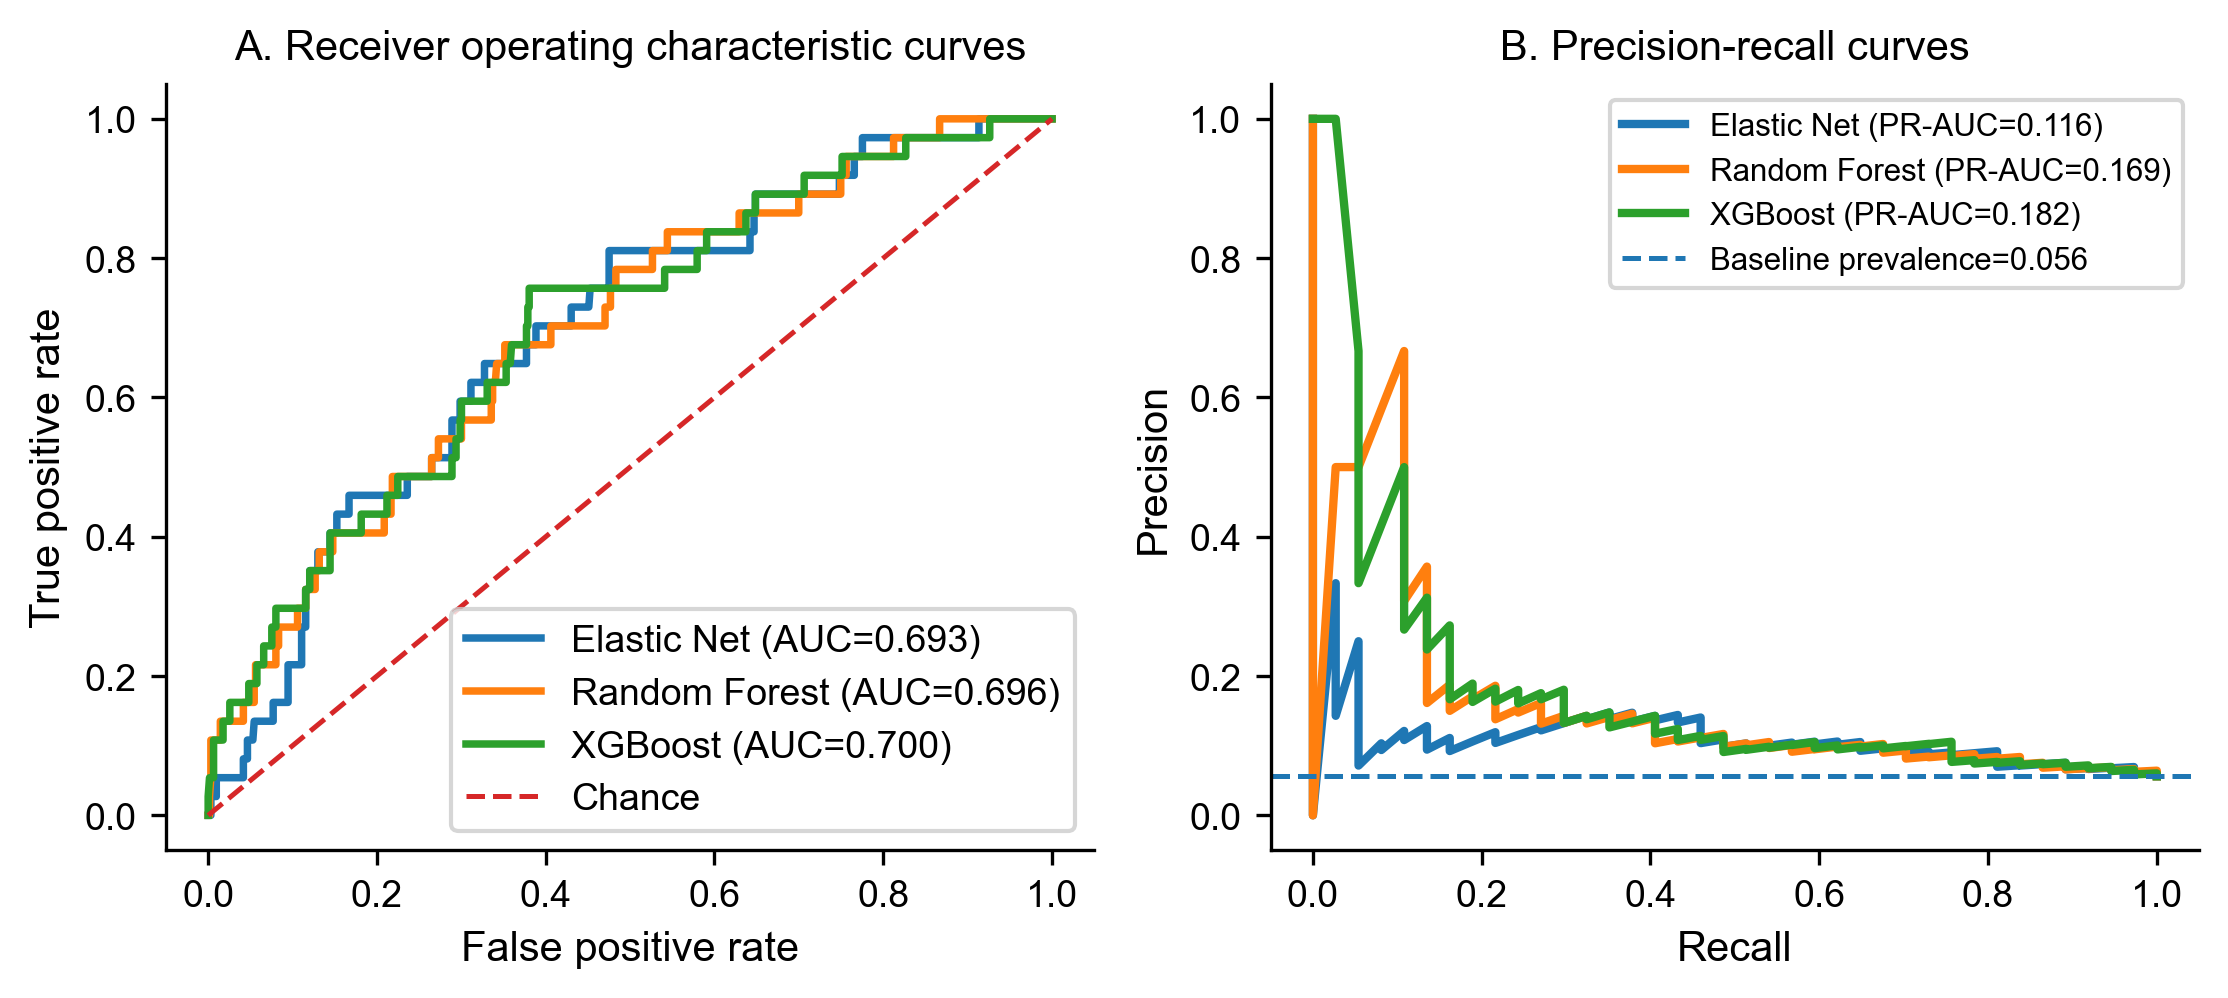

In [120]:
# =========================================================
# FIG 4: MACHINE LEARNING DISCRIMINATION PANEL
# Panel A: ROC curves; Panel B: precision-recall curves
# PLOS-ready export: Fig4.tif
# =========================================================

import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc, precision_recall_curve, average_precision_score

fig, axes = plt.subplots(1, 2, figsize=(7.5, 3.4))

# -----------------------------
# Panel A: ROC curves
# -----------------------------
ax = axes[0]

for model_name, result in ml_results.items():
    y_score = result['oof_pred_proba']
    fpr, tpr, _ = roc_curve(y, y_score)
    roc_auc = auc(fpr, tpr)
    ax.plot(fpr, tpr, linewidth=1.8, label=f"{model_name} (AUC={roc_auc:.3f})")

ax.plot([0, 1], [0, 1], linestyle='--', linewidth=1.2, label='Chance')
ax.set_xlabel("False positive rate")
ax.set_ylabel("True positive rate")
ax.set_title("A. Receiver operating characteristic curves")
ax.legend(loc="lower right", fontsize=9)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# -----------------------------
# Panel B: Precision-recall curves
# -----------------------------
ax = axes[1]

baseline_prev = y.mean()

for model_name, result in ml_results.items():
    y_score = result['oof_pred_proba']
    precision, recall, _ = precision_recall_curve(y, y_score)
    pr_auc = average_precision_score(y, y_score)
    ax.plot(recall, precision, linewidth=2, label=f"{model_name} (PR-AUC={pr_auc:.3f})")

ax.axhline(
    baseline_prev,
    linestyle='--',
    linewidth=1.2,
    label=f"Baseline prevalence={baseline_prev:.3f}"
)

ax.set_xlabel("Recall")
ax.set_ylabel("Precision")
ax.set_title("B. Precision-recall curves")
ax.legend(loc="upper right", fontsize=7.5, frameon=True)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
save_plos_figure(fig, 'Fig4.tif')
plt.show()


##### SUPPLEMENTARY FIGURE S2: Calibration (3-panel)

Saved PLOS-ready figure: plos_one_figures\S2_Fig.tif


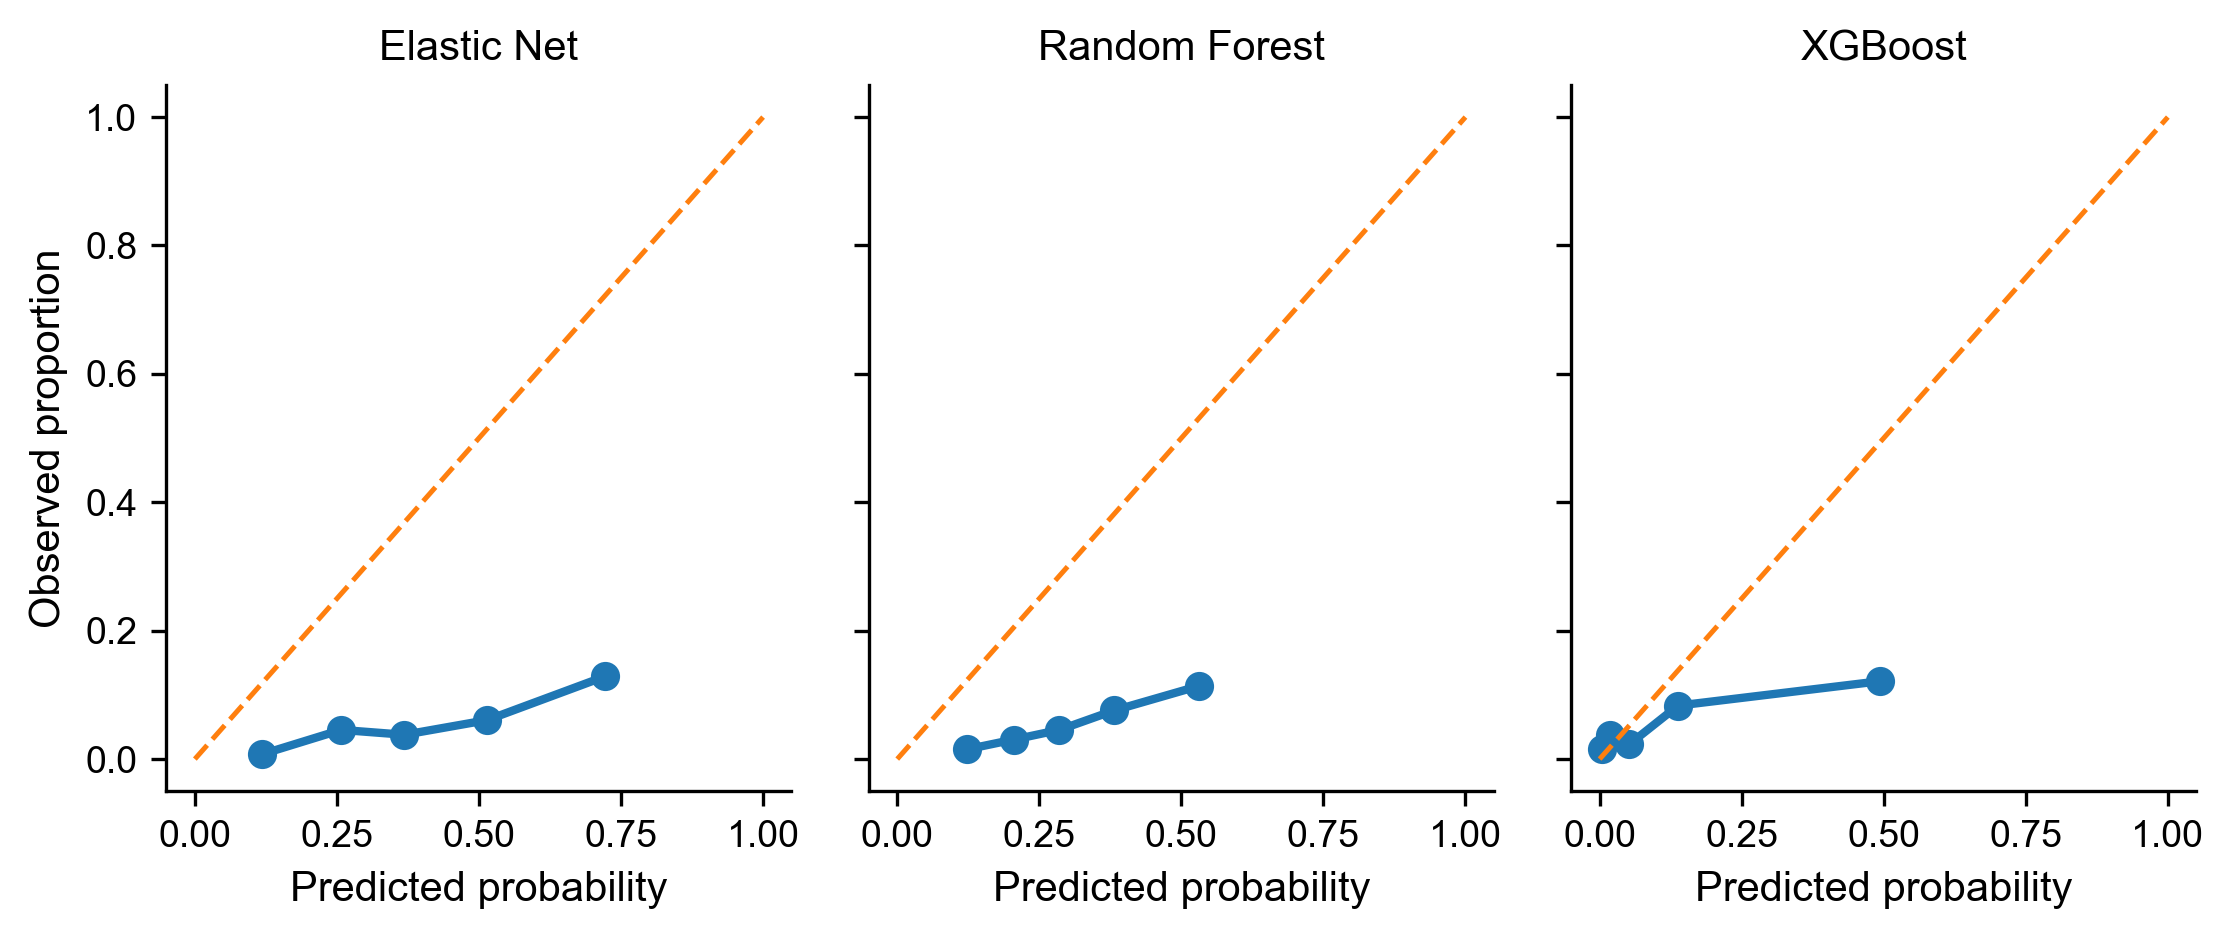

In [121]:
# =========================================================
# S2 FIG: MACHINE LEARNING CALIBRATION PANEL
# Panel A: Elastic Net; Panel B: Random Forest; Panel C: XGBoost
# PLOS-ready export: S2_Fig.tif
# =========================================================

import matplotlib.pyplot as plt
from sklearn.calibration import calibration_curve

model_order = ["Elastic Net", "Random Forest", "XGBoost"]

fig, axes = plt.subplots(1, 3, figsize=(7.5, 3.2), sharex=True, sharey=True)

for ax, model_name in zip(axes, model_order):
    if model_name not in ml_results:
        ax.axis("off")
        continue

    y_score = ml_results[model_name]['oof_pred_proba']

    prob_true, prob_pred = calibration_curve(
        y,
        y_score,
        n_bins=5,
        strategy="quantile"
    )

    ax.plot(prob_pred, prob_true, marker='o', linewidth=2)
    ax.plot([0, 1], [0, 1], linestyle='--', linewidth=1.2)

    ax.set_title(model_name)
    ax.set_xlabel("Predicted probability")
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

axes[0].set_ylabel("Observed proportion")

#fig.suptitle("Supplementary Figure S2. Calibration plots for machine learning models", y=1.05)
plt.tight_layout(w_pad=1.6)
save_plos_figure(fig, 'S2_Fig.tif')
plt.show()
